In [1]:
# read in data
# group samples wt, mutants(one A), mutant (all A),plot all the scores to have an overview, to inspect them, choose the ones where the distribution differs from baseline(wt)
# filter out placeholder values (if all line has the same score for a metric exclude it)
# inspect results
# inspect bast 10 or set threshold
# scatterplot / violin plot for the ones passing 
# find most relevant metrics

# binary ROC/AUCprecision recall curve, F1 score, 

# later: 
# confusion matrix, ROC curve, AUC, accuracy, sensitivity, specificity, MCC, Cohen's Kappa, etc. ??
# try to assess the same scores for different models and compare them if they behaving similarly, 
# inspect most relevant metrics by grouping them, meaning inspact the same metric from different models and compare them

# How to curate a dataset that effectively represents both binders and non-binders?
# How to handle imbalanced data?
# distribution? correlation? separation?
# is it worked or decoys have a similar score then binders? 
# which scores are informative? which one are important?
# are the ones where all the interface residues were mutated to alanine have ok scores? why?

### read in data

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yaml
import ast
from pathlib import Path
from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, f1_score, precision_recall_curve, confusion_matrix

# Configuration

MASTER_PATH = "/home/bri/pymol/data/mcmahon/table/master_table_mcmahon.csv"
YAML_PATH = "/home/bri/pymol/EDA/static/metric_directions.yaml"
CSV_PATH = "/home/bri/pymol/data/predictions/predictions_adiponectin_trimer.csv" 
OUTPUT_DIR = Path("/home/bri/pymol/EDA/static/adipo_trimer_outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

KEEP_INTERFACES = {"A,B"}
palette = {"binder": "#2196F3", "ala_scan": "#FF5722"}


# Load data
preds_df = pd.read_csv(CSV_PATH)

preds_df.head()
preds_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 71 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   sample                                  30 non-null     str    
 1   binding                                 30 non-null     bool   
 2   interface                               30 non-null     str    
 3   af3_pae                                 30 non-null     float64
 4   af3_plddt                               30 non-null     float64
 5   af3_interface_dG                        30 non-null     float64
 6   af3_interface_dG_SASA_ratio             30 non-null     float64
 7   af3_ipae                                21 non-null     float64
 8   af3_iplddt                              21 non-null     float64
 9   af3_ipsae                               30 non-null     float64
 10  af3_iptm                                30 non-null     float64
 11  af3_pt

## Filter and merge interfaces

In [14]:
df_interface = preds_df[preds_df["interface"].str.strip().isin(KEEP_INTERFACES)].copy()
print(f"Loaded {len(df_interface)} rows. Interfaces: {df_interface['interface'].unique()}")
df_interface

Loaded 5 rows. Interfaces: <StringArray>
['A,B']
Length: 1, dtype: str


,sample,binding,interface,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,af3_iplddt,af3_ipsae,...,boltz_template_confidence_score,boltz_template_ptm,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,boltz_template_model_path,binder
0,Nb.AQ103_Adiponectin,False,"A,B",17.692362,68.936035,319.95,22.09,10.025000,63.130425,0.000000,...,0.812113,0.732410,0.663634,0.849232,0.816428,1.056495,4.694545,0.403915,/scicore/home/schwede/barta0000/mcmahon_ds/adi...,1
6,Nb.AQ102_Adiponectin,False,"A,B",12.571009,80.375406,79.77,11.17,12.433333,62.883635,0.034262,...,0.838724,0.843795,0.812179,0.845360,0.800754,0.963051,3.428939,0.702256,/scicore/home/schwede/barta0000/mcmahon_ds/adi...,0
12,Nb.AQ101_Adiponectin,False,"A,B",17.822338,69.199174,0.00,0.00,NaN,NaN,0.000000,...,0.902838,0.907693,0.885929,0.907066,0.876474,0.520526,1.512989,0.790176,/scicore/home/schwede/barta0000/mcmahon_ds/adi...,0
18,Nb.AQ104_Adiponectin,False,"A,B",17.695982,69.728085,393.26,29.92,8.021429,63.100327,0.000000,...,0.888369,0.866459,0.839310,0.900634,0.869619,0.835575,2.833774,0.757965,/scicore/home/schwede/barta0000/mcmahon_ds/adi...,0
24,Nb.AQ100_Adiponectin,False,"A,B",17.063186,70.397572,0.00,0.00,NaN,NaN,0.000000,...,0.803697,0.812093,0.770713,0.811943,0.775972,0.906293,3.453864,0.582114,/scicore/home/schwede/barta0000/mcmahon_ds/adi...,1


In [15]:
print(f"Dataset shape: {df_interface.shape}")
print(f"Binding distribution:\n{df_interface['binder'].value_counts()}")
print(df_interface.isna().sum().sort_values(ascending=False).to_string())

Dataset shape: (5, 71)
Binding distribution:
binder
0    3
1    2
Name: count, dtype: int64
esmfold_ipae                              5
cf_interface_dG_SASA_ratio                5
esmfold_iplddt                            5
cf_pyros_binder_score                     5
cf_interface_dG                           5
cf_rank0_masif                            4
cf_ipae                                   3
cf_iplddt                                 3
af3_rank0_masif                           3
af3_iplddt                                2
af3_ipae                                  2
interface                                 0
binding                                   0
sample                                    0
af3_pae                                   0
af3_interface_dG_SASA_ratio               0
af3_interface_dG                          0
af3_plddt                                 0
af3_ptm                                   0
af3_ranking_score                         0
af3_rank                    

In [16]:
df_interface.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 24
Data columns (total 71 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   sample                                  5 non-null      str    
 1   binding                                 5 non-null      bool   
 2   interface                               5 non-null      str    
 3   af3_pae                                 5 non-null      float64
 4   af3_plddt                               5 non-null      float64
 5   af3_interface_dG                        5 non-null      float64
 6   af3_interface_dG_SASA_ratio             5 non-null      float64
 7   af3_ipae                                3 non-null      float64
 8   af3_iplddt                              3 non-null      float64
 9   af3_ipsae                               5 non-null      float64
 10  af3_iptm                                5 non-null      float64
 11  af3_ptm

In [19]:
print(df_interface.columns.tolist())

['sample', 'binding', 'interface', 'af3_pae', 'af3_plddt', 'af3_interface_dG', 'af3_interface_dG_SASA_ratio', 'af3_ipae', 'af3_iplddt', 'af3_ipsae', 'af3_iptm', 'af3_ptm', 'af3_pyros_binder_score', 'af3_rank', 'af3_ranking_score', 'af3_rank0_masif', 'cf_af3_rmsd', 'cf_pae', 'cf_plddt', 'cf_interface_dG', 'cf_interface_dG_SASA_ratio', 'cf_ipae', 'cf_iplddt', 'cf_ipsae', 'cf_iptm', 'cf_ptm', 'cf_pyros_binder_score', 'cf_rank', 'cf_rank0_masif', 'pred_ilddt', 'pred_lddt', 'esmfold_ipae', 'esmfold_iplddt', 'esmfold_plddt', 'esmfold_pae', 'esmfold_ptm', 'chai_unconstrained_score', 'chai_unconstrained_model_path', 'chai_constrained_score', 'chai_constrained_model_path', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_ptm', 'chai_unconstrained_iptm', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_unconstrained_interface_iptm', 'chai_constrained_aggregate_score', 'chai_constrained_ptm', 'chai_constrained_iptm', 'chai_constrained_per_chain_ptm', 'c

In [20]:
cols_to_drop=(['binding', 'interface', 'af3_rank', 'af3_ranking_score', 'af3_rank0_masif', 'cf_rank', 'cf_rank0_masif', 'chai_unconstrained_model_path', 'chai_constrained_model_path', 'boltz_free_model_path', 'boltz_template_model_path'])

scores_df = df_interface.drop(columns=cols_to_drop)

# vllt drop 'KD[M]', 'EC50[M]' too?
scores_df.head()


,sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,af3_iplddt,af3_ipsae,af3_iptm,af3_ptm,...,boltz_free_per_chain_pair_iptm,boltz_template_confidence_score,boltz_template_ptm,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,binder
0,Nb.AQ103_Adiponectin,17.692362,68.936035,319.95,22.09,10.025000,63.130425,0.000000,0.10,0.775,...,0.177982,0.812113,0.732410,0.663634,0.849232,0.816428,1.056495,4.694545,0.403915,1
6,Nb.AQ102_Adiponectin,12.571009,80.375406,79.77,11.17,12.433333,62.883635,0.034262,0.35,0.835,...,0.138774,0.838724,0.843795,0.812179,0.845360,0.800754,0.963051,3.428939,0.702256,0
12,Nb.AQ101_Adiponectin,17.822338,69.199174,0.00,0.00,NaN,NaN,0.000000,0.08,0.755,...,0.783432,0.902838,0.907693,0.885929,0.907066,0.876474,0.520526,1.512989,0.790176,0
18,Nb.AQ104_Adiponectin,17.695982,69.728085,393.26,29.92,8.021429,63.100327,0.000000,0.09,0.760,...,0.422858,0.888369,0.866459,0.839310,0.900634,0.869619,0.835575,2.833774,0.757965,0
24,Nb.AQ100_Adiponectin,17.063186,70.397572,0.00,0.00,NaN,NaN,0.000000,0.10,0.790,...,0.333823,0.803697,0.812093,0.770713,0.811943,0.775972,0.906293,3.453864,0.582114,1


In [21]:
scores_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 24
Data columns (total 60 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   sample                                  5 non-null      str    
 1   af3_pae                                 5 non-null      float64
 2   af3_plddt                               5 non-null      float64
 3   af3_interface_dG                        5 non-null      float64
 4   af3_interface_dG_SASA_ratio             5 non-null      float64
 5   af3_ipae                                3 non-null      float64
 6   af3_iplddt                              3 non-null      float64
 7   af3_ipsae                               5 non-null      float64
 8   af3_iptm                                5 non-null      float64
 9   af3_ptm                                 5 non-null      float64
 10  af3_pyros_binder_score                  5 non-null      float64
 11  cf_af3_

### prep chai array-like

In [22]:
chai_df = scores_df[['sample', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']]
chai_df.to_csv(OUTPUT_DIR / 'chai_matrices.csv', index=False)

In [23]:
chai_df.head()

,sample,chai_unconstrained_per_chain_ptm,chai_unconstrained_per_chain_pair_iptm,chai_constrained_per_chain_ptm,chai_constrained_per_chain_pair_iptm
0,Nb.AQ103_Adiponectin,"[[0.9031566977500916, 0.9316254258155823, 0.93...","[[[0.9031566977500916, 0.13743747770786285, 0....","[[0.9149221777915955, 0.8821884393692017]]","[[[0.9149221777915955, 0.3864653408527374], [0..."
6,Nb.AQ102_Adiponectin,"[[0.9035168886184692, 0.9336140155792236, 0.93...","[[[0.9035168886184692, 0.2006823718547821, 0.1...","[[0.9041144251823425, 0.8915349245071411]]","[[[0.9041144251823425, 0.37381139397621155], [..."
12,Nb.AQ101_Adiponectin,"[[0.8991042971611023, 0.9321891069412231, 0.93...","[[[0.8991042971611023, 0.15419834852218628, 0....","[[0.8951106071472168, 0.8975489735603333]]","[[[0.8951106071472168, 0.4260290861129761], [0..."
18,Nb.AQ104_Adiponectin,"[[0.8627405762672424, 0.9281590580940247, 0.92...","[[[0.8627405762672424, 0.1284686177968979, 0.1...","[[0.8603140115737915, 0.9012055397033691]]","[[[0.8603140115737915, 0.23665881156921387], [..."
24,Nb.AQ100_Adiponectin,"[[0.8755684494972229, 0.9303023815155029, 0.93...","[[[0.8755684494972229, 0.16425757110118866, 0....","[[0.8896564841270447, 0.8871409893035889]]","[[[0.8896564841270447, 0.35717955231666565], [..."


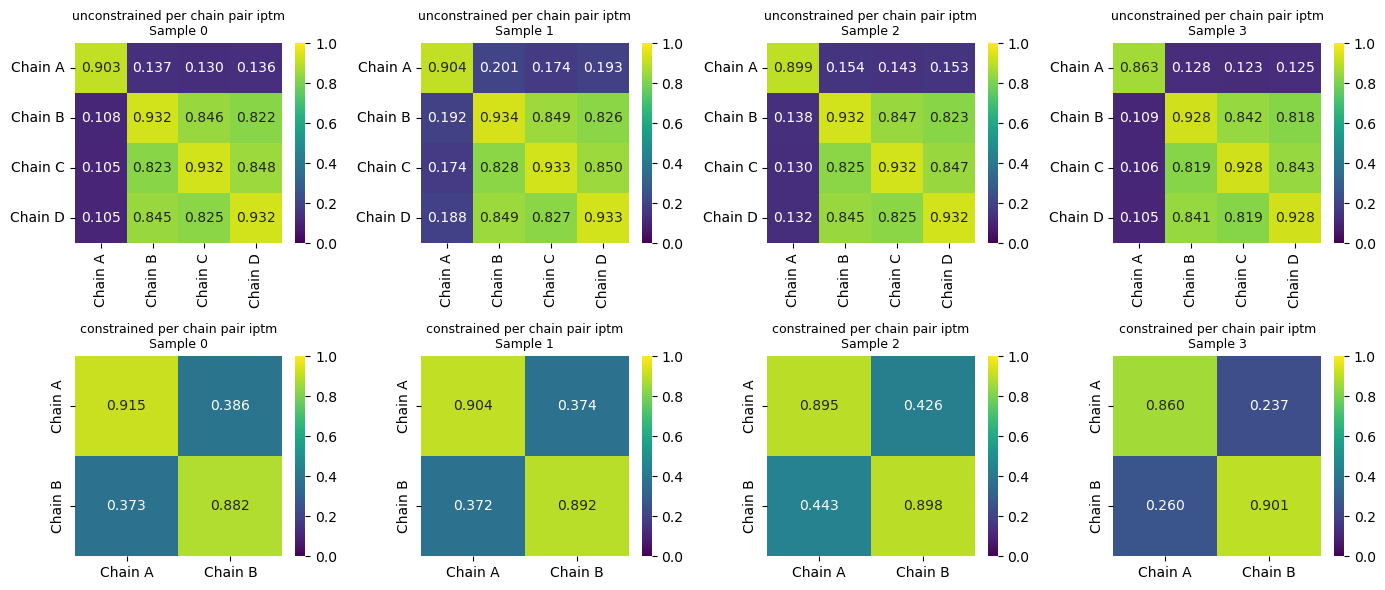

In [24]:
# Parse matrix strings from all 4 chai columns
import ast
import numpy as np

def parse_matrix(x):
    if pd.isna(x):
        return None
    try:
        arr = np.array(ast.literal_eval(x))
        return arr.squeeze()  # remove extra dimensions
    except:
        return None

# Apply parse_matrix to all 4 columns
ptm_cols = ['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm']

for col in ptm_cols:
    chai_df[f"{col}_matrix"] = chai_df[col].apply(parse_matrix)

# Create heatmaps for first 4 samples (focusing on pair_iptm columns)
pair_cols = ['chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_pair_iptm']

fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for row_idx, col in enumerate(pair_cols):
    for sample_idx in range(4):
        ax = axes[row_idx, sample_idx]
        matrix = chai_df[f"{col}_matrix"].iloc[sample_idx]
        
        if matrix is not None and isinstance(matrix, np.ndarray) and matrix.ndim == 2:
            n = matrix.shape[0]  # works for 2x2, 3x3, etc.
            labels = [f'Chain {chr(65+i)}' for i in range(n)]  # A, B, C, ...
            
            sns.heatmap(
                matrix,
                ax=ax,
                cmap='viridis',
                cbar=True,
                xticklabels=labels,
                yticklabels=labels,
                vmin=0,
                vmax=1,
                annot=True,
                fmt='.3f'
            )
            
            ax.set_title(
                f'{col.replace("chai_", "").replace("_", " ")}\nSample {sample_idx}',
                fontsize=9
            )
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center')
            ax.set_xticks([])
            ax.set_yticks([])


plt.tight_layout()
plt.savefig(OUTPUT_DIR /'chai_matrices_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()



In [27]:
def extract_matrix_mean(matrix):
    if matrix is None or not isinstance(matrix, np.ndarray) or matrix.ndim != 2:
        return np.nan

    n = matrix.shape[0]

    # constrained: only one interface (A-C or B-C)
    if n == 2:
        return np.mean([matrix[0, 1], matrix[1, 0]])

    # unconstrained: average C interactions with A and B
    elif n == 4:
        ab = np.mean([matrix[0, 1], matrix[1, 0]])
        return np.mean([ab])

    return np.nan

chai_df['chai_unconstrained_per_chain_iptm'] = \
    chai_df['chai_unconstrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_mean)

chai_df['chai_constrained_per_chain_iptm'] = \
    chai_df['chai_constrained_per_chain_pair_iptm_matrix'].apply(extract_matrix_mean)


# Display summary
print("Unconstrained A-B interface mean (top 10):")
print(chai_df['chai_unconstrained_per_chain_iptm'].head(10).to_string())
print("\nConstrained A-B interface mean (top 10):")
print(chai_df['chai_constrained_per_chain_iptm'].head(10).to_string())

Unconstrained A-B interface mean (top 10):
0     0.122835
6     0.196391
12    0.146017
18    0.118599
24    0.149564

Constrained A-B interface mean (top 10):
0     0.379824
6     0.372869
12    0.434513
18    0.248145
24    0.342955


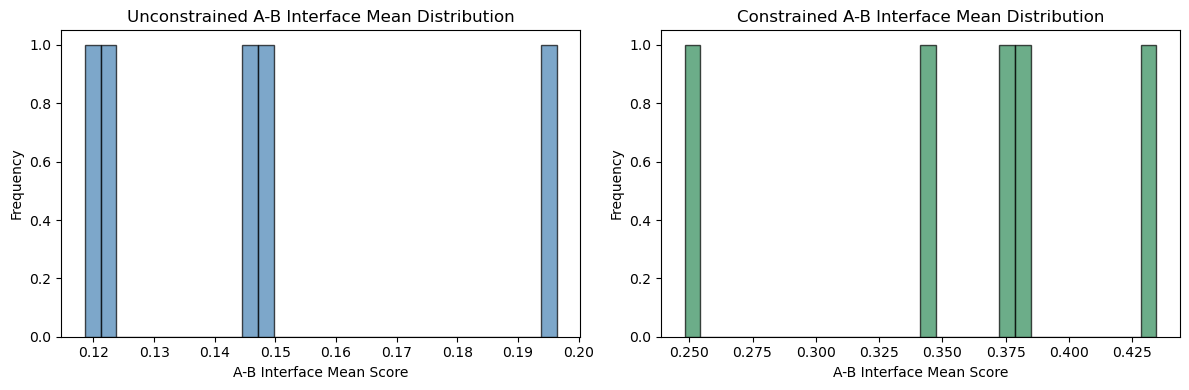

In [28]:
# Visualize the distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(chai_df['chai_unconstrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_xlabel('A-B Interface Mean Score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Unconstrained A-B Interface Mean Distribution')
axes[0].grid(False)

axes[1].hist(chai_df['chai_constrained_per_chain_iptm'].dropna(), bins=30, alpha=0.7, color='seagreen', edgecolor='black')
axes[1].set_xlabel('A-B Interface Mean Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Constrained A-B Interface Mean Distribution')
axes[1].grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'chai_ab_interface_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [29]:
# Extract mean pTM
def extract_ptm_mean(arr):
    """Extract mean of pTM array (average across both chains)"""
    if arr is None or not isinstance(arr, np.ndarray) or arr.ndim != 1:
        return np.nan
    return np.mean(arr)

# Extract mean for unconstrained pTM
chai_df['chai_unconstrained_per_chain_ptm'] = \
    chai_df['chai_unconstrained_per_chain_ptm_matrix'].apply(extract_ptm_mean)

# Extract mean for constrained pTM
chai_df['chai_constrained_per_chain_ptm'] = \
    chai_df['chai_constrained_per_chain_ptm_matrix'].apply(extract_ptm_mean)

# Display summary
print("pTM Mean Scores:")
print("\nUnconstrained pTM mean (top 10):")
print(chai_df['chai_unconstrained_per_chain_ptm'].head(10).to_string())
print("\nConstrained pTM mean (top 10):")
print(chai_df['chai_constrained_per_chain_ptm'].head(10).to_string())
print(f"\nUnconstrained pTM mean - desc stats:\n{chai_df['chai_unconstrained_per_chain_ptm'].describe()}")
print(f"\nConstrained pTM mean - desc stats:\n{chai_df['chai_constrained_per_chain_ptm'].describe()}")

pTM Mean Scores:

Unconstrained pTM mean (top 10):
0     0.924669
6     0.925709
12    0.923906
18    0.911731
24    0.916624

Constrained pTM mean (top 10):
0     0.898555
6     0.897825
12    0.896330
18    0.880760
24    0.888399

Unconstrained pTM mean - desc stats:
count    5.000000
mean     0.920528
std      0.006084
min      0.911731
25%      0.916624
50%      0.923906
75%      0.924669
max      0.925709
Name: chai_unconstrained_per_chain_ptm, dtype: float64

Constrained pTM mean - desc stats:
count    5.000000
mean     0.892374
std      0.007653
min      0.880760
25%      0.888399
50%      0.896330
75%      0.897825
max      0.898555
Name: chai_constrained_per_chain_ptm, dtype: float64


In [30]:
# ===== Create df_chai_numeric with extracted mean scores =====
df_chai_numeric = chai_df[['sample',
                            'chai_unconstrained_per_chain_ptm',
                            'chai_constrained_per_chain_ptm',
                            'chai_unconstrained_per_chain_iptm',
                            'chai_constrained_per_chain_iptm']].copy()

print("df_chai_numeric shape:", df_chai_numeric.shape)
print("\ndf_chai_numeric head:")
print(df_chai_numeric.head(10).to_string())
print("\ndf_chai_numeric info:")
print(df_chai_numeric.info())

# Save to CSV
df_chai_numeric.to_csv(OUTPUT_DIR / 'chai_numeric_metrics.csv', index=False)
print("\n✓ Saved to: chai_numeric_metrics.csv")

df_chai_numeric shape: (5, 5)

df_chai_numeric head:
                  sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0   Nb.AQ103_Adiponectin                          0.924669                        0.898555                           0.122835                         0.379824
6   Nb.AQ102_Adiponectin                          0.925709                        0.897825                           0.196391                         0.372869
12  Nb.AQ101_Adiponectin                          0.923906                        0.896330                           0.146017                         0.434513
18  Nb.AQ104_Adiponectin                          0.911731                        0.880760                           0.118599                         0.248145
24  Nb.AQ100_Adiponectin                          0.916624                        0.888399                           0.149564                         0.

In [31]:
scores_df.drop(columns=['chai_unconstrained_per_chain_ptm', 'chai_unconstrained_per_chain_pair_iptm', 'chai_constrained_per_chain_ptm', 'chai_constrained_per_chain_pair_iptm'], inplace = True)
scores_df.head()

,sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,af3_iplddt,af3_ipsae,af3_iptm,af3_ptm,...,boltz_free_per_chain_pair_iptm,boltz_template_confidence_score,boltz_template_ptm,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,binder
0,Nb.AQ103_Adiponectin,17.692362,68.936035,319.95,22.09,10.025000,63.130425,0.000000,0.10,0.775,...,0.177982,0.812113,0.732410,0.663634,0.849232,0.816428,1.056495,4.694545,0.403915,1
6,Nb.AQ102_Adiponectin,12.571009,80.375406,79.77,11.17,12.433333,62.883635,0.034262,0.35,0.835,...,0.138774,0.838724,0.843795,0.812179,0.845360,0.800754,0.963051,3.428939,0.702256,0
12,Nb.AQ101_Adiponectin,17.822338,69.199174,0.00,0.00,NaN,NaN,0.000000,0.08,0.755,...,0.783432,0.902838,0.907693,0.885929,0.907066,0.876474,0.520526,1.512989,0.790176,0
18,Nb.AQ104_Adiponectin,17.695982,69.728085,393.26,29.92,8.021429,63.100327,0.000000,0.09,0.760,...,0.422858,0.888369,0.866459,0.839310,0.900634,0.869619,0.835575,2.833774,0.757965,0
24,Nb.AQ100_Adiponectin,17.063186,70.397572,0.00,0.00,NaN,NaN,0.000000,0.10,0.790,...,0.333823,0.803697,0.812093,0.770713,0.811943,0.775972,0.906293,3.453864,0.582114,1


In [32]:
# Join scores_df with df_chai_numeric on "sample"
scores_df_extended = scores_df.merge(df_chai_numeric, on='sample', how='left')

print("Joined DataFrame shape:", scores_df_extended.shape)
print("\nNew columns added from df_chai_numeric:")
new_cols = [col for col in scores_df_extended.columns if col in df_chai_numeric.columns and col != 'sample']
print(new_cols)
print("\nscores_df_extended head:")
print(scores_df_extended[['sample'] + new_cols].head(10).to_string())
print("\nJoin statistics:")
print(f"  - Total rows: {len(scores_df_extended)}")
print(f"  - Rows with all chai metrics: {scores_df_extended[new_cols].notna().all(axis=1).sum()}")
print(f"  - Rows with missing chai metrics: {scores_df_extended[new_cols].isna().any(axis=1).sum()}")

# Save extended dataframe
scores_df_extended.to_csv(OUTPUT_DIR / 'scores_df_extended_with_chai.csv', index=False)
print(f"\n✓ Saved to: {OUTPUT_DIR / 'scores_df_extended_with_chai.csv'}")

Joined DataFrame shape: (5, 60)

New columns added from df_chai_numeric:
['chai_unconstrained_per_chain_ptm', 'chai_constrained_per_chain_ptm', 'chai_unconstrained_per_chain_iptm', 'chai_constrained_per_chain_iptm']

scores_df_extended head:
                 sample  chai_unconstrained_per_chain_ptm  chai_constrained_per_chain_ptm  chai_unconstrained_per_chain_iptm  chai_constrained_per_chain_iptm
0  Nb.AQ103_Adiponectin                          0.924669                        0.898555                           0.122835                         0.379824
1  Nb.AQ102_Adiponectin                          0.925709                        0.897825                           0.196391                         0.372869
2  Nb.AQ101_Adiponectin                          0.923906                        0.896330                           0.146017                         0.434513
3  Nb.AQ104_Adiponectin                          0.911731                        0.880760                           0.118599  

In [33]:
scores_df_extended.head()

,sample,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,af3_iplddt,af3_ipsae,af3_iptm,af3_ptm,...,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,binder,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm
0,Nb.AQ103_Adiponectin,17.692362,68.936035,319.95,22.09,10.025000,63.130425,0.000000,0.10,0.775,...,0.849232,0.816428,1.056495,4.694545,0.403915,1,0.924669,0.898555,0.122835,0.379824
1,Nb.AQ102_Adiponectin,12.571009,80.375406,79.77,11.17,12.433333,62.883635,0.034262,0.35,0.835,...,0.845360,0.800754,0.963051,3.428939,0.702256,0,0.925709,0.897825,0.196391,0.372869
2,Nb.AQ101_Adiponectin,17.822338,69.199174,0.00,0.00,NaN,NaN,0.000000,0.08,0.755,...,0.907066,0.876474,0.520526,1.512989,0.790176,0,0.923906,0.896330,0.146017,0.434513
3,Nb.AQ104_Adiponectin,17.695982,69.728085,393.26,29.92,8.021429,63.100327,0.000000,0.09,0.760,...,0.900634,0.869619,0.835575,2.833774,0.757965,0,0.911731,0.880760,0.118599,0.248145
4,Nb.AQ100_Adiponectin,17.063186,70.397572,0.00,0.00,NaN,NaN,0.000000,0.10,0.790,...,0.811943,0.775972,0.906293,3.453864,0.582114,1,0.916624,0.888399,0.149564,0.342955


### Df prep

In [34]:
# Calculate for all numeric columns
numeric_cols = scores_df_extended.select_dtypes(include=['number']).columns.tolist()

exclude_cols = ['KD[M]', 'EC50[M]']  # example of columns to exclude if needed

# Remove excluded columns from numeric_cols
for col in exclude_cols:
    if col in numeric_cols:
        numeric_cols.remove(col)
    

# Remove 'binding' from the list if it is numeric (it's the target, not a feature)
if 'binder' in numeric_cols:
    numeric_cols.remove('binder')

numeric_cols
len(numeric_cols)

58

In [35]:
scores_df_extended[numeric_cols].head() 

,af3_pae,af3_plddt,af3_interface_dG,af3_interface_dG_SASA_ratio,af3_ipae,af3_iplddt,af3_ipsae,af3_iptm,af3_ptm,af3_pyros_binder_score,...,boltz_template_iptm,boltz_template_plddt,boltz_template_iplddt,boltz_template_pde,boltz_template_ipde,boltz_template_per_chain_pair_iptm,chai_unconstrained_per_chain_ptm,chai_constrained_per_chain_ptm,chai_unconstrained_per_chain_iptm,chai_constrained_per_chain_iptm
0,17.692362,68.936035,319.95,22.09,10.025000,63.130425,0.000000,0.10,0.775,105.20,...,0.663634,0.849232,0.816428,1.056495,4.694545,0.403915,0.924669,0.898555,0.122835,0.379824
1,12.571009,80.375406,79.77,11.17,12.433333,62.883635,0.034262,0.35,0.835,-66.44,...,0.812179,0.845360,0.800754,0.963051,3.428939,0.702256,0.925709,0.897825,0.196391,0.372869
2,17.822338,69.199174,0.00,0.00,NaN,NaN,0.000000,0.08,0.755,-13.97,...,0.885929,0.907066,0.876474,0.520526,1.512989,0.790176,0.923906,0.896330,0.146017,0.434513
3,17.695982,69.728085,393.26,29.92,8.021429,63.100327,0.000000,0.09,0.760,137.72,...,0.839310,0.900634,0.869619,0.835575,2.833774,0.757965,0.911731,0.880760,0.118599,0.248145
4,17.063186,70.397572,0.00,0.00,NaN,NaN,0.000000,0.10,0.790,-7.15,...,0.770713,0.811943,0.775972,0.906293,3.453864,0.582114,0.916624,0.888399,0.149564,0.342955


#### Correlation Matrix

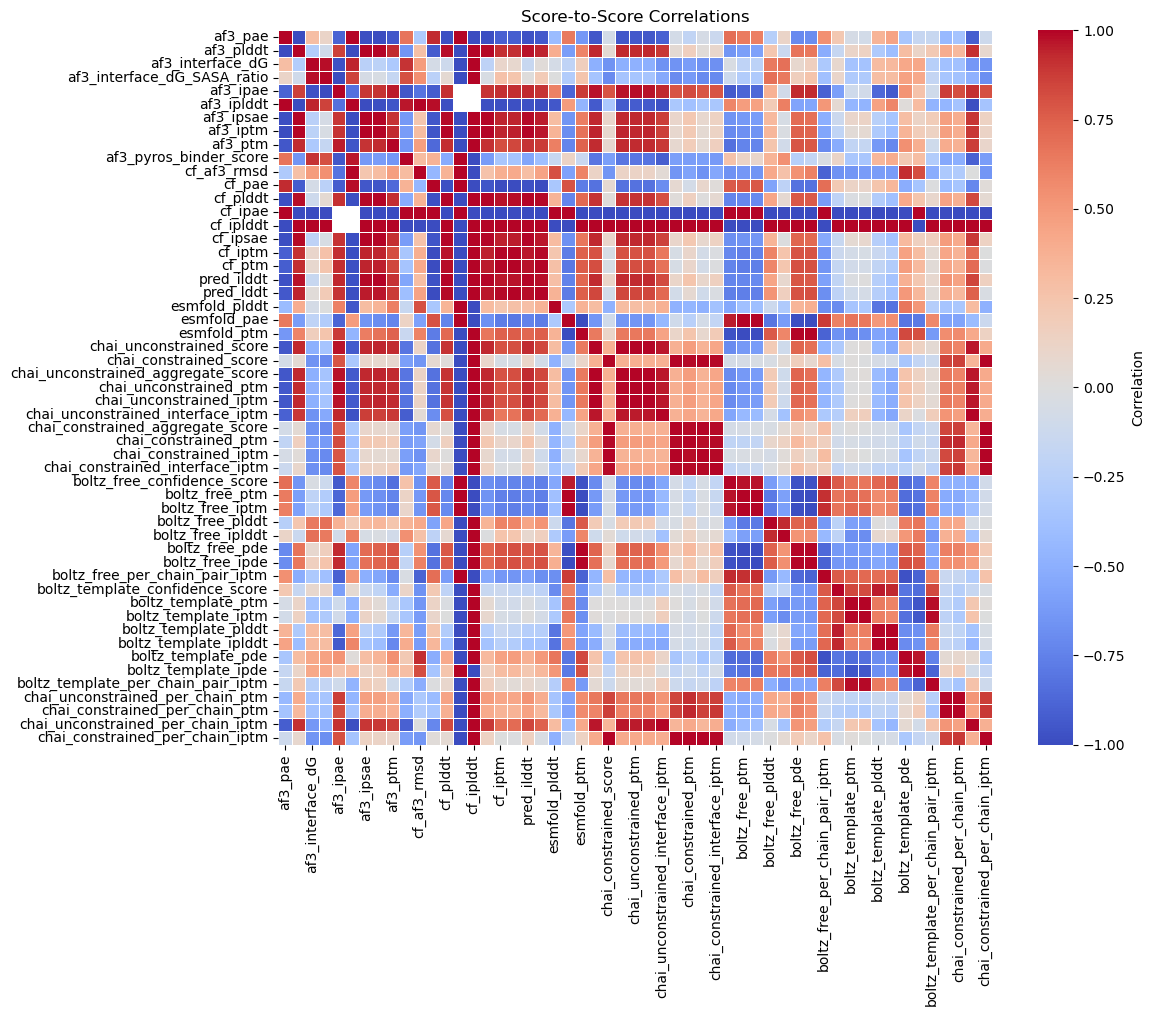

<Figure size 640x480 with 0 Axes>

In [36]:
# directions!!!!!

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create numeric dataframe and drop binder column
numeric_df = scores_df_extended.select_dtypes(include=[np.number])
numeric_df = numeric_df.dropna(axis=1, how='all')
numeric_df = numeric_df.drop('binder', axis=1, errors='ignore')
numeric_df = numeric_df.drop('KD[M]', axis=1, errors='ignore')
numeric_df = numeric_df.drop('EC50[M]', axis=1, errors='ignore')

# Calculate correlation matrix
correlation_matrix = numeric_df.corr()

# Plot correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={'label': 'Correlation'})
plt.title('Score-to-Score Correlations')
plt.tight_layout()
plt.show()
plt.savefig(OUTPUT_DIR / 'score_correlation_heatmap.png', dpi=150, bbox_inches='tight')

#### Separability (3 types for now...)

/tmp/ipykernel_130790/297939318.py:35: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=scores_df_extended, x=col, hue=hue_param, fill=True, ax=axes[i], common_grid= False, common_norm=False, palette='coolwarm' if has_both_classes else None)
/tmp/ipykernel_130790/297939318.py:35: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=scores_df_extended, x=col, hue=hue_param, fill=True, ax=axes[i], common_grid= False, common_norm=False, palette='coolwarm' if has_both_classes else None)
/tmp/ipykernel_130790/297939318.py:35: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=scores_df_extended, x=col, hue=hue_param, fill=True, ax=axes[i], common_grid= False, common_norm=False, palette='coolwarm' if has_both_classes else None)
/tmp/ipykernel_1

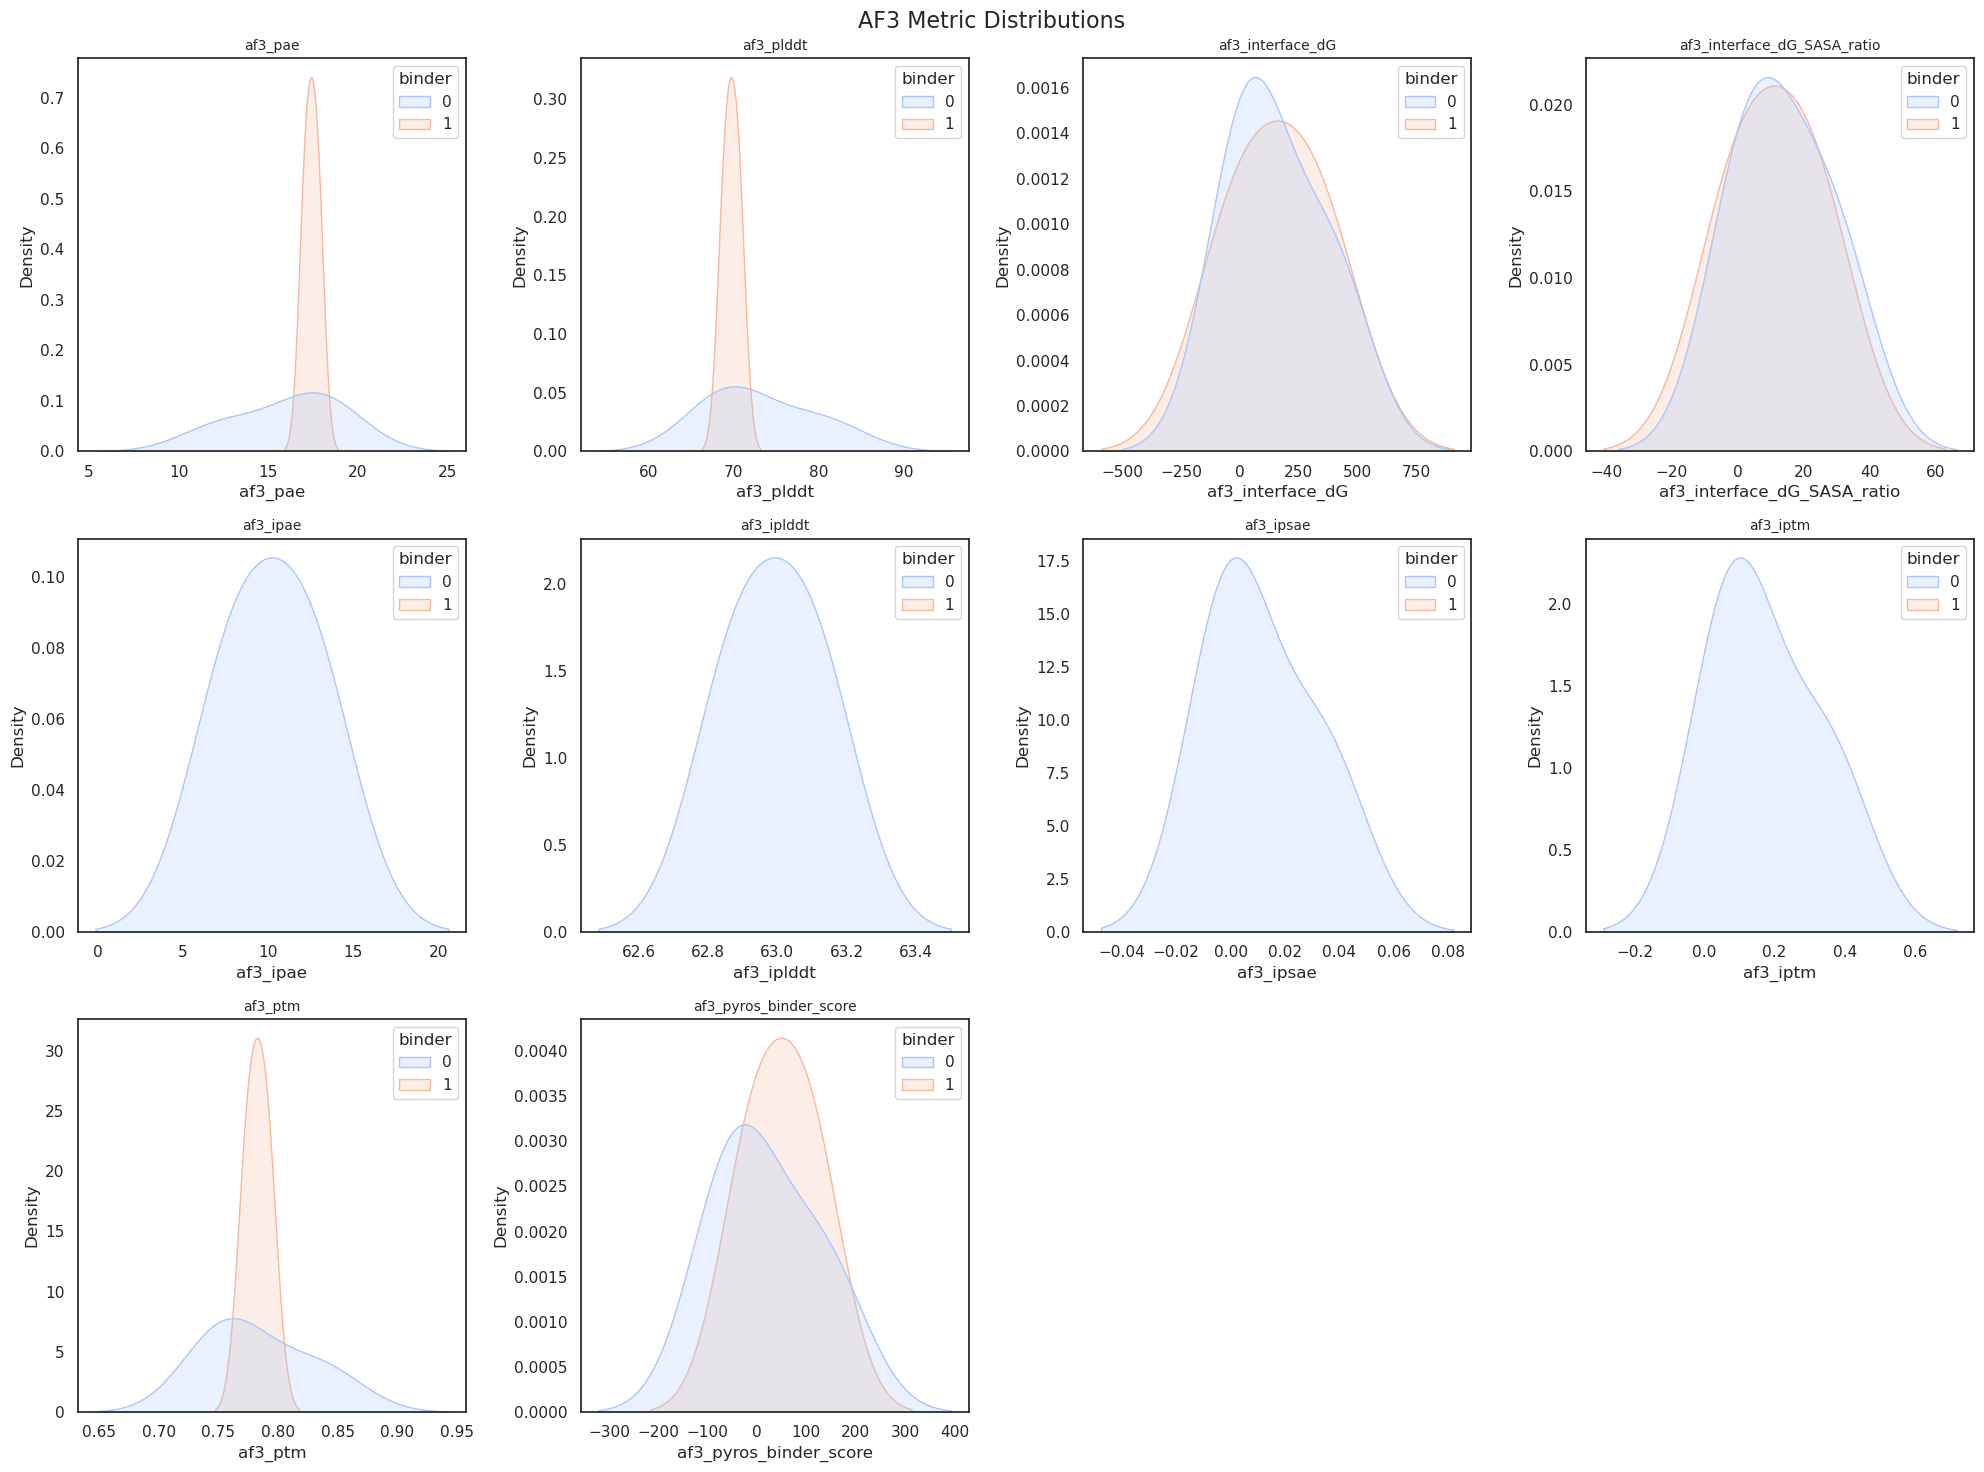

/tmp/ipykernel_130790/297939318.py:35: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=scores_df_extended, x=col, hue=hue_param, fill=True, ax=axes[i], common_grid= False, common_norm=False, palette='coolwarm' if has_both_classes else None)
/tmp/ipykernel_130790/297939318.py:35: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  sns.kdeplot(data=scores_df_extended, x=col, hue=hue_param, fill=True, ax=axes[i], common_grid= False, common_norm=False, palette='coolwarm' if has_both_classes else None)


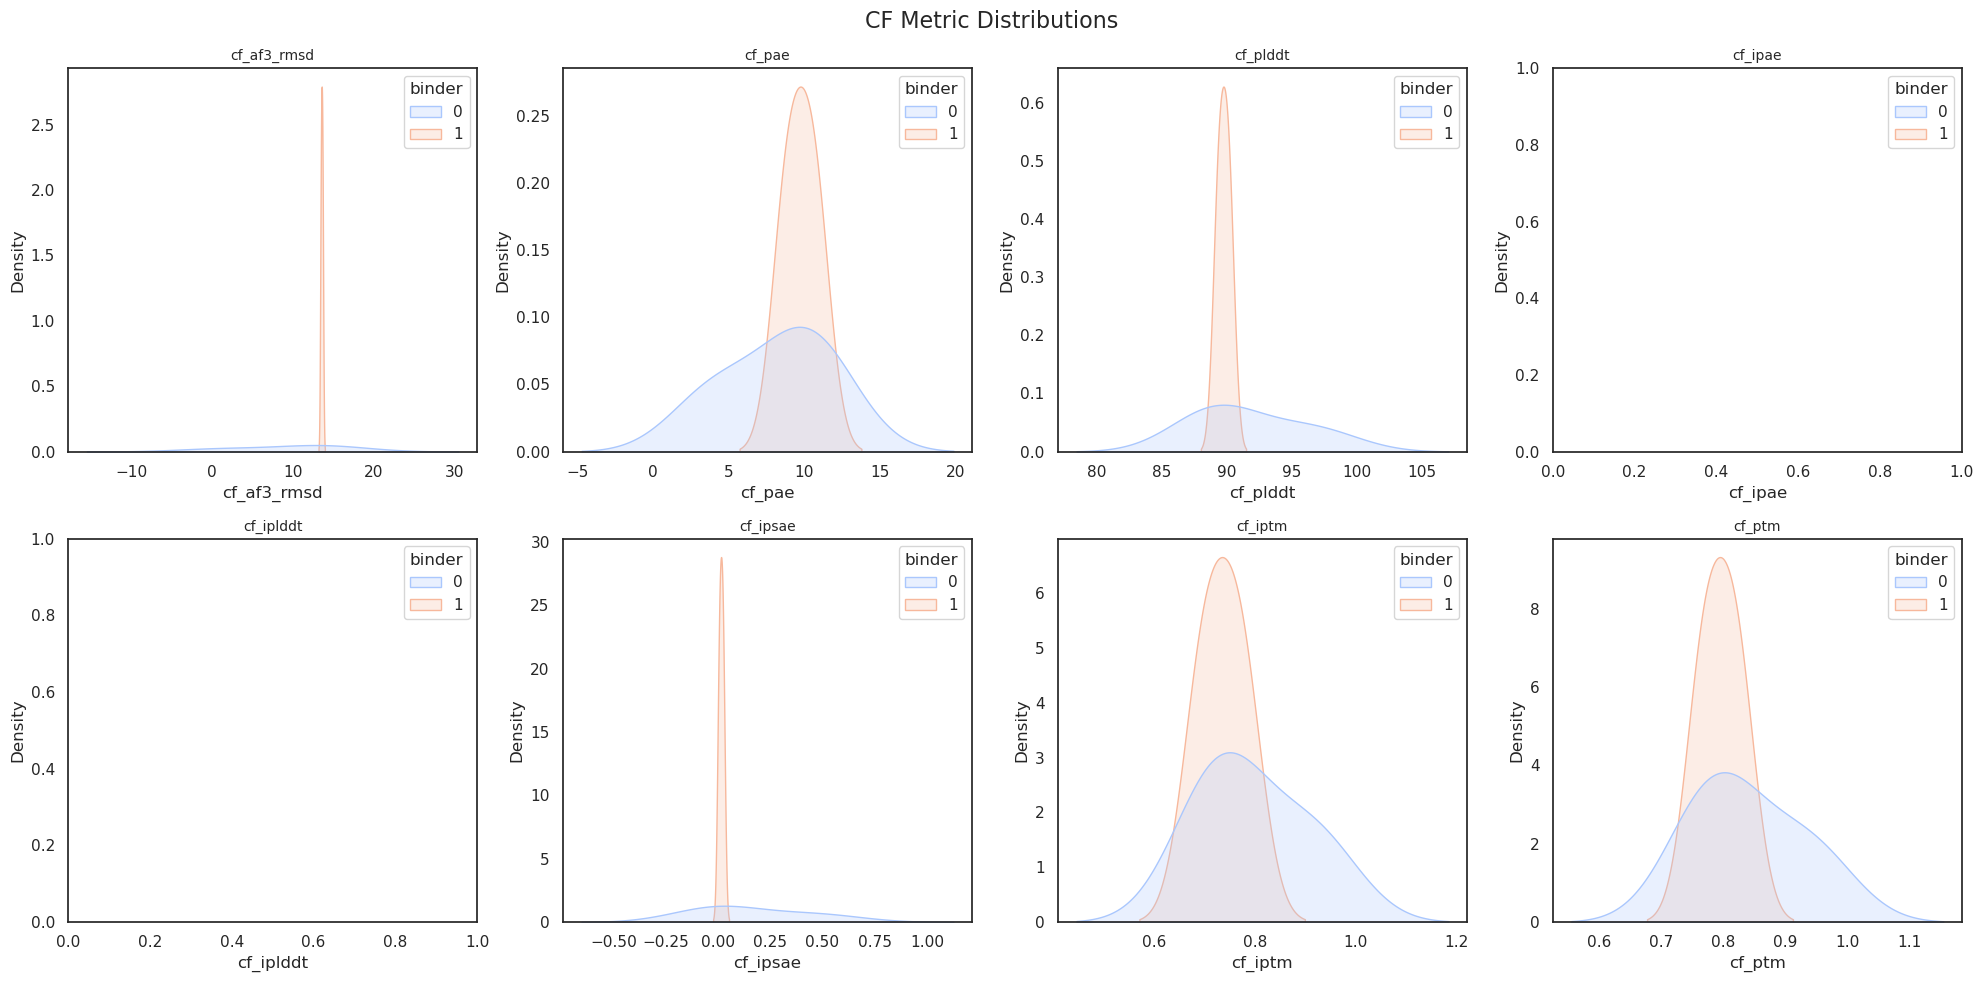

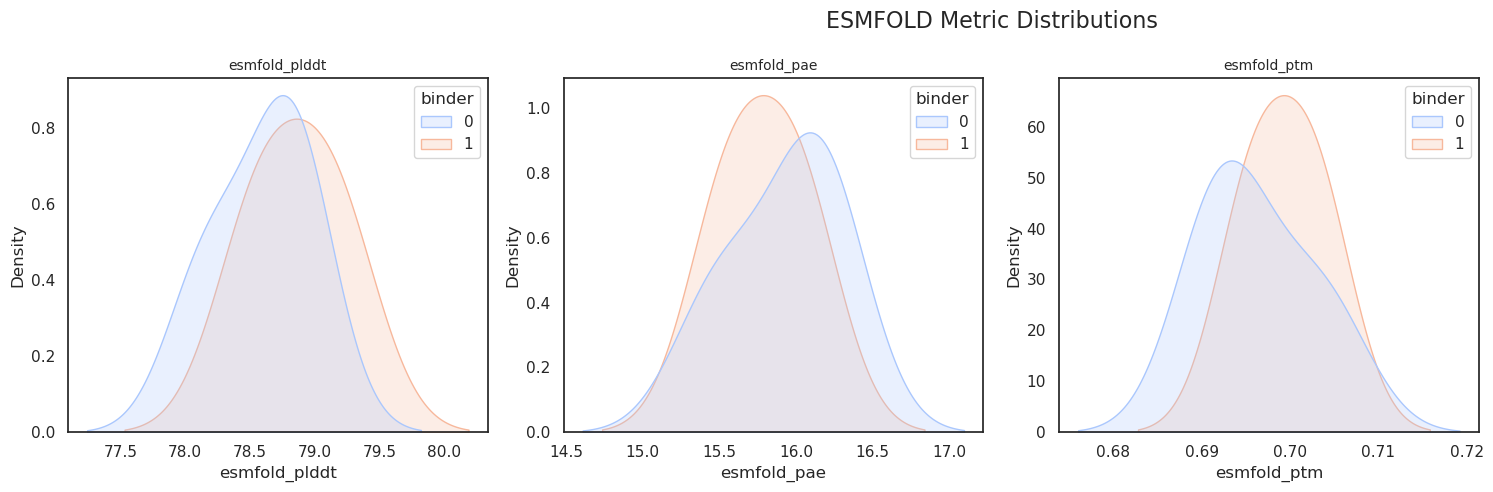

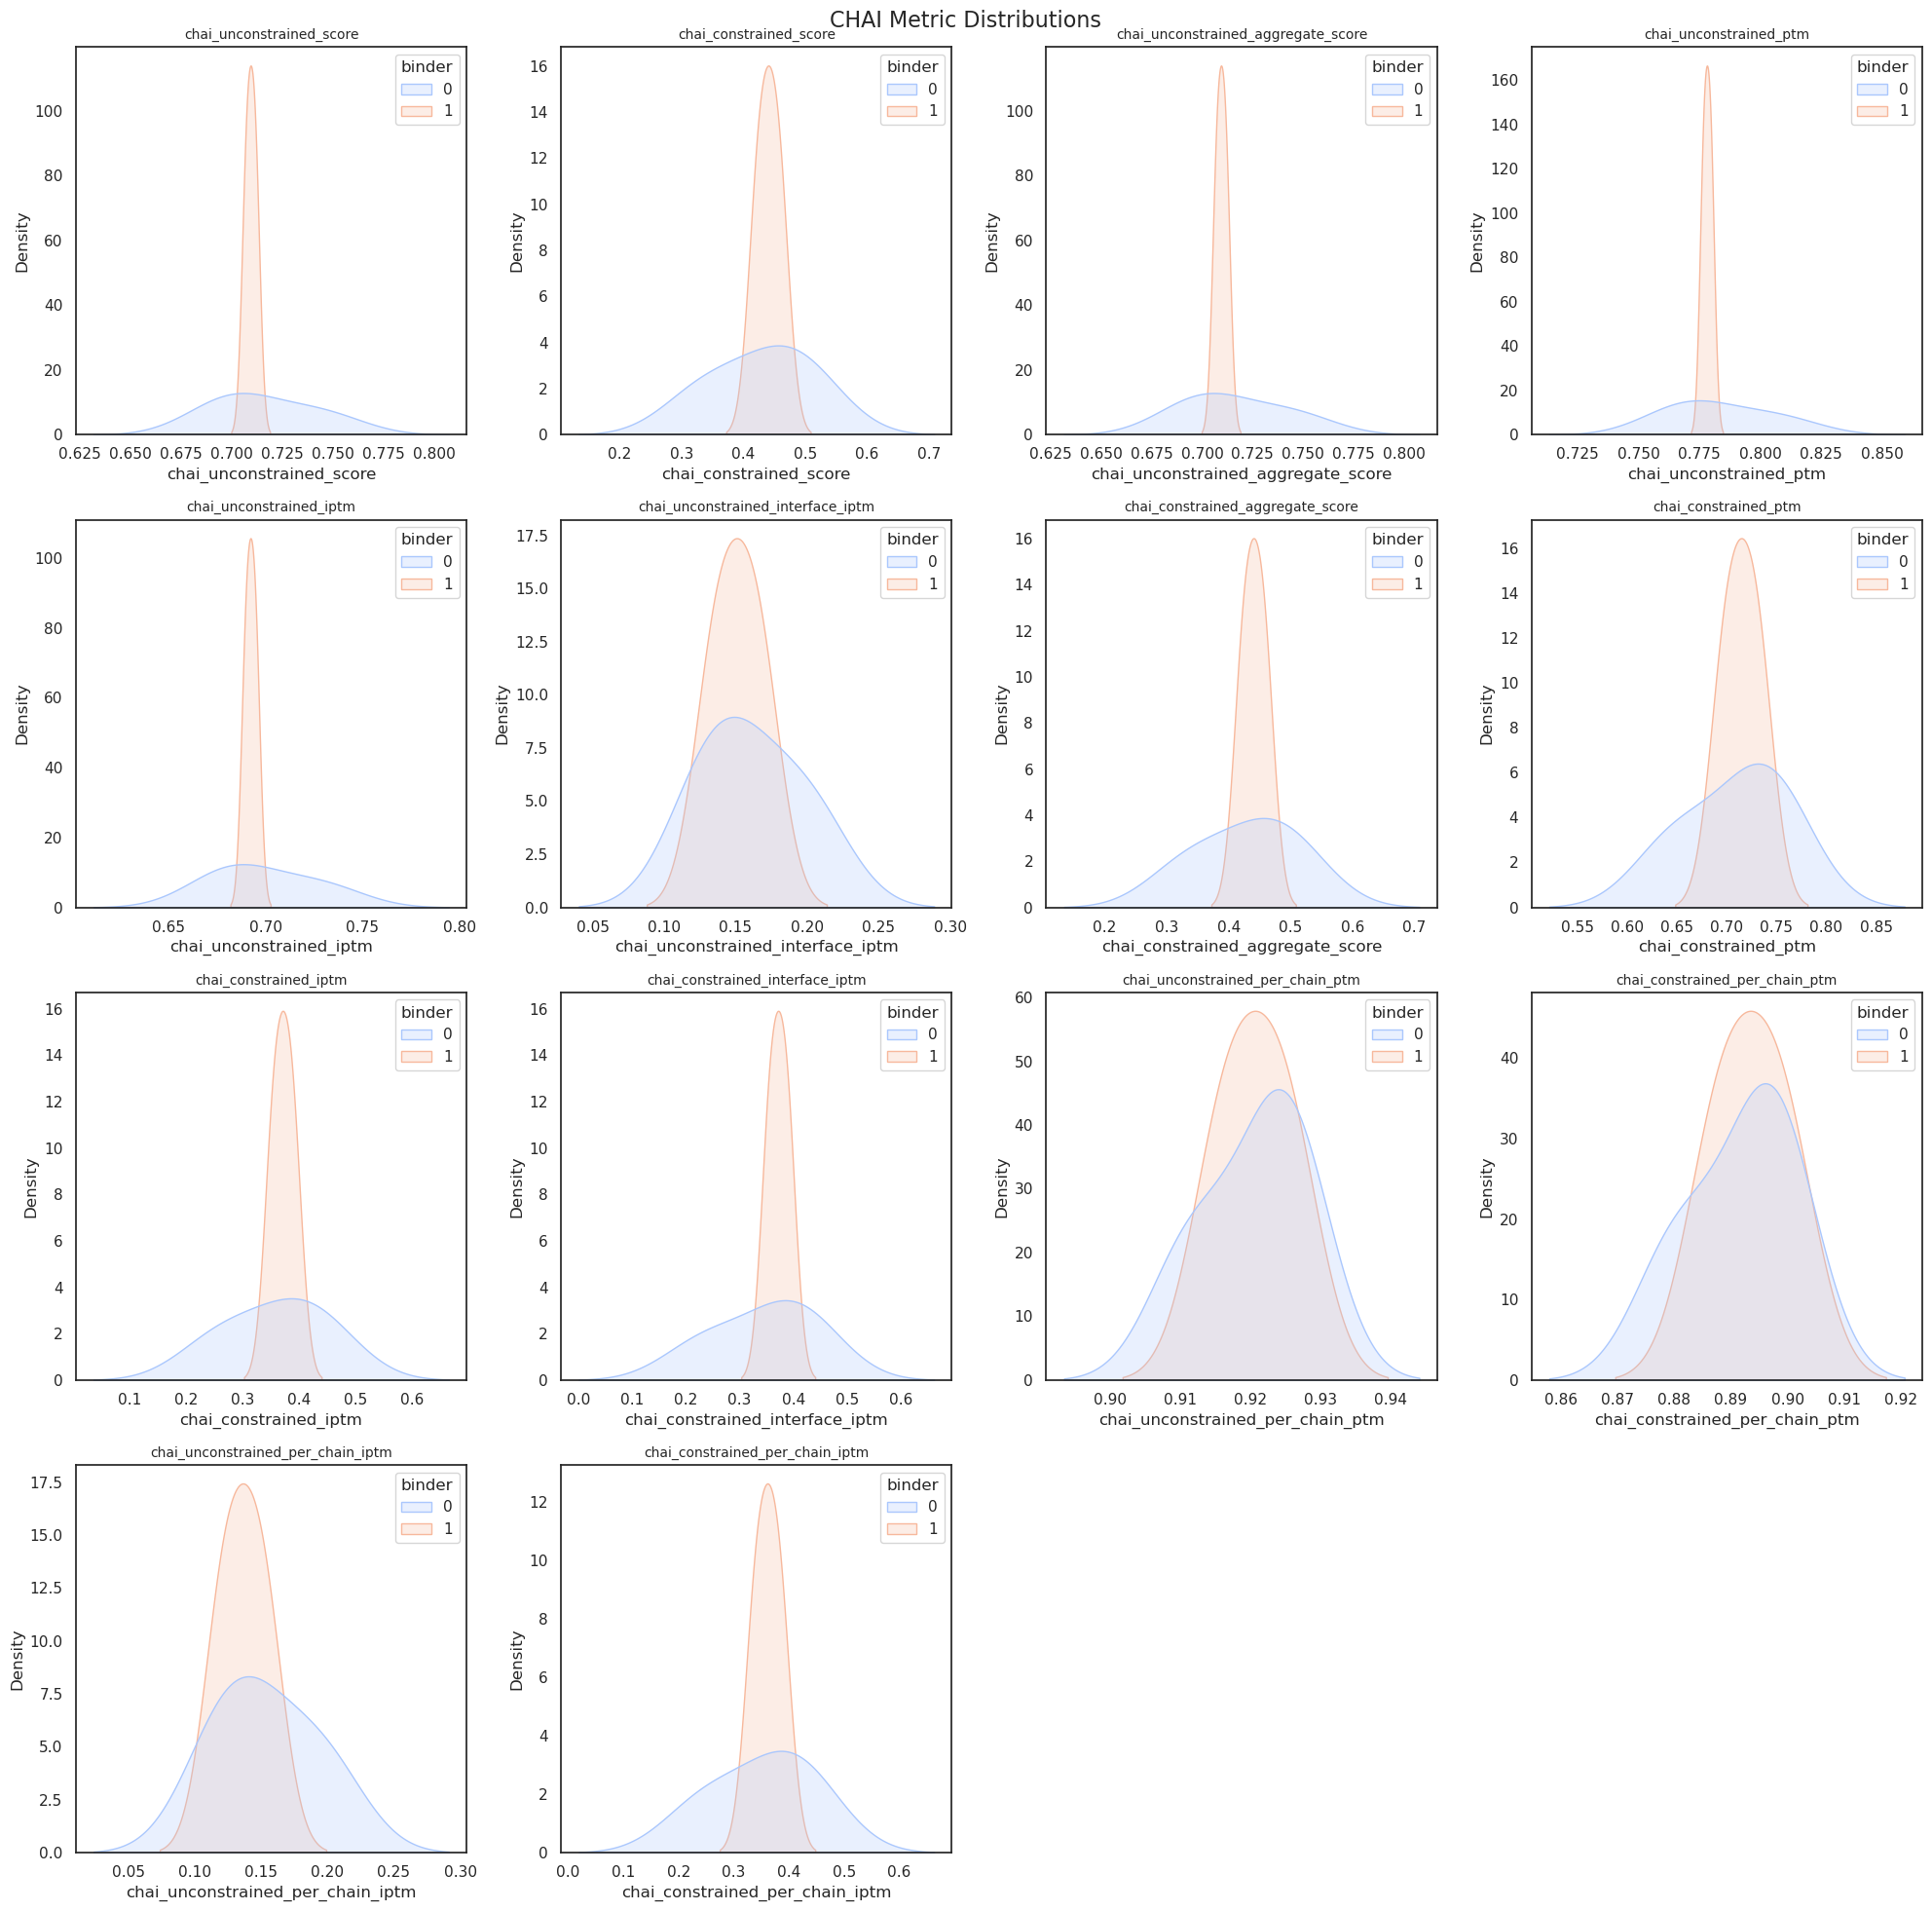

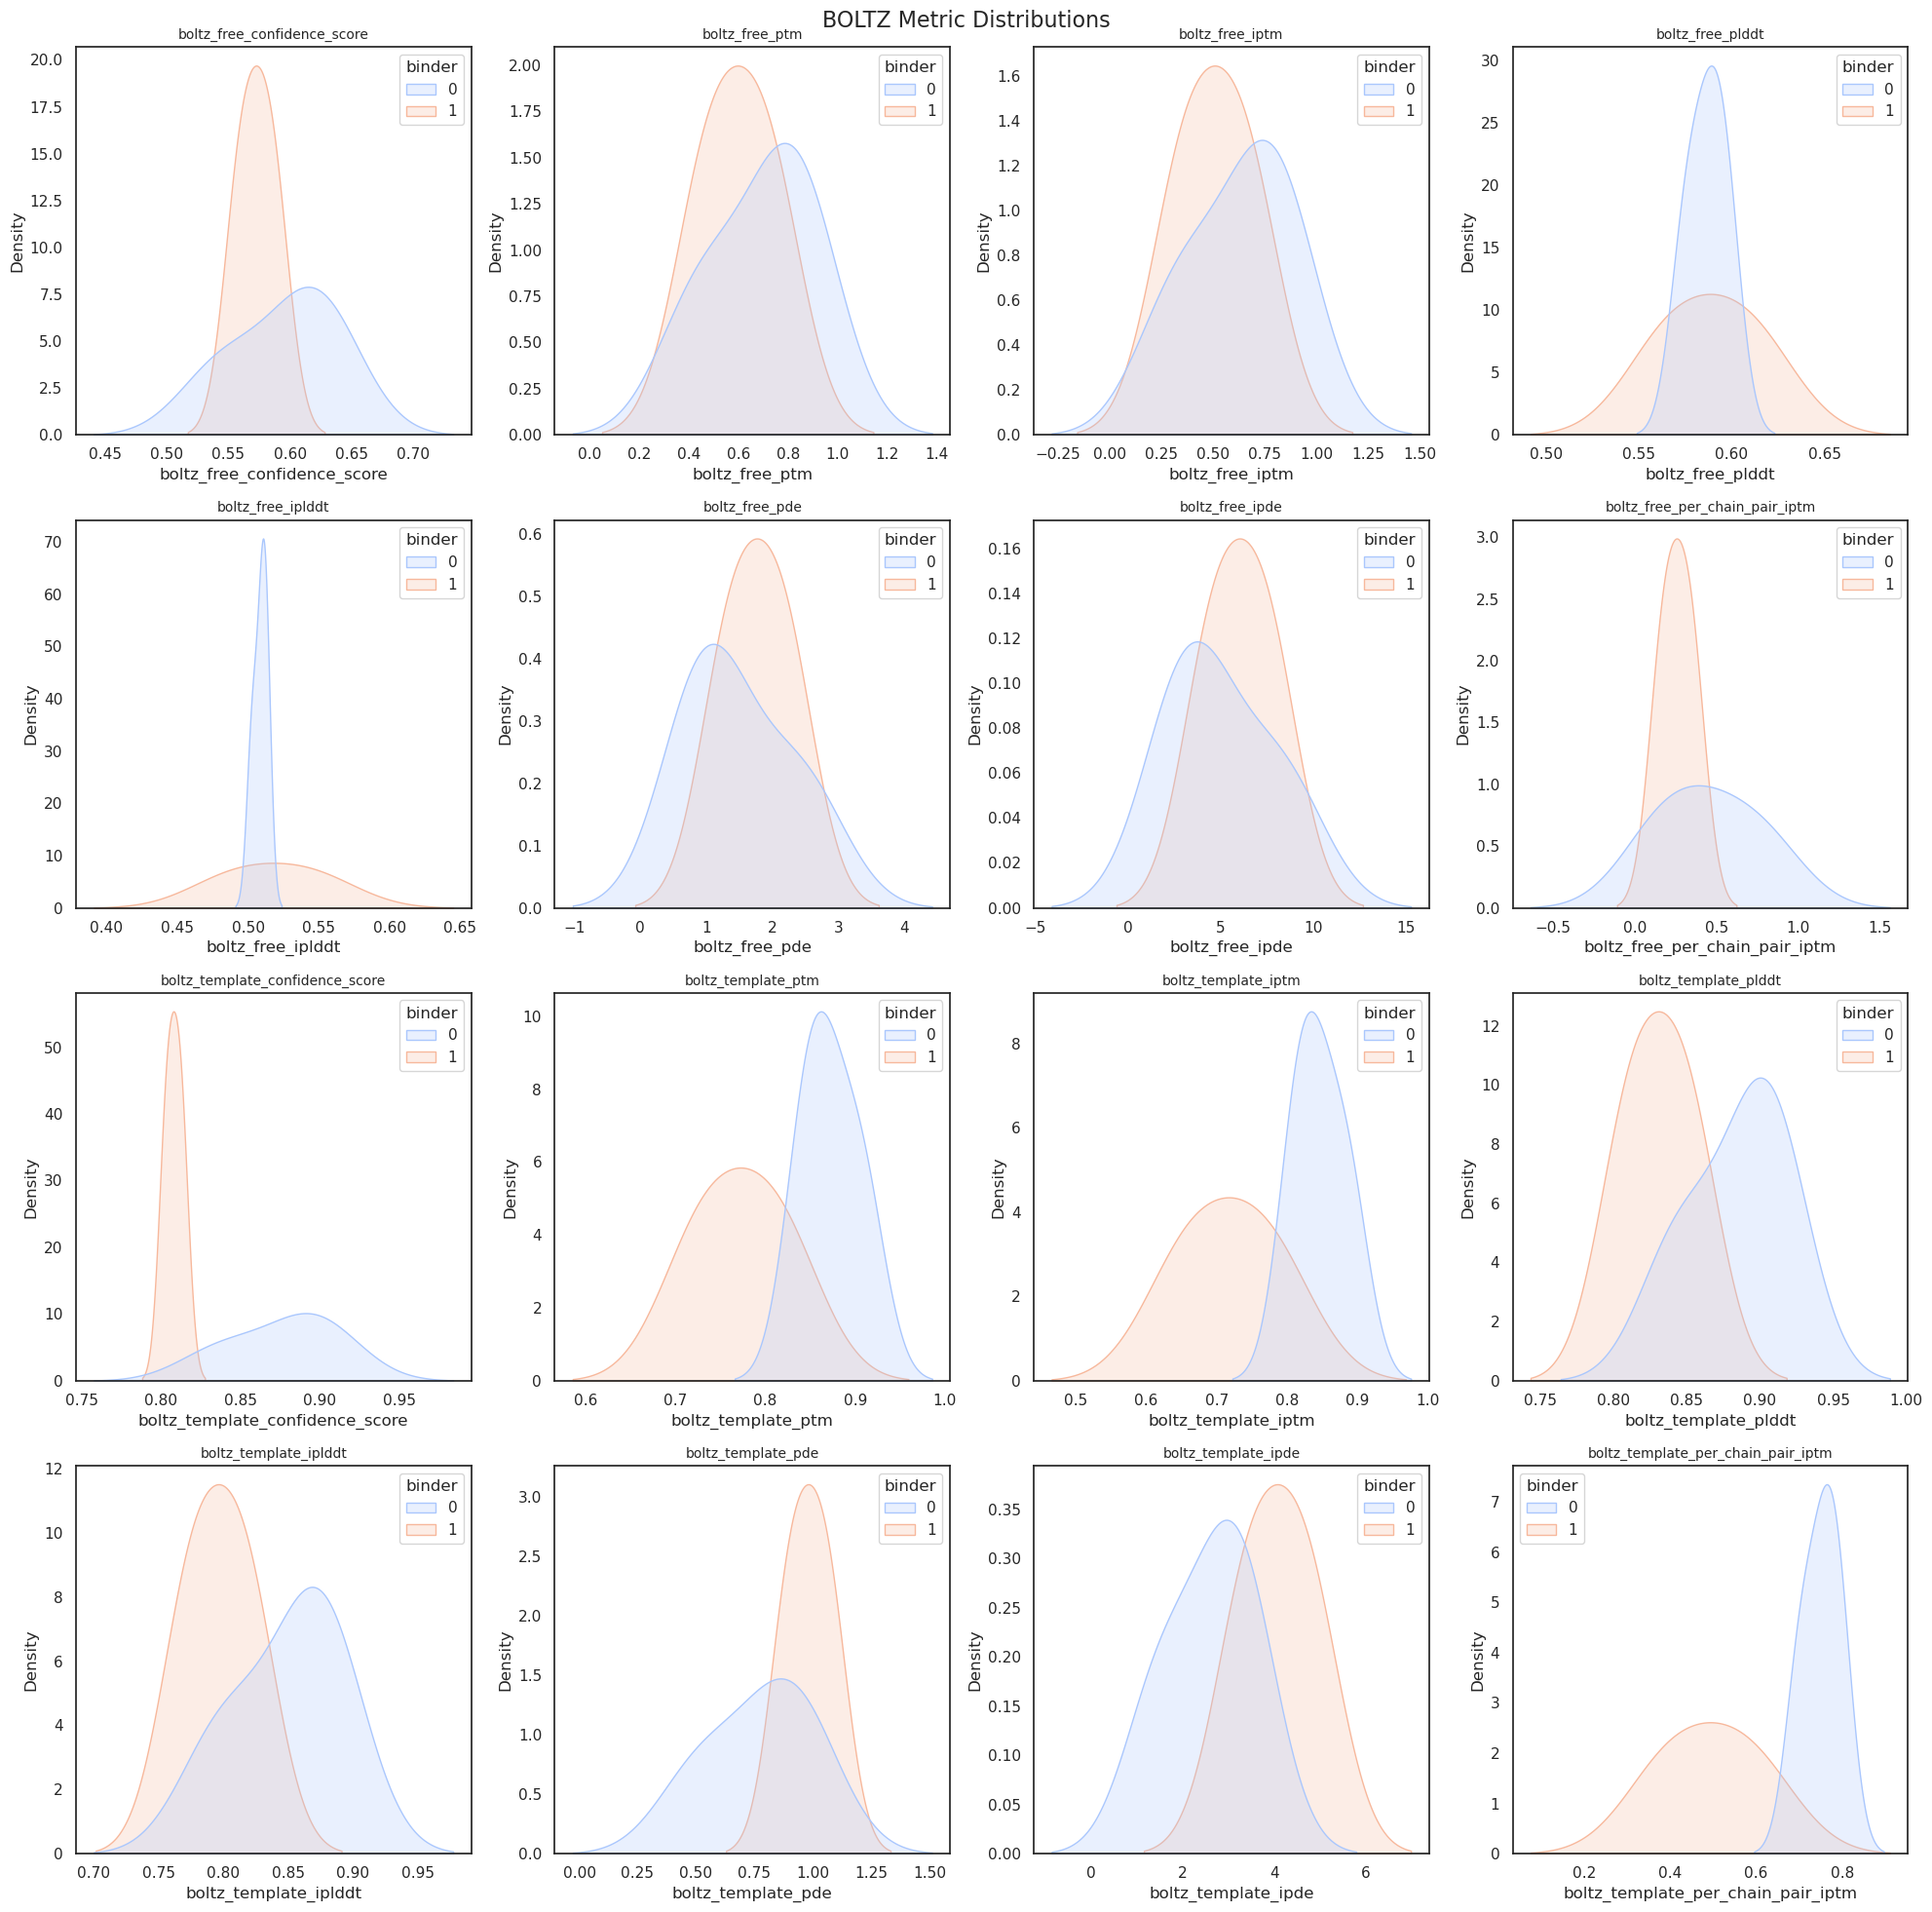

In [37]:
# Group metrics by model
models = ['af3', 'cf', 'esmfold', 'chai', 'boltz']
model_groups = {model: [c for c in numeric_cols if c.startswith(model)] for model in models}

# Detailed Separability

# Distributions
sns.set_theme(style="white")
has_both_classes = scores_df_extended['binder'].nunique() > 1

for model, cols in model_groups.items():
    valid_cols = [c for c in cols if scores_df_extended[c].notna().any()]
    if not valid_cols:
        print(f"Skipping {model.upper()}: No valid numeric data found.")
        continue

    # Calculate grid size
    n_cols = 4
    n_rows = (len(valid_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    

    for i, col in enumerate(valid_cols):
        ax = axes[i]
        
        # Use the dataframe that actually contains 'binder_type'
        plot_df = scores_df_extended.dropna(subset=[col]).copy()
        
        if plot_df.empty:
            continue

        # Only use 'hue' if both Binders and Non-Binders exist
        hue_param = 'binder' if has_both_classes else None
        sns.kdeplot(data=scores_df_extended, x=col, hue=hue_param, fill=True, ax=axes[i], common_grid= False, common_norm=False, palette='coolwarm' if has_both_classes else None)
        axes[i].set_title(col, fontsize=10)
    
    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle(f"{model.upper()} Metric Distributions", fontsize=16)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{model}_distributions.png")
    plt.show()
    plt.close()

In [40]:
# Create the 3-group logic to be able to distuinguish between easy and hard negatives
def categorize_row(row):
    if row['binder'] == 1:
        return 'Binder'
    elif row['binder'] == 0:
        return 'Non-Binder'


scores_df_extended['binder'] = scores_df_extended.apply(categorize_row, axis=1)

# Map the colors explicitly to these 3 groups
colors_map = {
    'Binder': '#2ecc71',      # Green
    'Non-Binder': "#67e7dd",  # Aquamarine
}


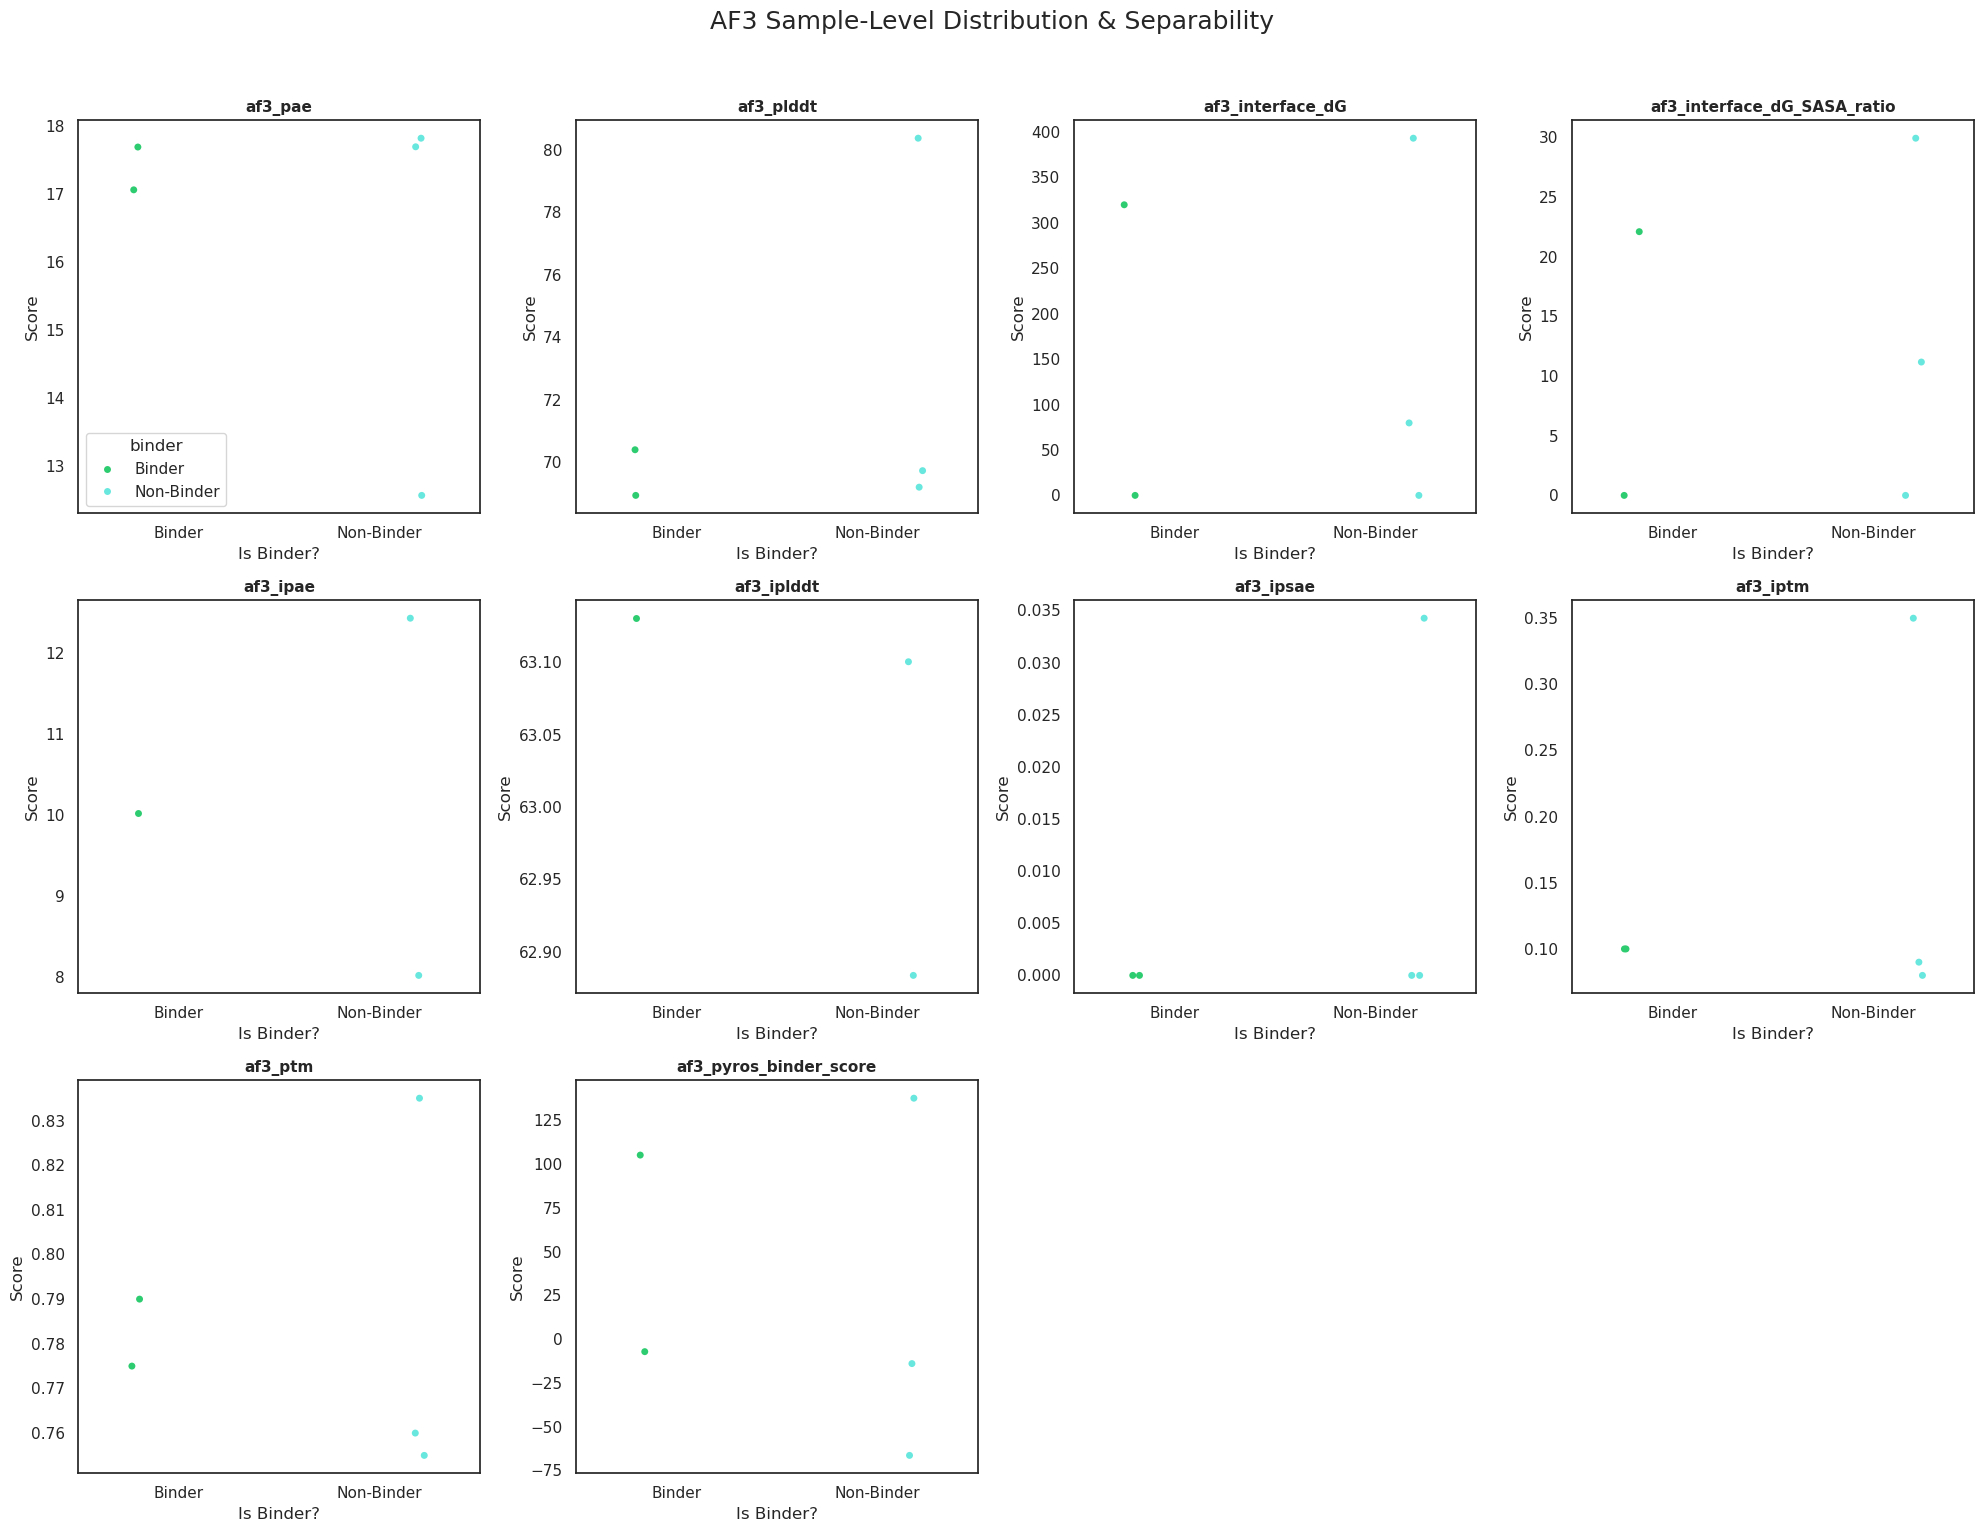

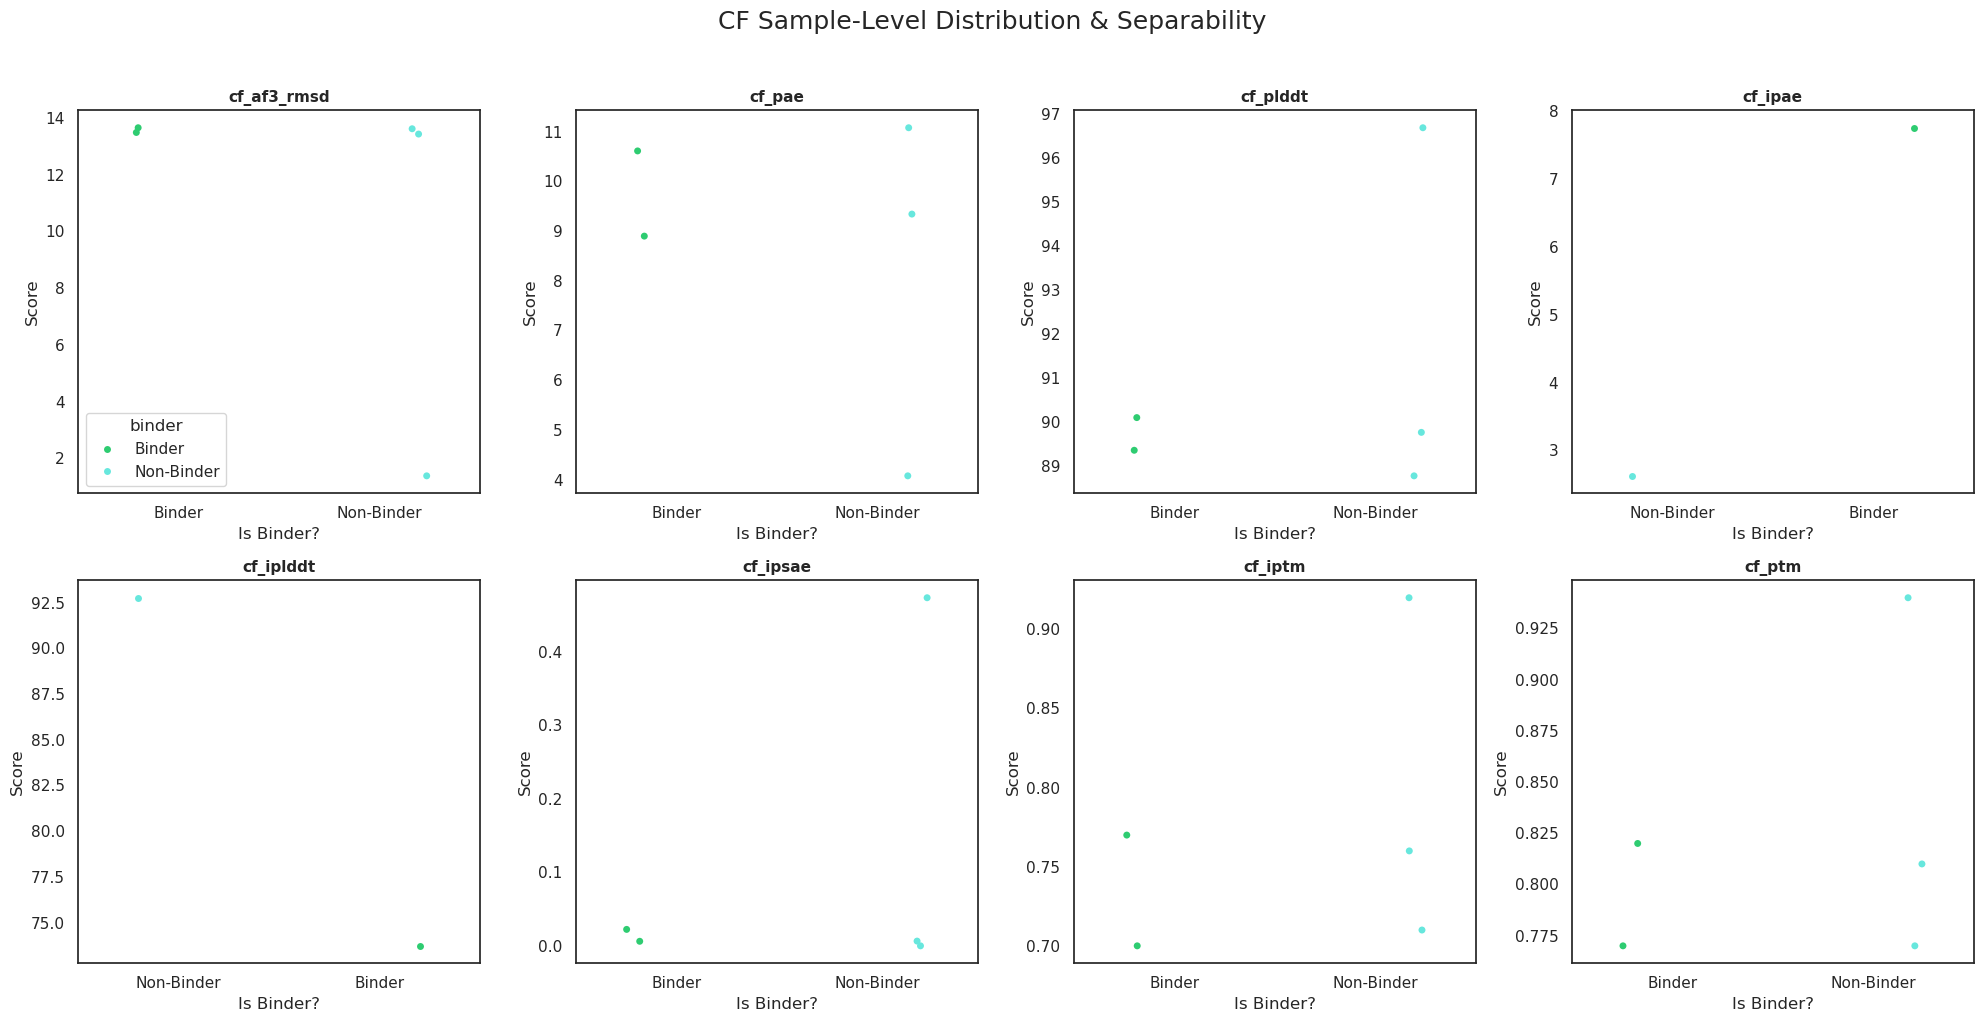

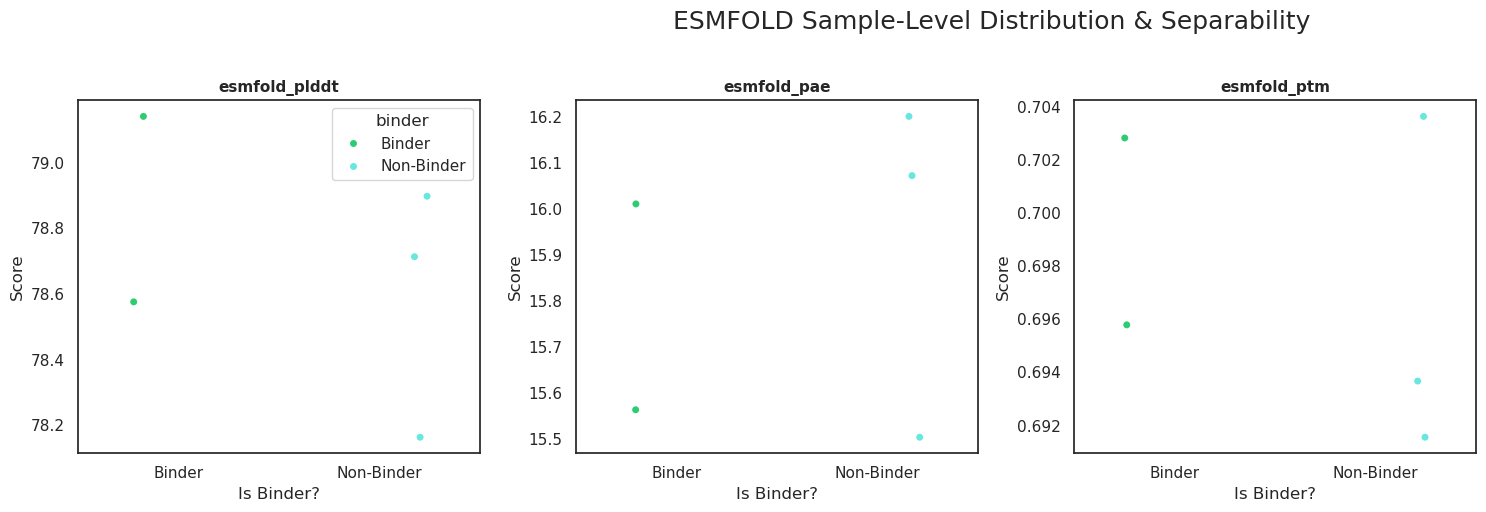

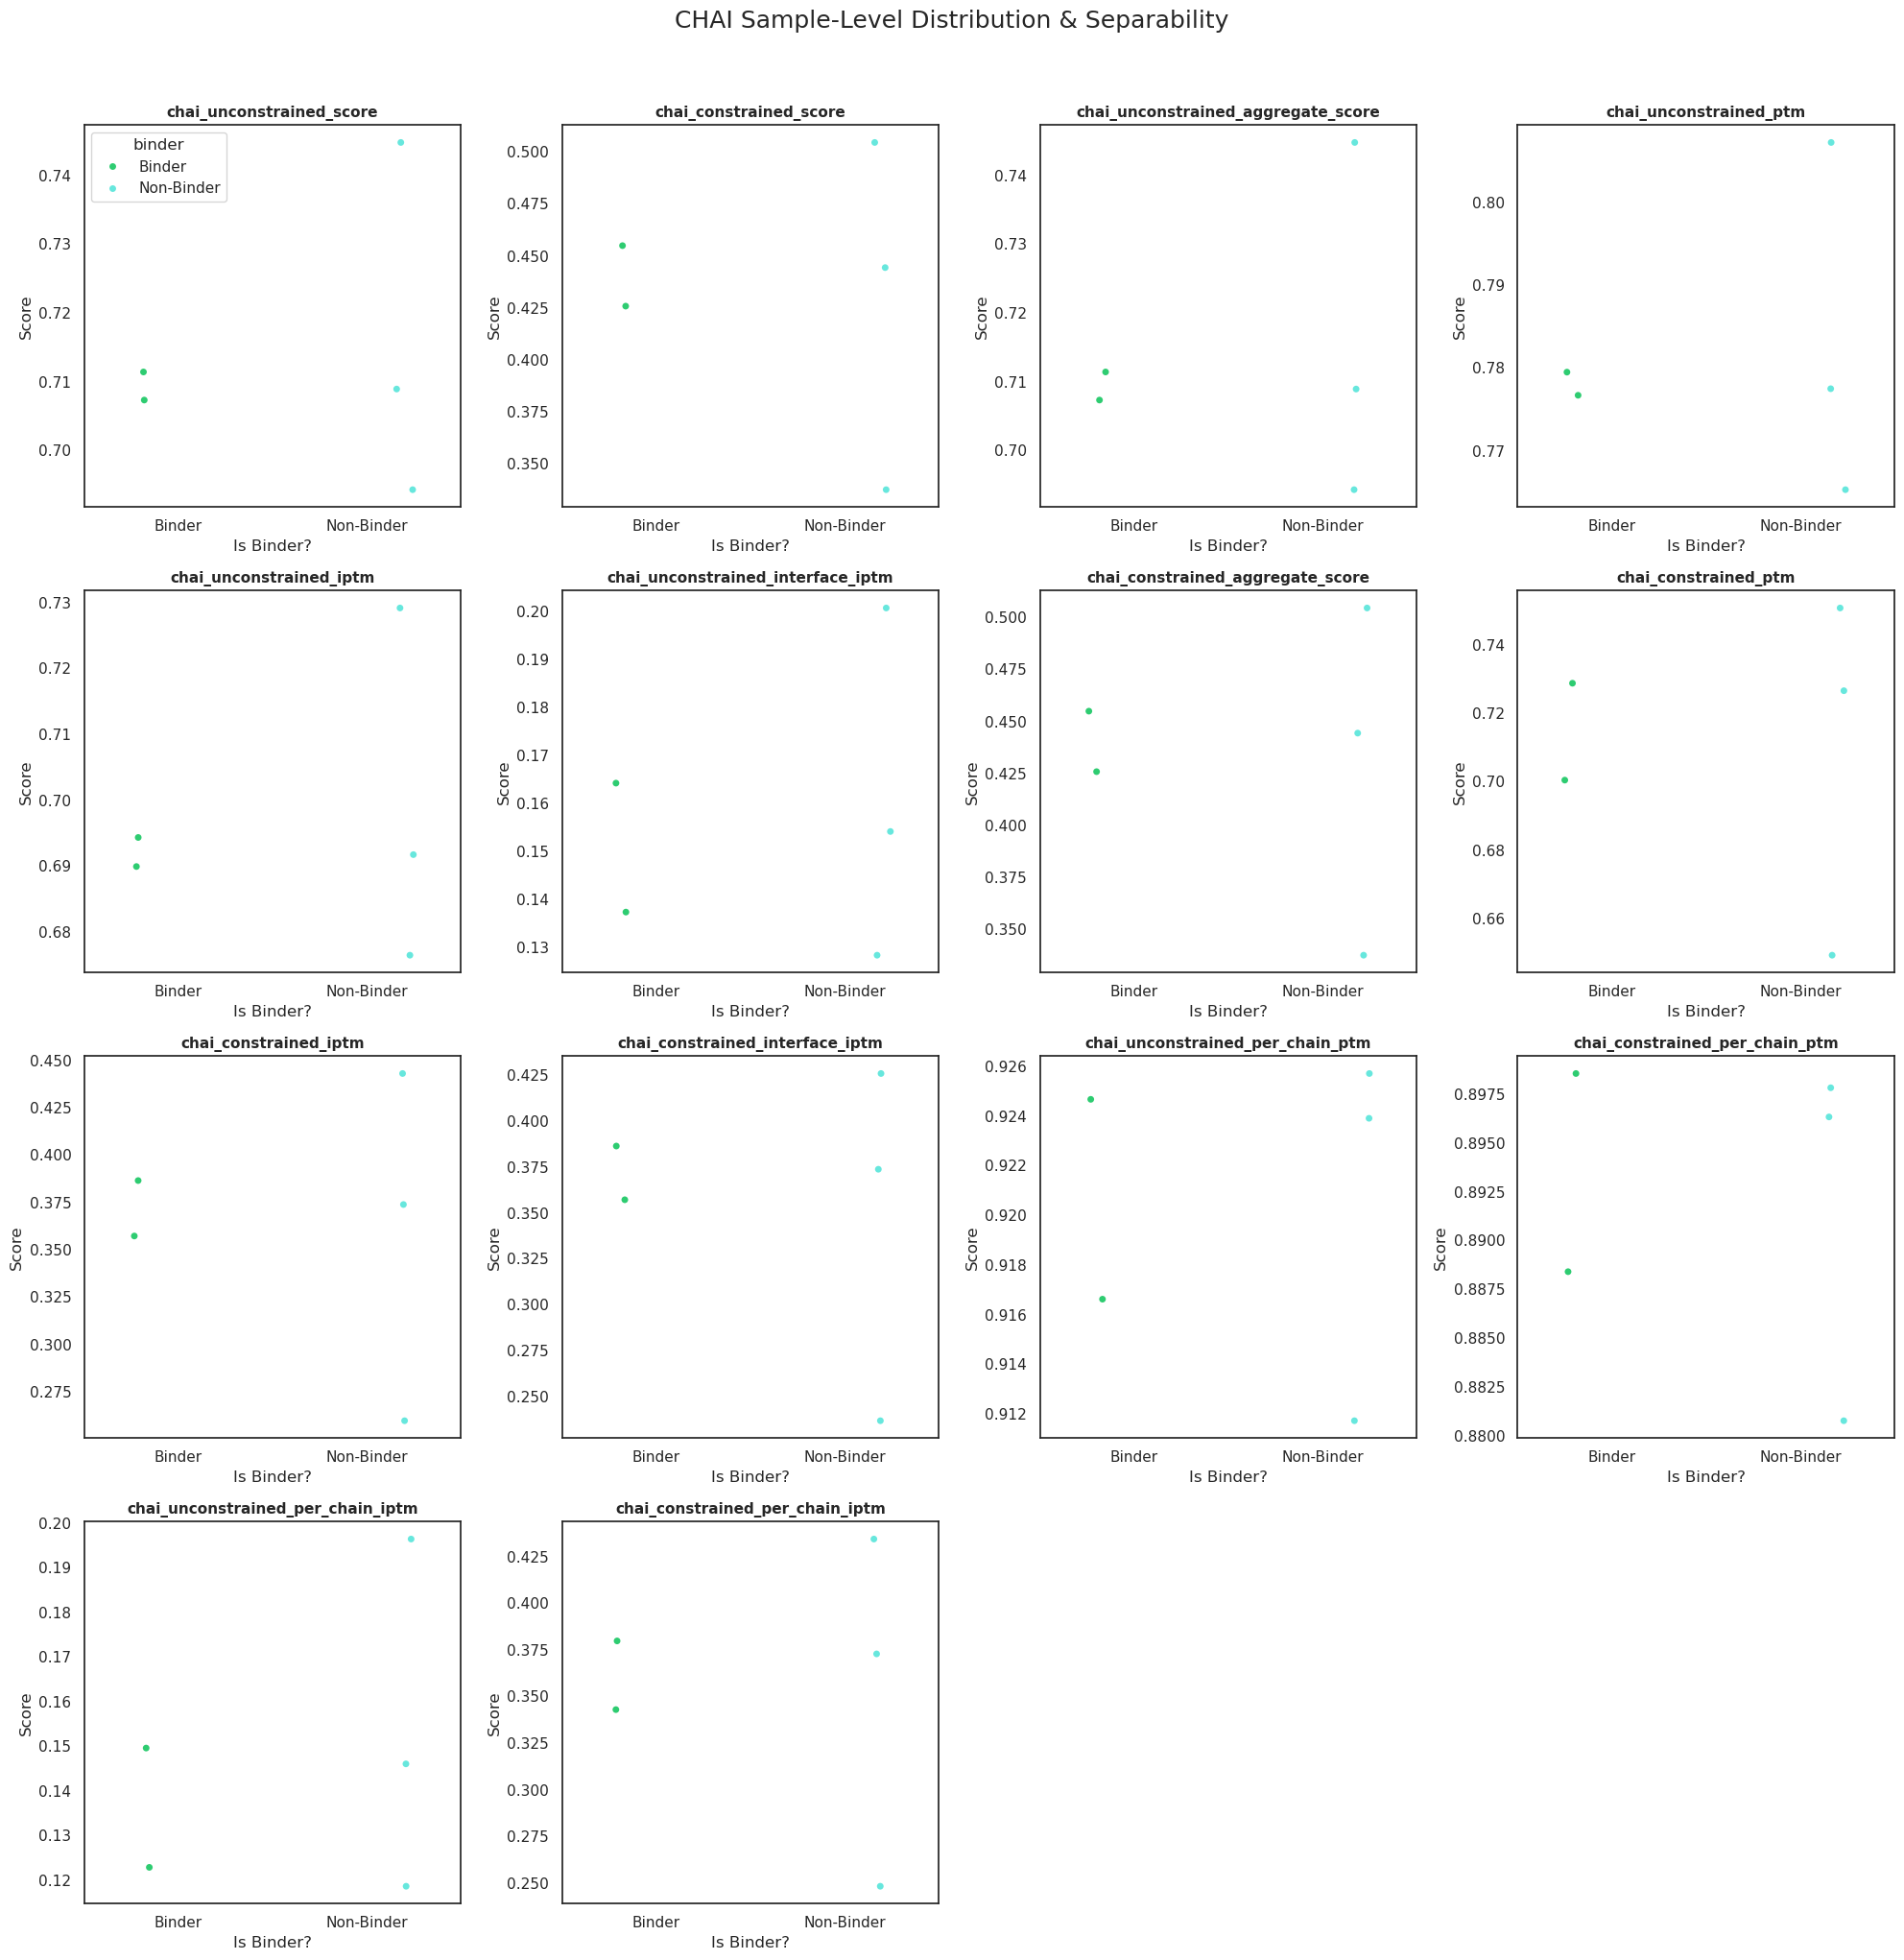

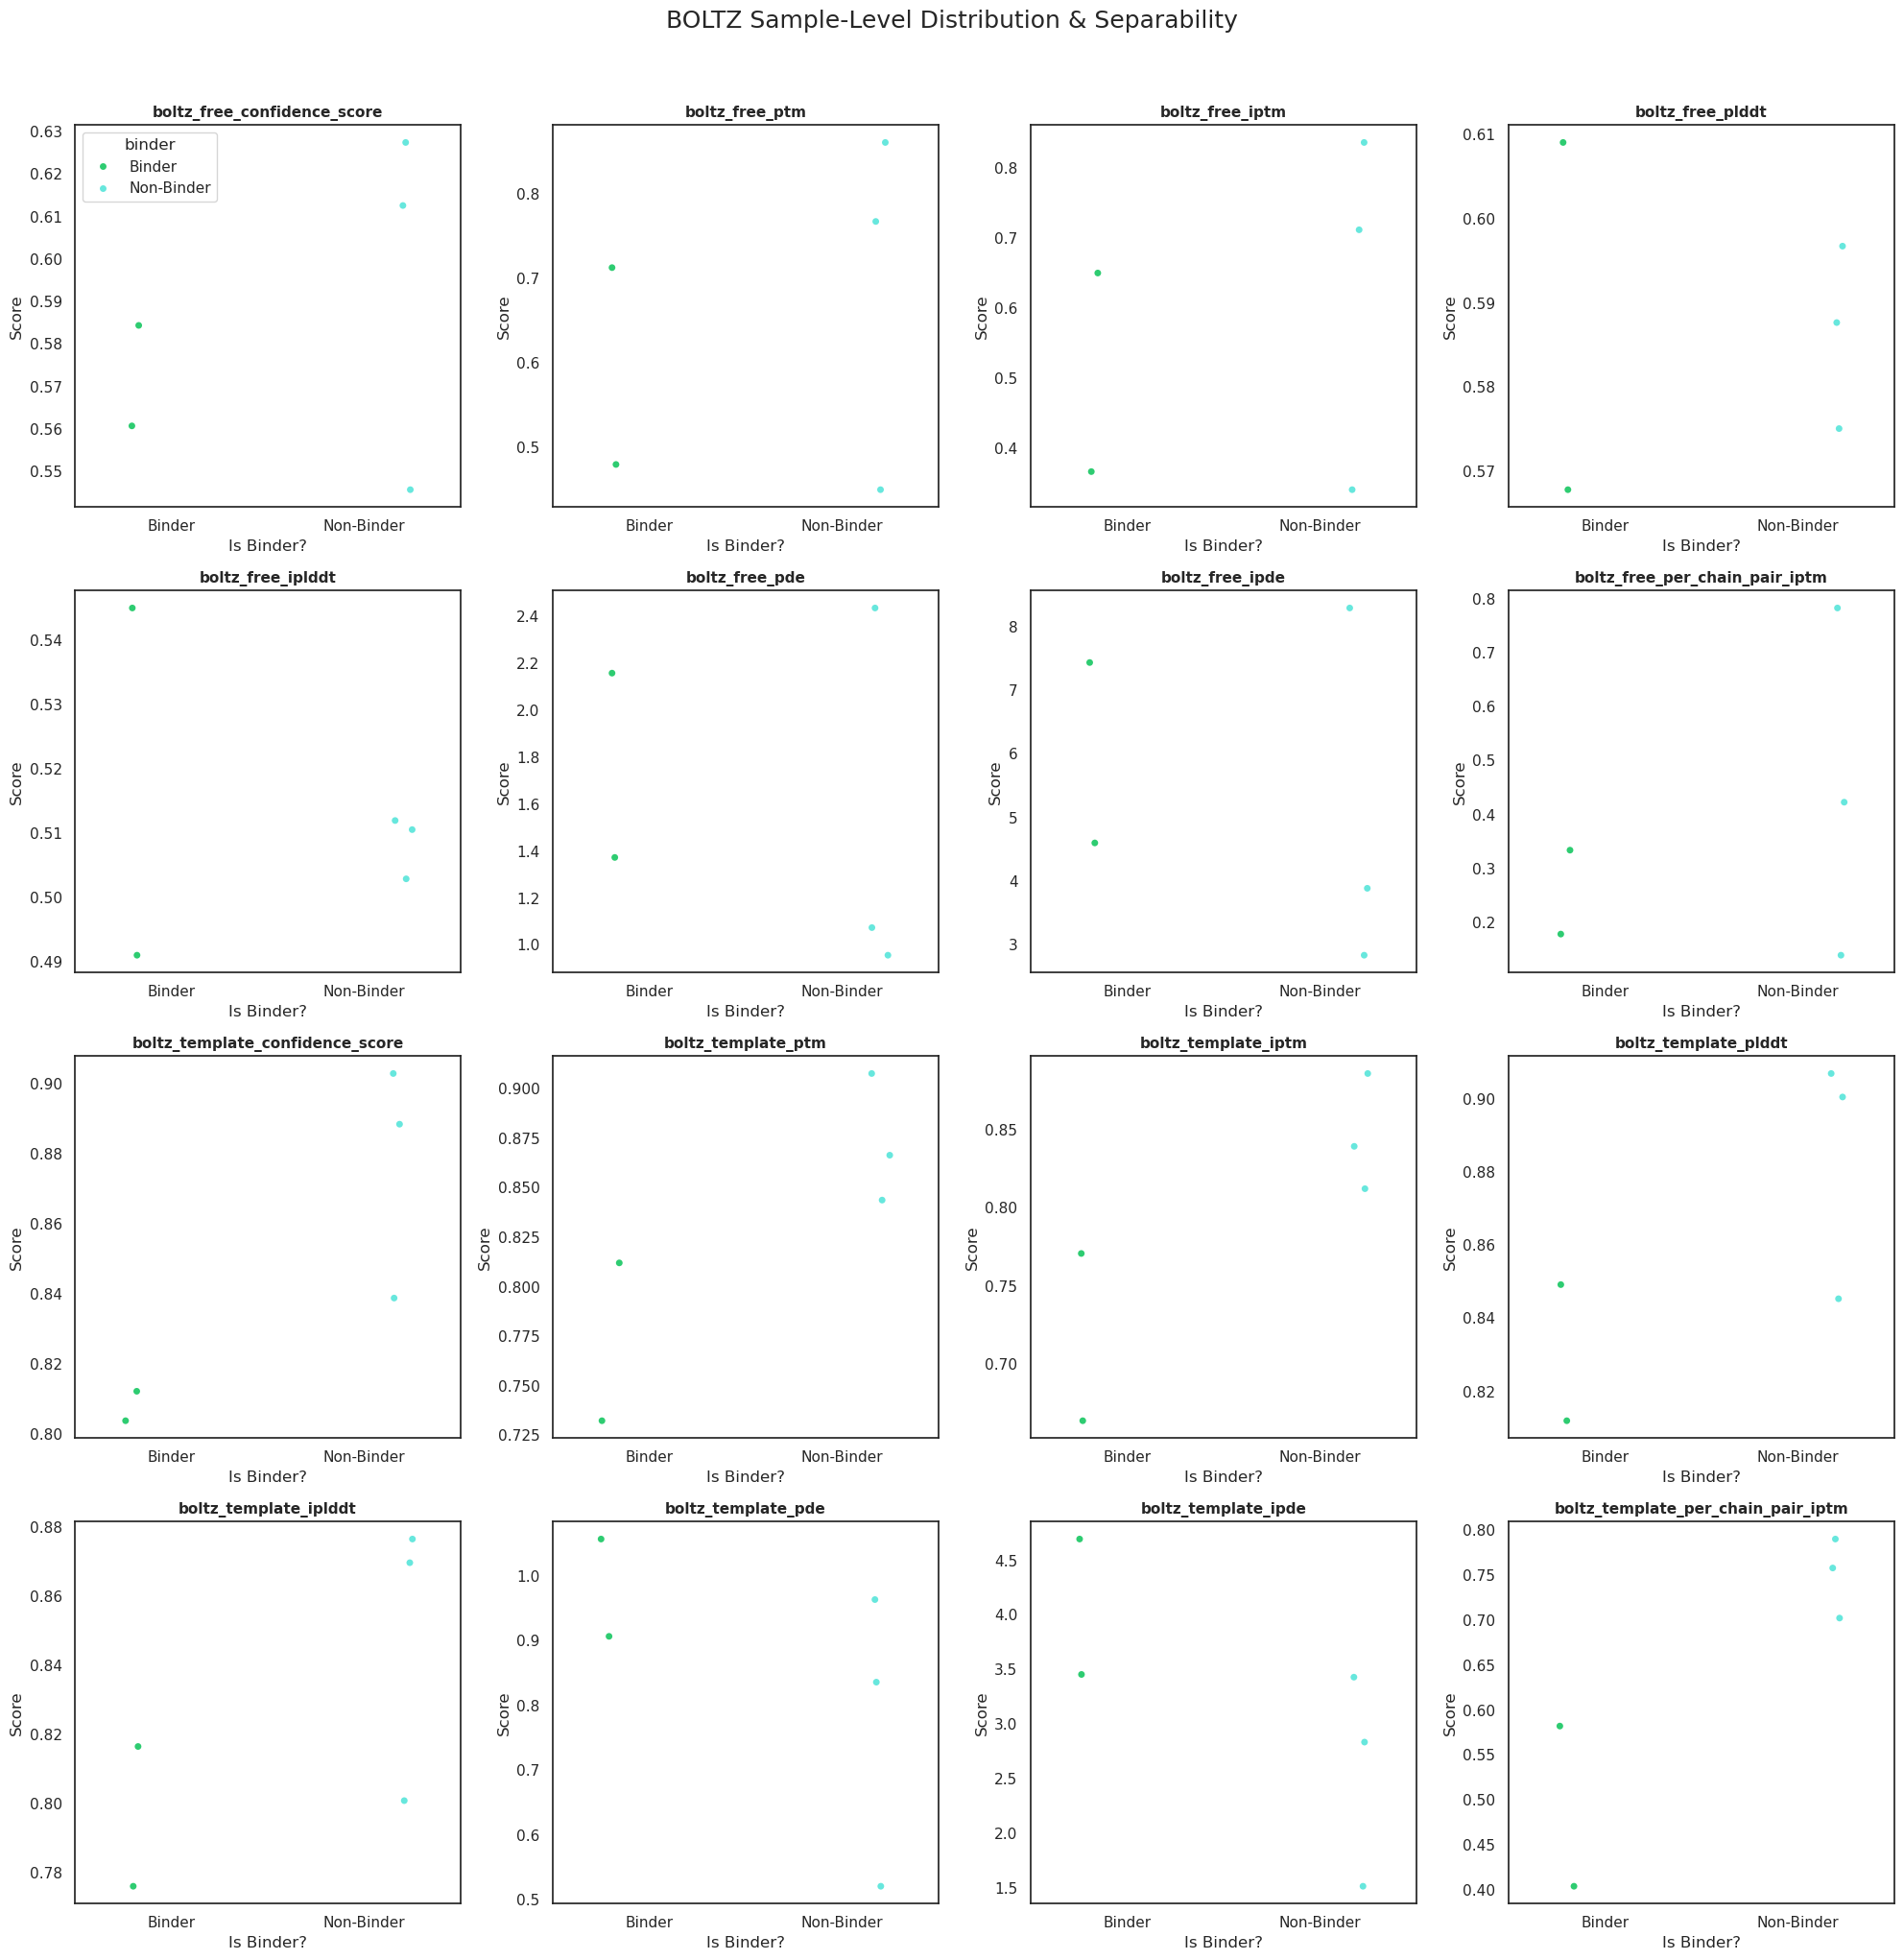

Finished generating scatterplots for BOLTZ group.


In [43]:
# Detailed Separability

import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics
sns.set_theme(style="white")

# Determine if we have multiple classes to compare
has_both_classes = scores_df_extended['binder'].nunique() > 1

for model, cols in model_groups.items():
    if not cols: continue
    
    # Filter out columns that are entirely NaN to prevent the "bxp length" error
    valid_cols = [c for c in cols if scores_df_extended[c].notna().any()]
    if not valid_cols:
        print(f"Skipping {model.upper()}: No valid numeric data found.")
        continue

    # Calculate grid size
    n_cols = 4
    n_rows = (len(valid_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, col in enumerate(valid_cols):
        ax = axes[i]
        
        # Use the dataframe that actually contains 'binder_type'
        plot_df = scores_df_extended.dropna(subset=[col]).copy()
        
        if plot_df.empty:
            continue

        # Stripplot with the 3-way hue
        sns.stripplot(
            data=plot_df, 
            x='binder', 
            y=col, 
            hue='binder',
            dodge=True,
            jitter=True, 
            palette=colors_map,
            ax=ax,
            legend=(i == 0) # Legend on first plot only
        )
        
        
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Is Binder?')
        ax.set_ylabel('Score')

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle(f"{model.upper()} Sample-Level Distribution & Separability", fontsize=18, y=1.02)
    plt.tight_layout()
    
    # Save output
    save_path = OUTPUT_DIR / f"{model}_separability_scatter.png"
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show() 
    
print(f"Finished generating scatterplots for {model.upper()} group.")

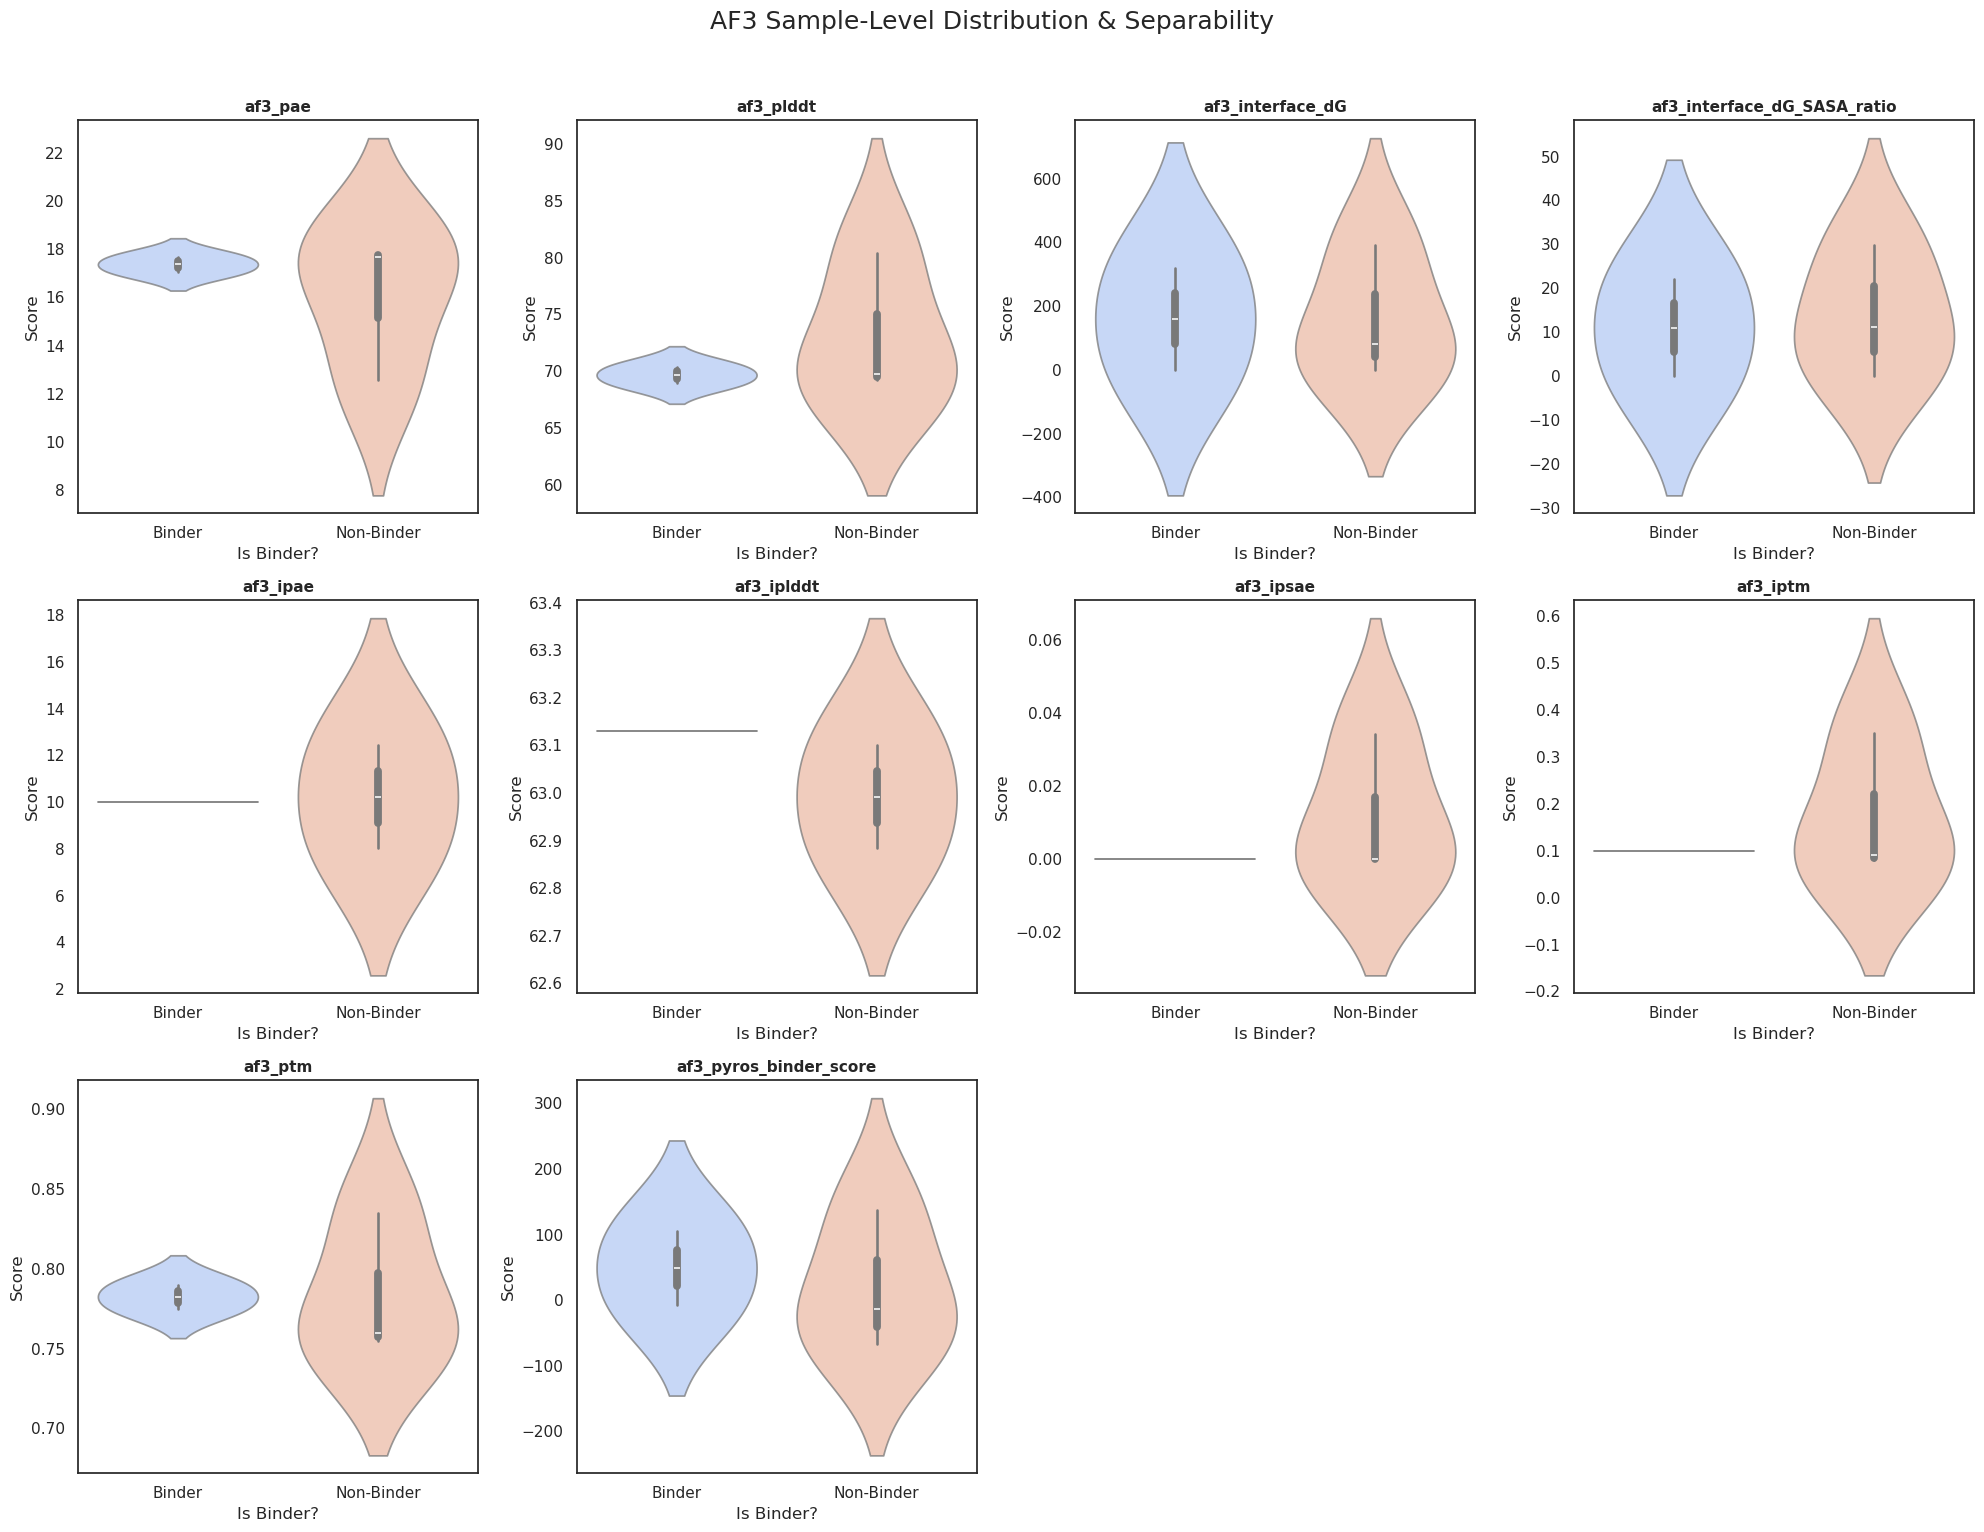

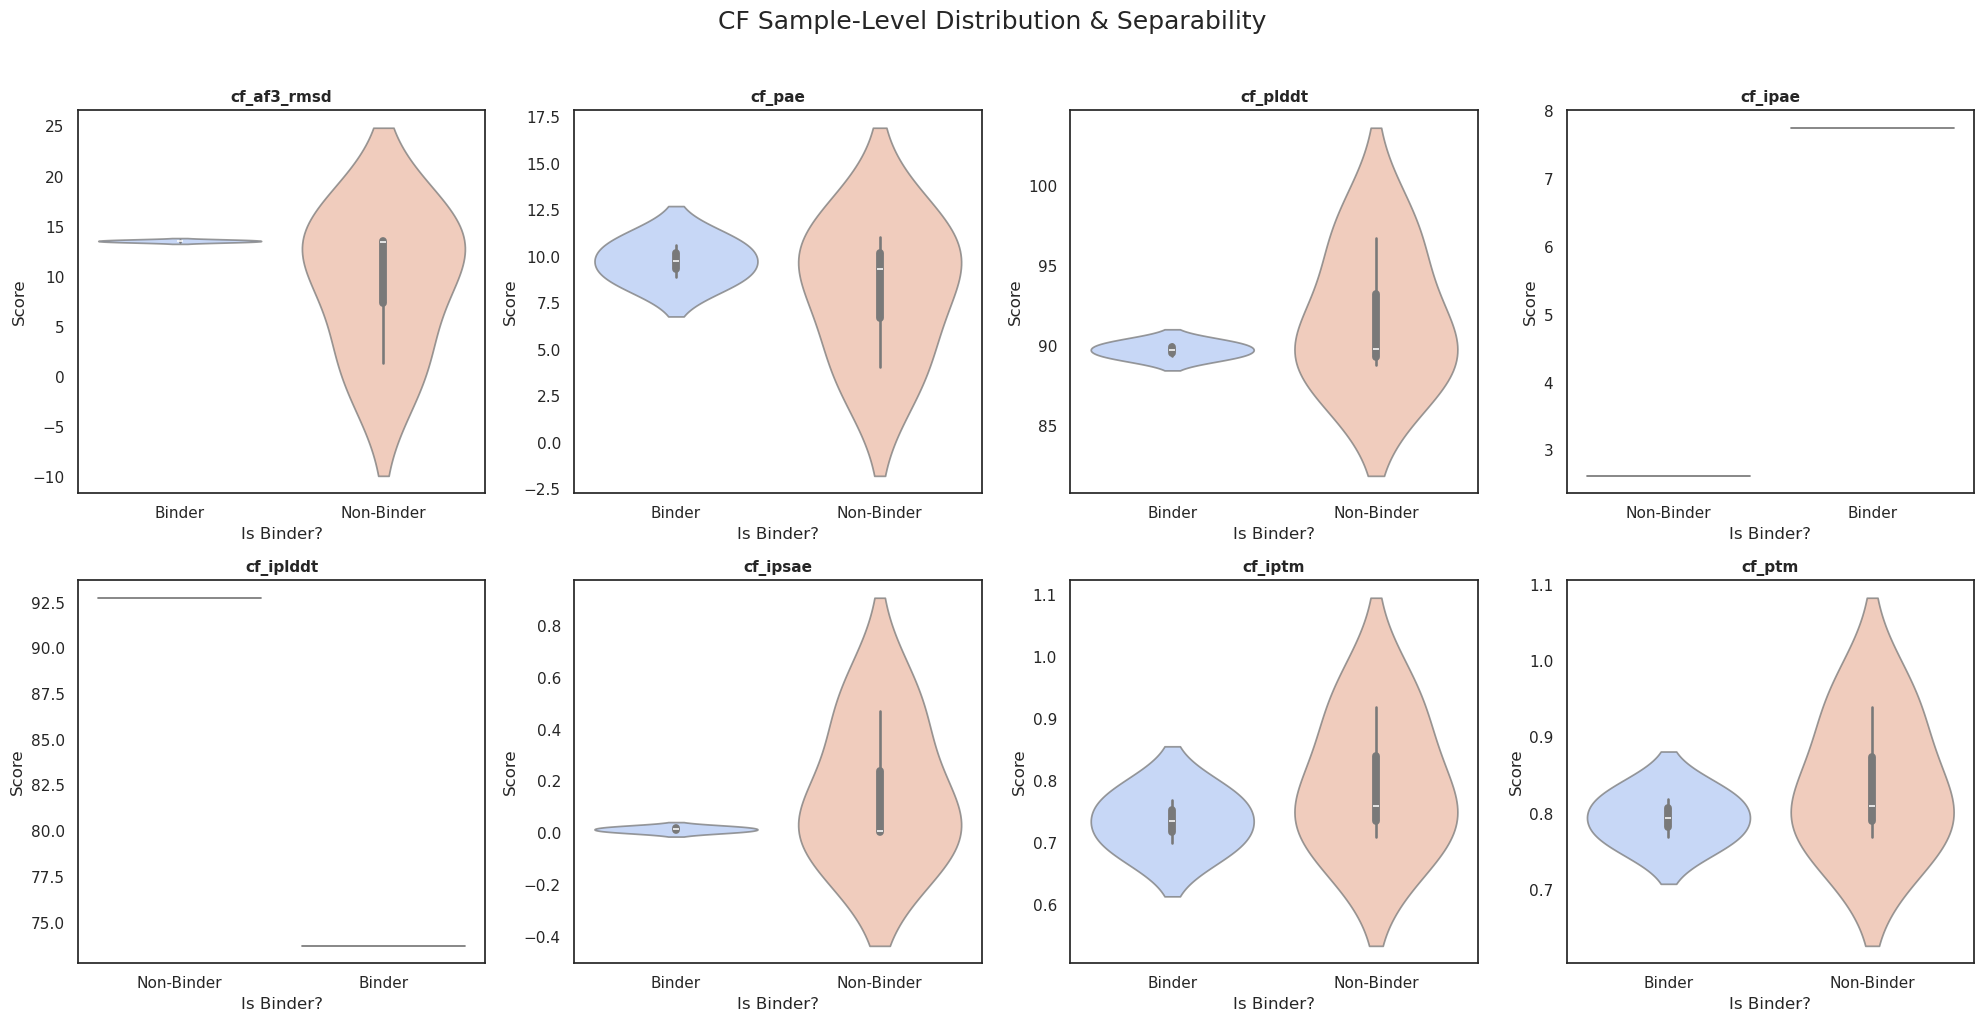

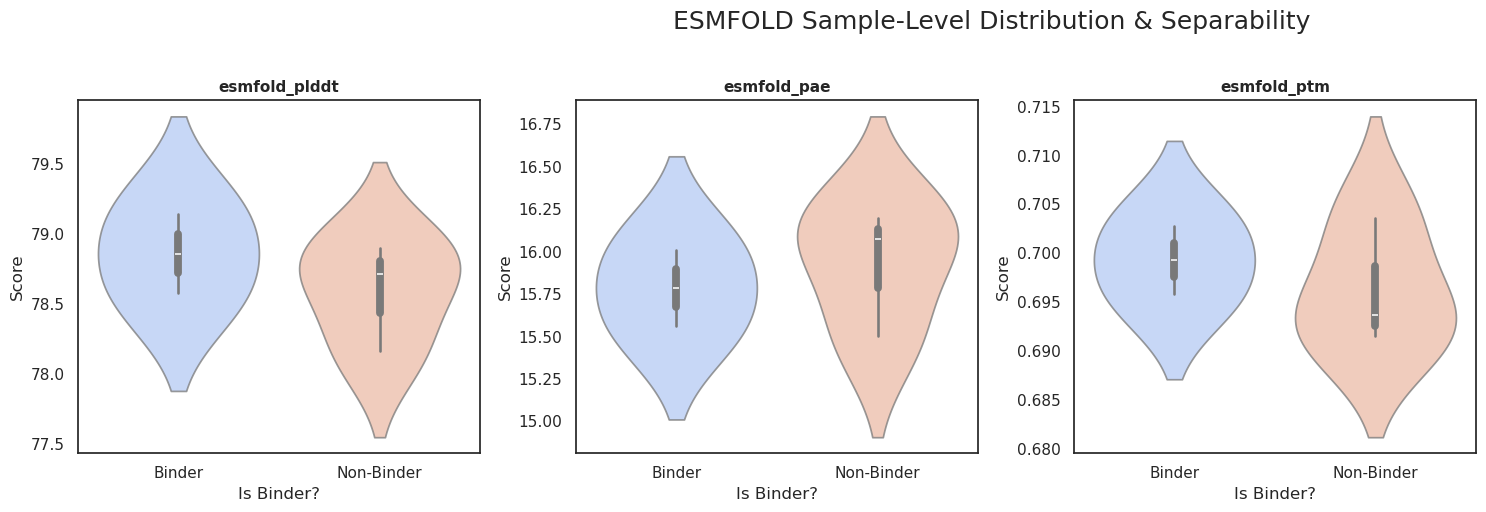

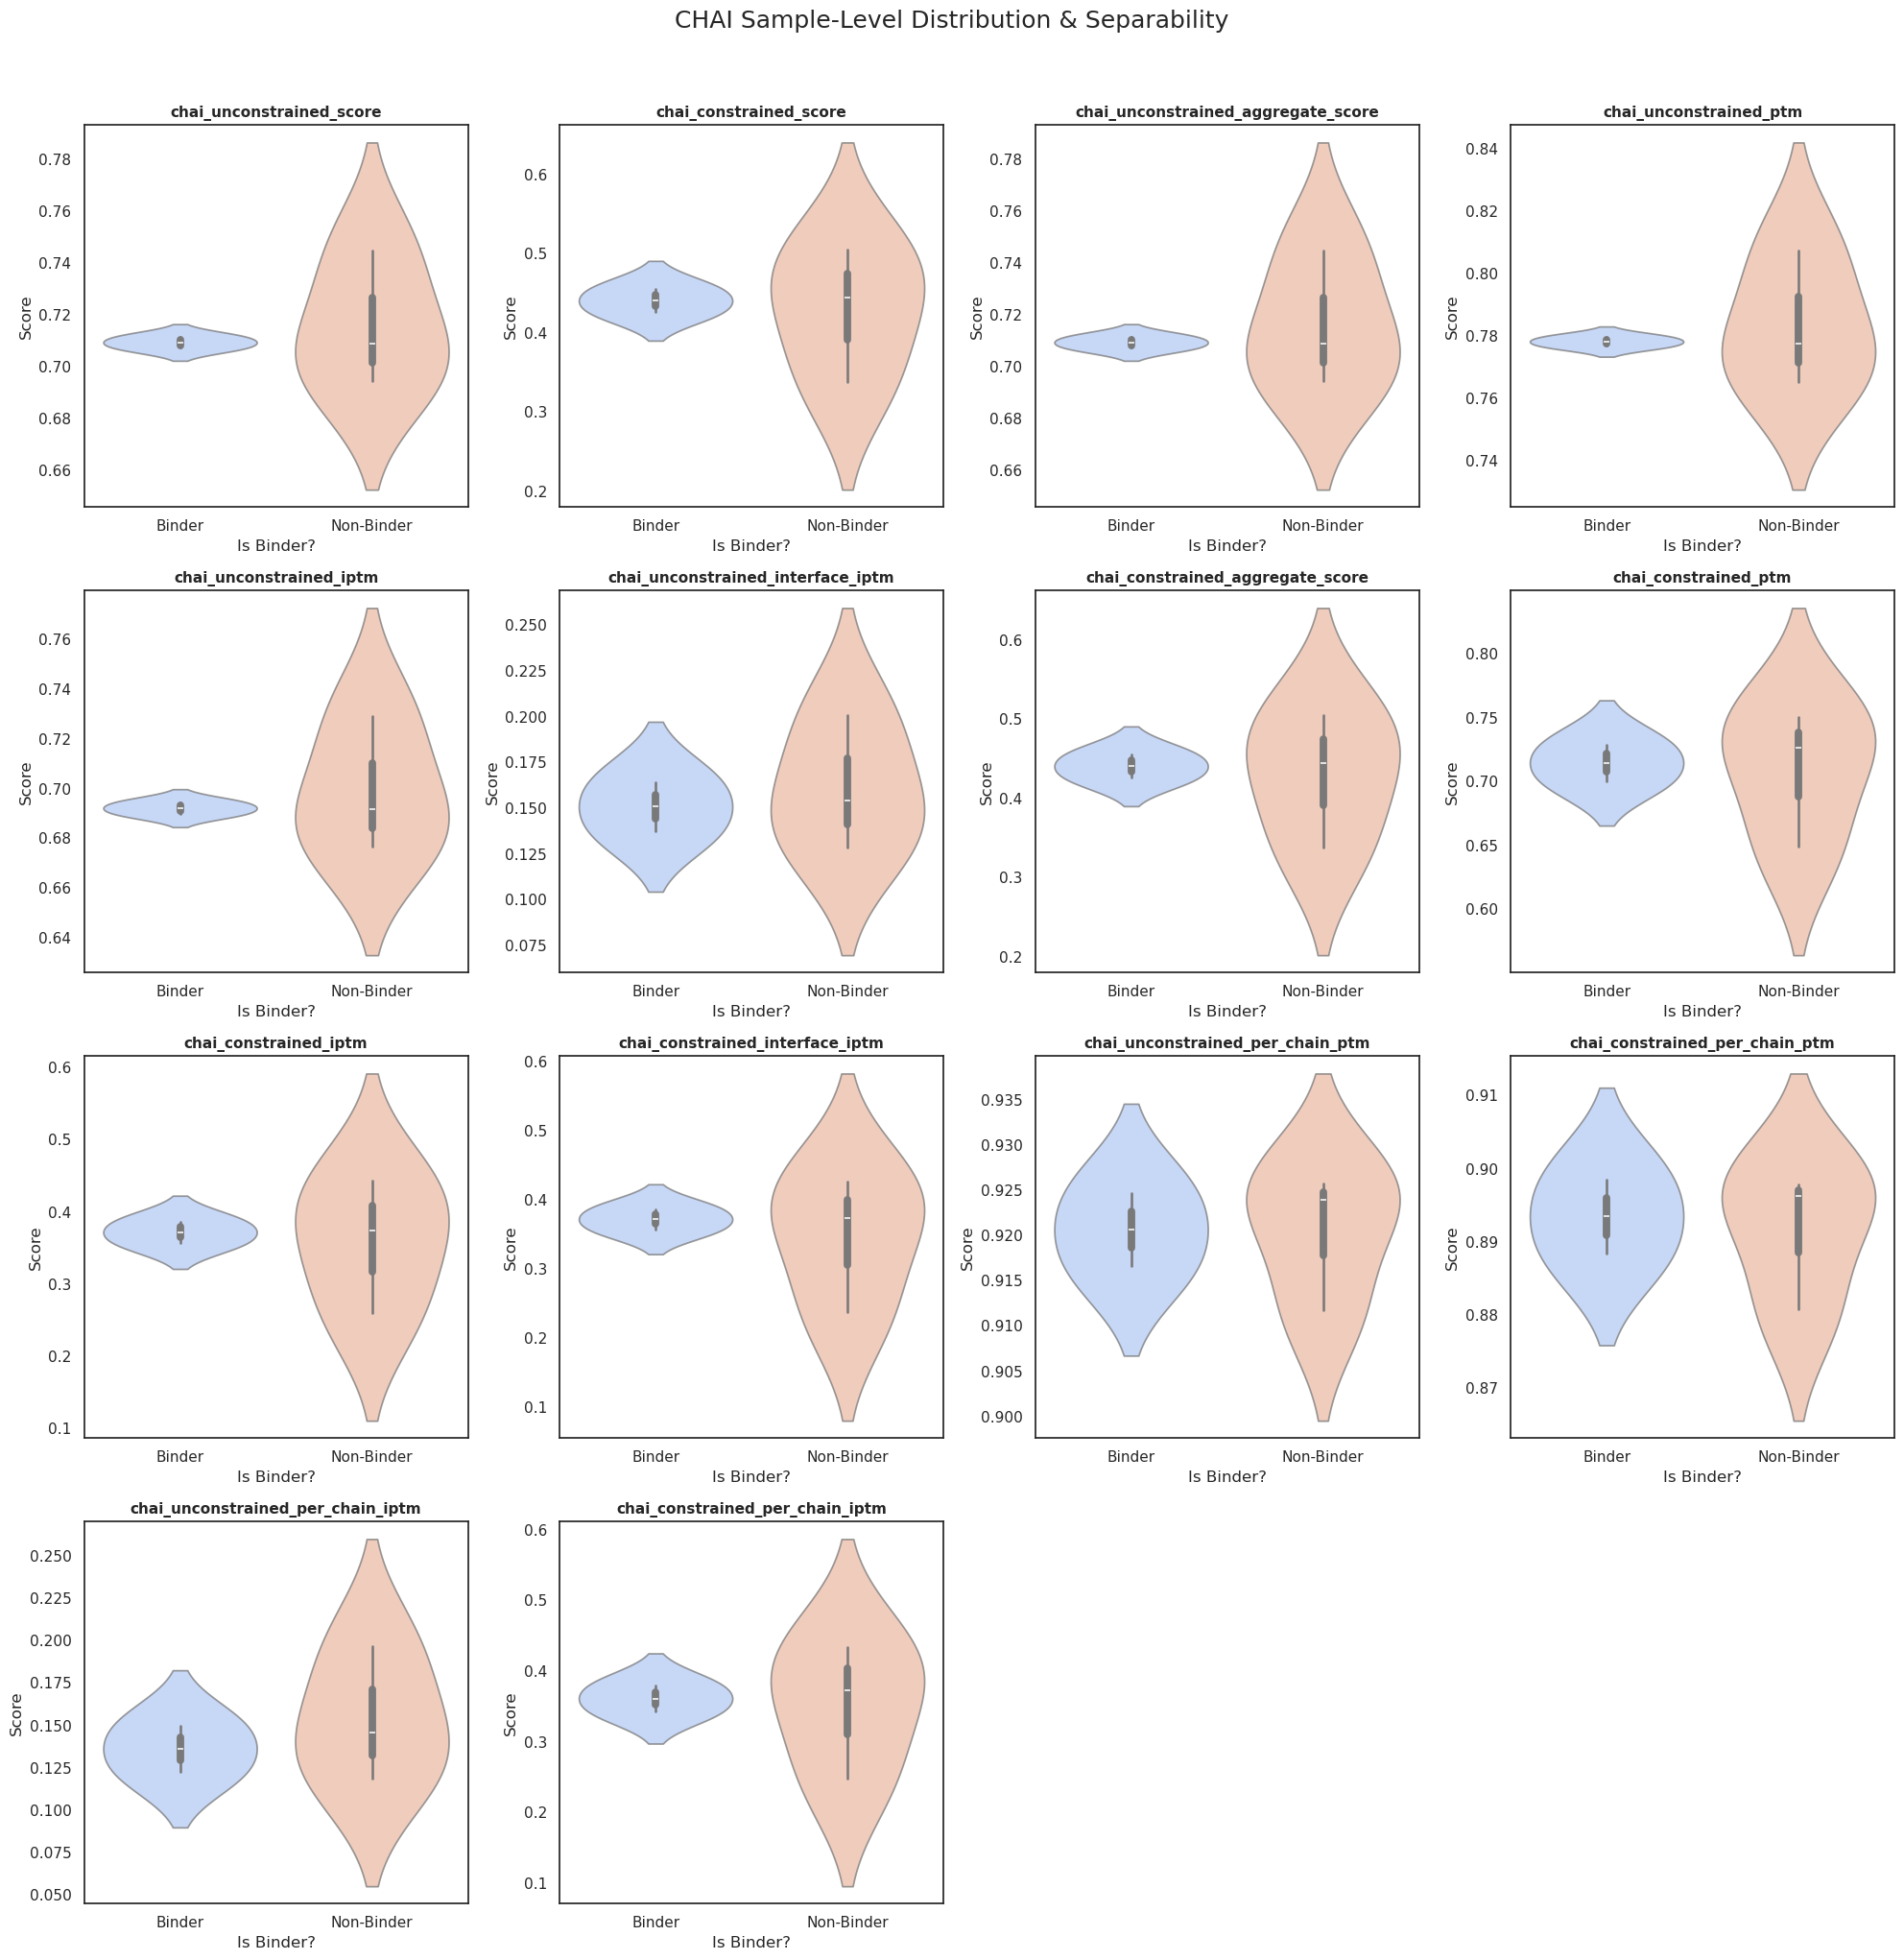

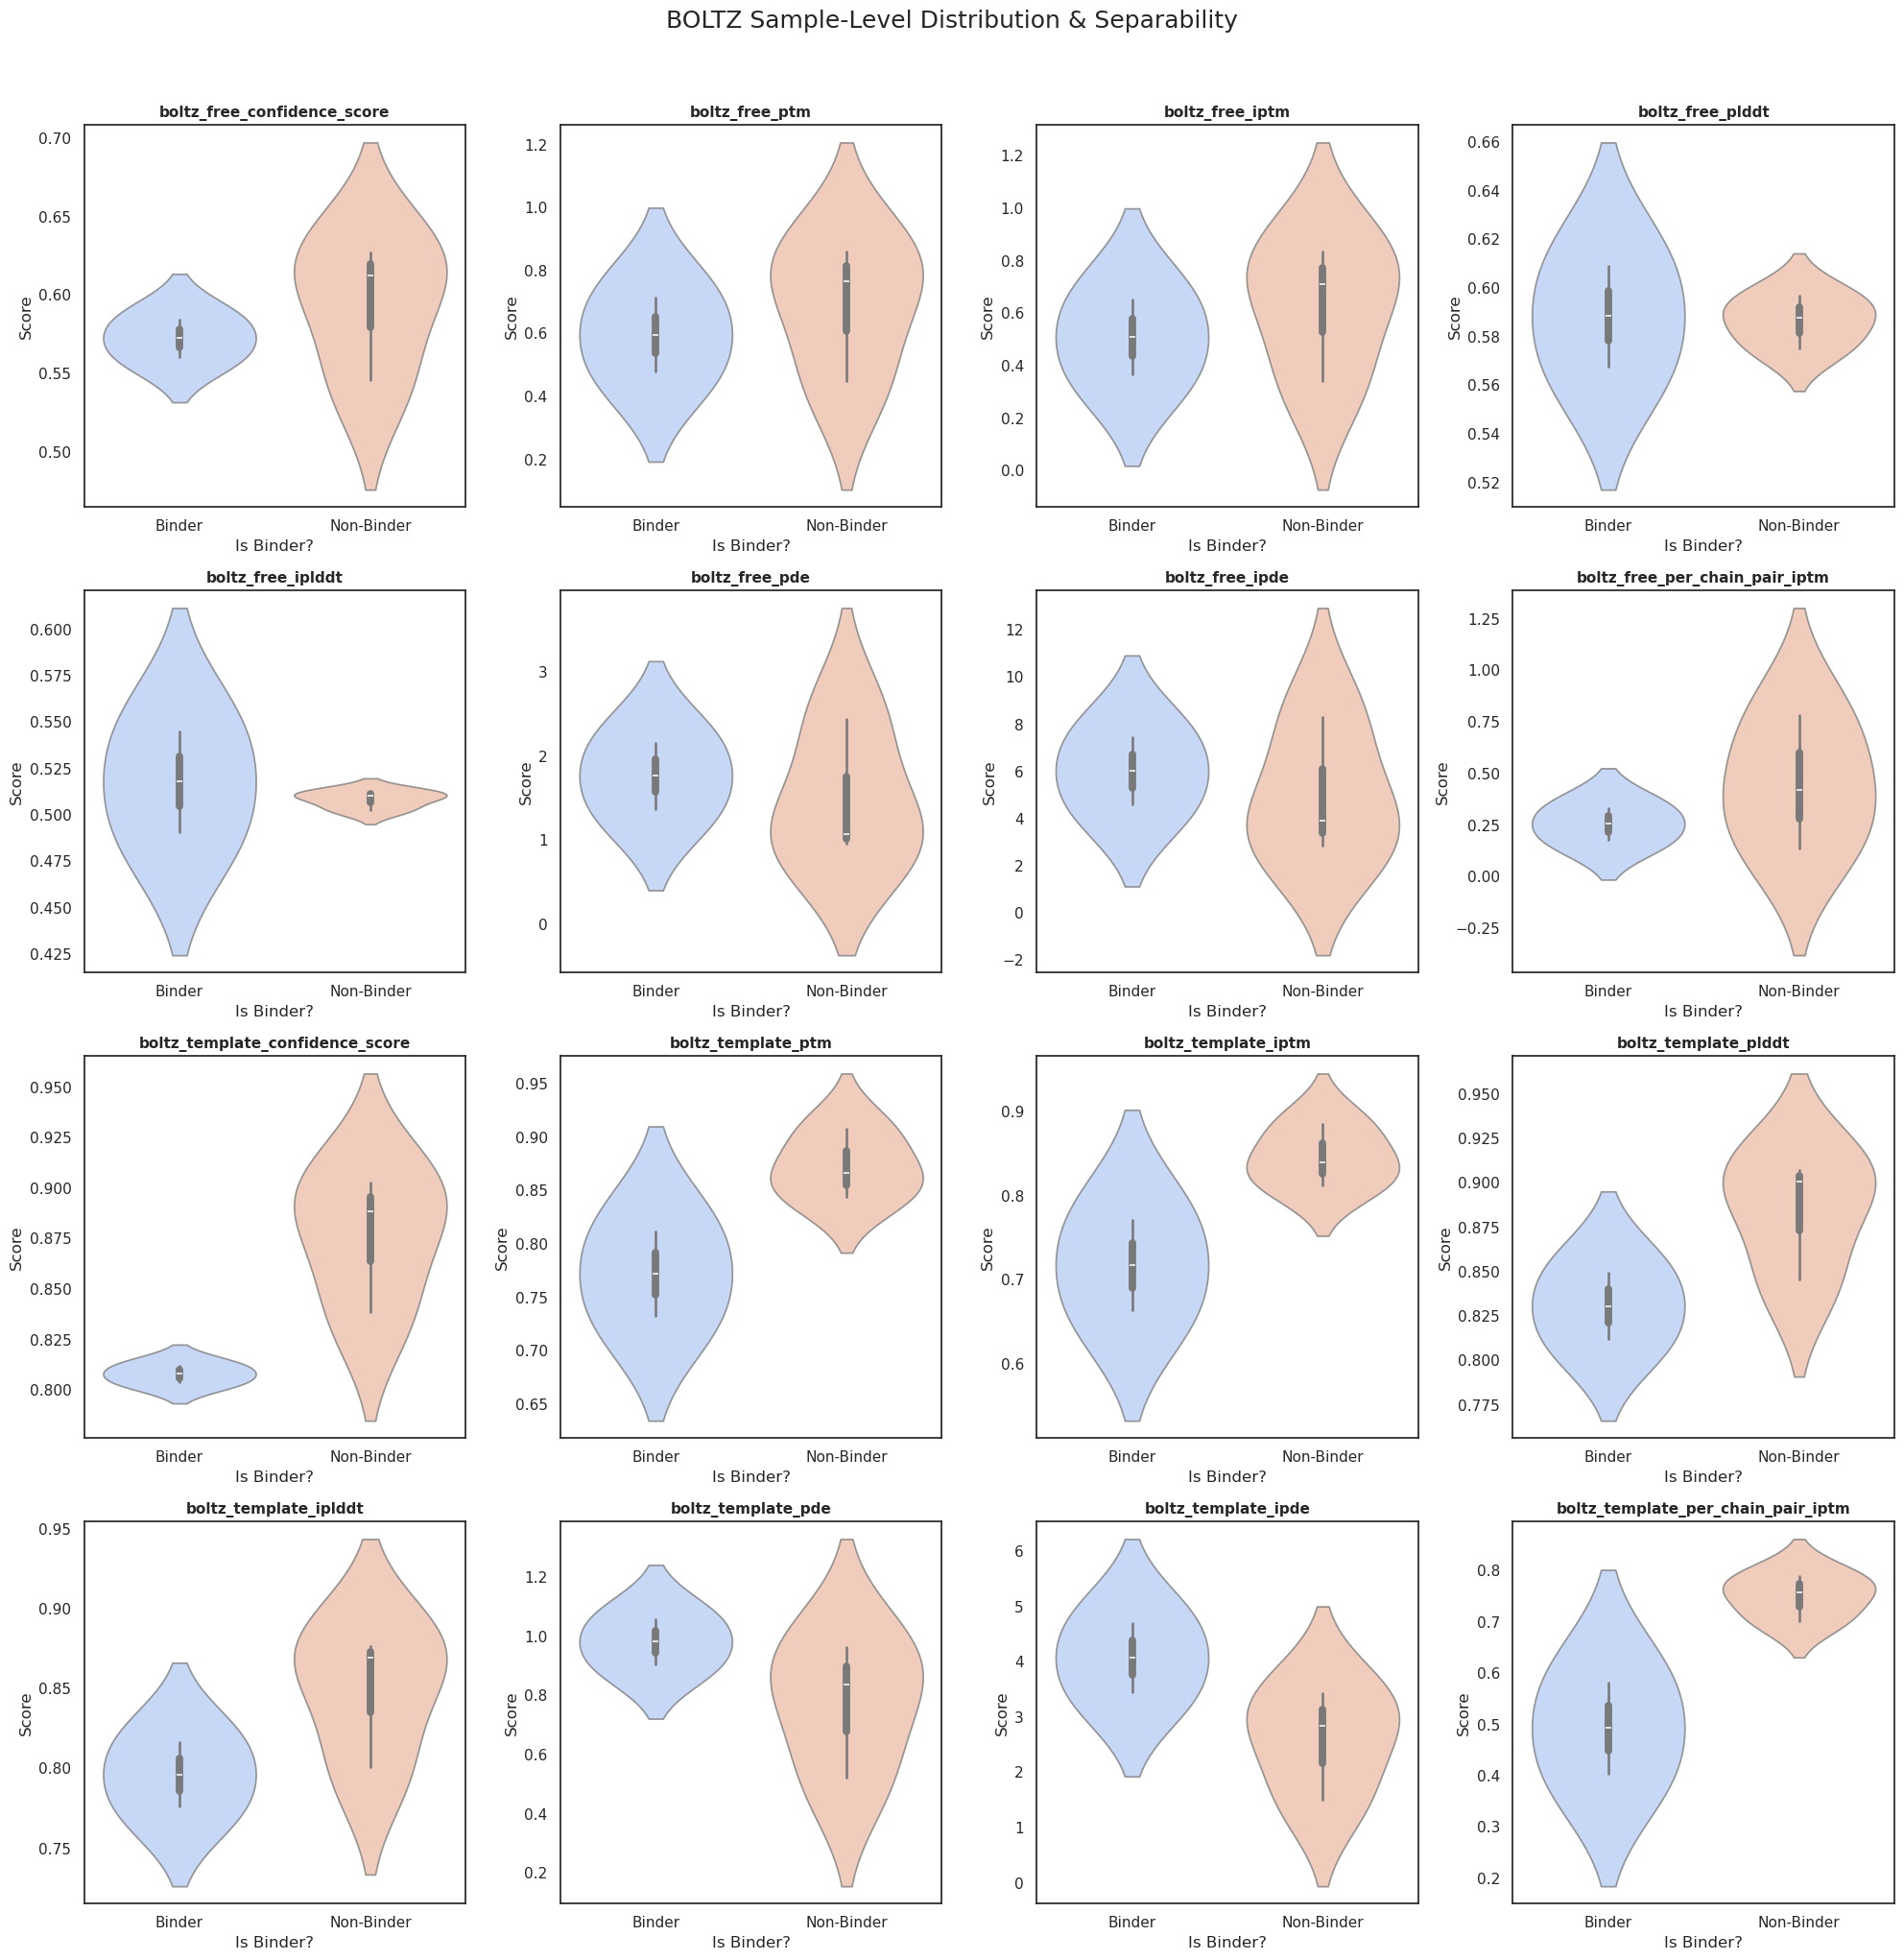

Finished generating scatterplots for BOLTZ group.


<Axes: xlabel='binder', ylabel='boltz_template_per_chain_pair_iptm'>

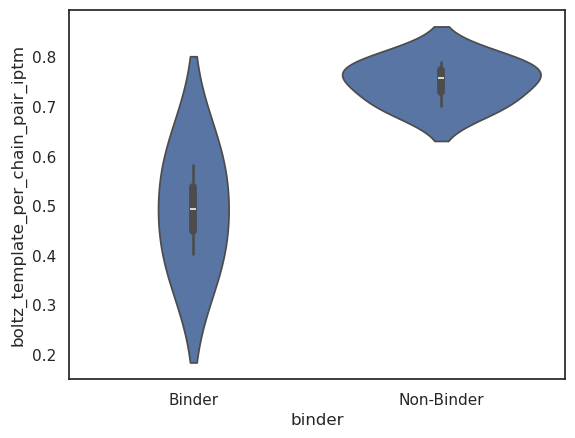

In [44]:
# Separability
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetics
sns.set_theme(style="white")

# Determine if we have multiple classes to compare
has_both_classes = scores_df_extended['binder'].nunique() > 1

for model, cols in model_groups.items():
    if not cols: continue
    
    # Filter out columns that are entirely NaN to prevent the "bxp length" error
    valid_cols = [c for c in cols if scores_df_extended[c].notna().any()]
    if not valid_cols:
        print(f"Skipping {model.upper()}: No valid numeric data found.")
        continue

    # Calculate grid size
    n_cols = 4
    n_rows = (len(valid_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 5 * n_rows))
    axes = np.atleast_1d(axes).flatten()
    
    for i, col in enumerate(valid_cols):
        ax = axes[i]
        
        # Clean the data slice for this specific metric
        plot_df = scores_df_extended.dropna(subset=[col]).copy()
        
        if plot_df.empty:
            continue

        sns.violinplot(
            data=plot_df, 
            x='binder', 
            y=col, 
            hue='binder' if has_both_classes else None, 
            dodge=False, 
            alpha=0.75,    
            palette='coolwarm' if has_both_classes else ["#4C72B0"],
            ax=ax,
            legend=False
        )

        
        ax.set_title(col, fontsize=11, fontweight='bold')
        ax.set_xlabel('Is Binder?')
        ax.set_ylabel('Score')

    # Remove empty subplots
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
        
    plt.suptitle(f"{model.upper()} Sample-Level Distribution & Separability", fontsize=18, y=1.02)
    plt.tight_layout()
    
    # Save output
    save_path = OUTPUT_DIR / f"{model}_separability_scatter.png"
    plt.savefig(save_path, dpi=200, bbox_inches='tight')
    plt.show() 
    
print(f"Finished generating scatterplots for {model.upper()} group.")
sns.violinplot(data=plot_df, x='binder', y=col)

#### Compute metrics (ROC-AUC, PR-AUC, F1 and Precision)

In [45]:
# read metric_directions.yaml

if Path(YAML_PATH).exists():
    with open(YAML_PATH, 'r') as f:
        yaml_data = yaml.safe_load(f)
    
    # Extract directions
    raw_directions = {k: v['direction'] for k, v in yaml_data['metrics'].items()}
    metric_directions = dict(sorted(raw_directions.items(), key=lambda x: len(x[0]), reverse=True))
    print(f"Loaded {len(metric_directions)} metric directions from YAML.")
else:
    print(f"WARNING: YAML not found at {YAML_PATH}. Using default direction (+1).")
    metric_directions = {}

def get_direction(col_name):
    for base_metric, direction in metric_directions.items():
        if base_metric in col_name: 
            return direction
    return 1

Loaded 58 metric directions from YAML.


In [53]:
# NOTE — normalization for ML (future):
#   Scale does not matter for ROC-AUC but will matter for ML models.
#   At that point use QuantileTransformer fit on training data only:
#       qt.fit(X_train[score_cols])
#       X_train_norm = qt.transform(X_train[score_cols])
#       X_test_norm  = qt.transform(X_test[score_cols])  # NOT fit_transform!



import numpy as np
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve, 
    auc as pr_auc, average_precision_score, f1_score
)

def calculate_all_metrics(df_data, numeric_cols):
    """
    Calculate comprehensive metrics for each predictor using domain knowledge from YAML.
    
    Uses get_direction() to determine metric direction from YAML file.
    
    Parameters:
    -----------
    df_data : DataFrame
        Data containing 'binder' column (target) and score columns
    numeric_cols : list
        List of metric column names to evaluate
    
    Returns:
    --------
    DataFrame with columns: metric, raw_roc, aligned_roc, pr_auc, f1, avg_precision, note
    """
    results = []
    
    for col in numeric_cols:
        # Skip if insufficient data
        if df_data[col].notna().sum() < 2 or df_data[col].nunique() < 2:
            continue
        
        try:
            # Clean data
            clean_data = df_data[[col, 'binder']].dropna()
            if clean_data['binder'].nunique() < 2:
                continue
            
            y_true = clean_data['binder'].astype(int)
            y_score_raw = clean_data[col].values
            

            # Step 1: Calculate Raw ROC-AUC
            raw_roc = roc_auc_score(y_true, y_score_raw)
            
            # Step 2: Get direction from YAML (domain knowledge)
            direction = get_direction(col)
            
            # Step 3: Align scores (Higher is always better)
            aligned_scores = y_score_raw * direction
            aligned_roc = max(raw_roc, 1 - raw_roc)
            
            # Step 4: Calculate PR-AUC (Average Precision)
            pr_auc = average_precision_score(y_true, aligned_scores)
            
            # Step 5: Calculate Max F1 Score
            fpr, tpr, thresholds = roc_curve(y_true, aligned_scores)
            j_scores = tpr - fpr
            best_threshold = thresholds[np.argmax(j_scores)]
            y_pred = (aligned_scores >= best_threshold).astype(int)
            max_f1 = f1_score(y_true, y_pred)
            
            # Step 6: Average Precision at optimal threshold
            precisions, recalls, thr = precision_recall_curve(y_true, aligned_scores)
            f1_scores = (2 * precisions * recalls) / (precisions + recalls + 1e-8)
            best_idx = np.argmax(f1_scores) # use data from best-performing iteration
            precision = precisions[best_idx]
            recall= recalls[best_idx]
            
            results.append({
                'metric': col,
                'raw_roc': round(raw_roc, 4),
                'aligned_roc': round(aligned_roc, 4),
                'pr_auc': round(pr_auc, 4),
                'f1': round(max_f1, 4),
                'precision': round(precision, 4),
                'recall': round(recall, 4),
                'opt_threshold': thr[best_idx] * direction,
                'direction': direction,
            })
        except Exception as e:
            continue
    
    # Create DataFrame and sort by PR-AUC
    results_df = pd.DataFrame(results).sort_values('pr_auc', ascending=False)
    return results_df


# Calculate metrics using domain knowledge from YAML
results = calculate_all_metrics(scores_df_extended, numeric_cols)
print(results.shape[0])
results.to_csv(OUTPUT_DIR / 'rankings.csv', index=False)

print("="*100)
print("Comprehensive metric evaluation based on domain knowledge")
print("="*100)
print(results.head(5).to_string(index=False))
print("\nSaved to: rankings.csv")

KeyError: 'pr_auc'

#### Visualizations

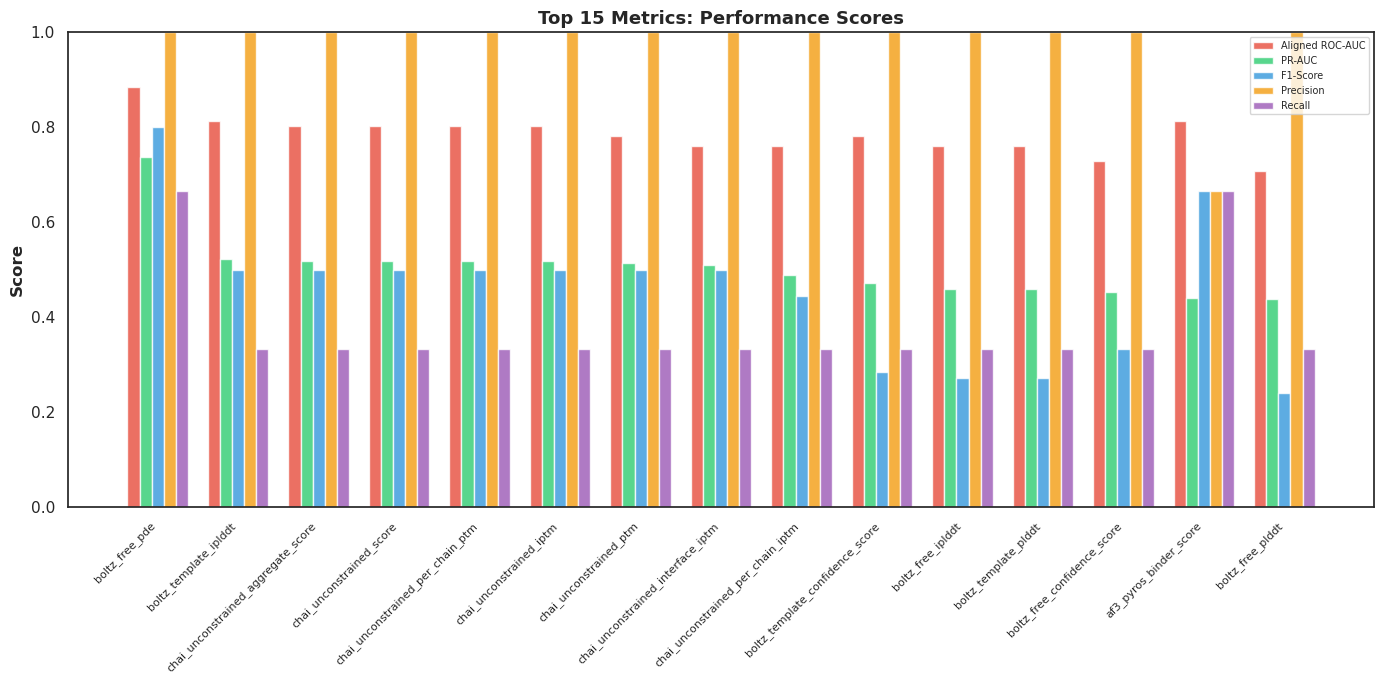

<Figure size 640x480 with 0 Axes>

In [32]:
# Visualization - Top 15 Metrics 
from sklearn.metrics import precision_recall_curve

fig, ax = plt.subplots(figsize=(14, 7))
top_15 = results.head(15)
x_pos = range(len(top_15))
width = 0.15

ax.bar([i - 2*width for i in x_pos], top_15['aligned_roc'], width, label='Aligned ROC-AUC', color='#e74c3c', alpha=0.8)
ax.bar([i - 1*width for i in x_pos], top_15['pr_auc'], width, label='PR-AUC', color='#2ecc71', alpha=0.8)
ax.bar([i + 0*width for i in x_pos], top_15['f1'], width, label='F1-Score', color='#3498db', alpha=0.8)
ax.bar([i + 1*width for i in x_pos], top_15['precision'], width, label='Precision', color='#f39c12', alpha=0.8)
ax.bar([i + 2*width for i in x_pos], top_15['recall'], width, label='Recall', color='#9b59b6', alpha=0.8  )

ax.set_ylabel('Score', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Metrics: Performance Scores', fontsize=13, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(top_15['metric'], rotation=45, ha='right', fontsize=8)
ax.legend(loc='upper right', fontsize=7)
ax.grid(False)
ax.set_ylim([0, 1])

plt.tight_layout()
plt.savefig('top15_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
plt.savefig(OUTPUT_DIR / 'top15_metrics.png', dpi=150, bbox_inches='tight')

35
6 6
boltz_free_pde: 35 samples, 6 curve points
Positives: 3.0, Negatives: 32
35
7 7
boltz_template_iplddt: 35 samples, 7 curve points
Positives: 3.0, Negatives: 32
35
7 7
chai_unconstrained_aggregate_score: 35 samples, 7 curve points
Positives: 3.0, Negatives: 32
35
7 7
chai_unconstrained_score: 35 samples, 7 curve points
Positives: 3.0, Negatives: 32
35
7 7
chai_unconstrained_per_chain_ptm: 35 samples, 7 curve points
Positives: 3.0, Negatives: 32
35
7 7
chai_unconstrained_iptm: 35 samples, 7 curve points
Positives: 3.0, Negatives: 32
35
7 7
chai_unconstrained_ptm: 35 samples, 7 curve points
Positives: 3.0, Negatives: 32
35
7 7
chai_unconstrained_interface_iptm: 35 samples, 7 curve points
Positives: 3.0, Negatives: 32
35
7 7
chai_unconstrained_per_chain_iptm: 35 samples, 7 curve points
Positives: 3.0, Negatives: 32
35
7 7
boltz_template_confidence_score: 35 samples, 7 curve points
Positives: 3.0, Negatives: 32
35
7 7
boltz_free_iplddt: 35 samples, 7 curve points
Positives: 3.0, Nega

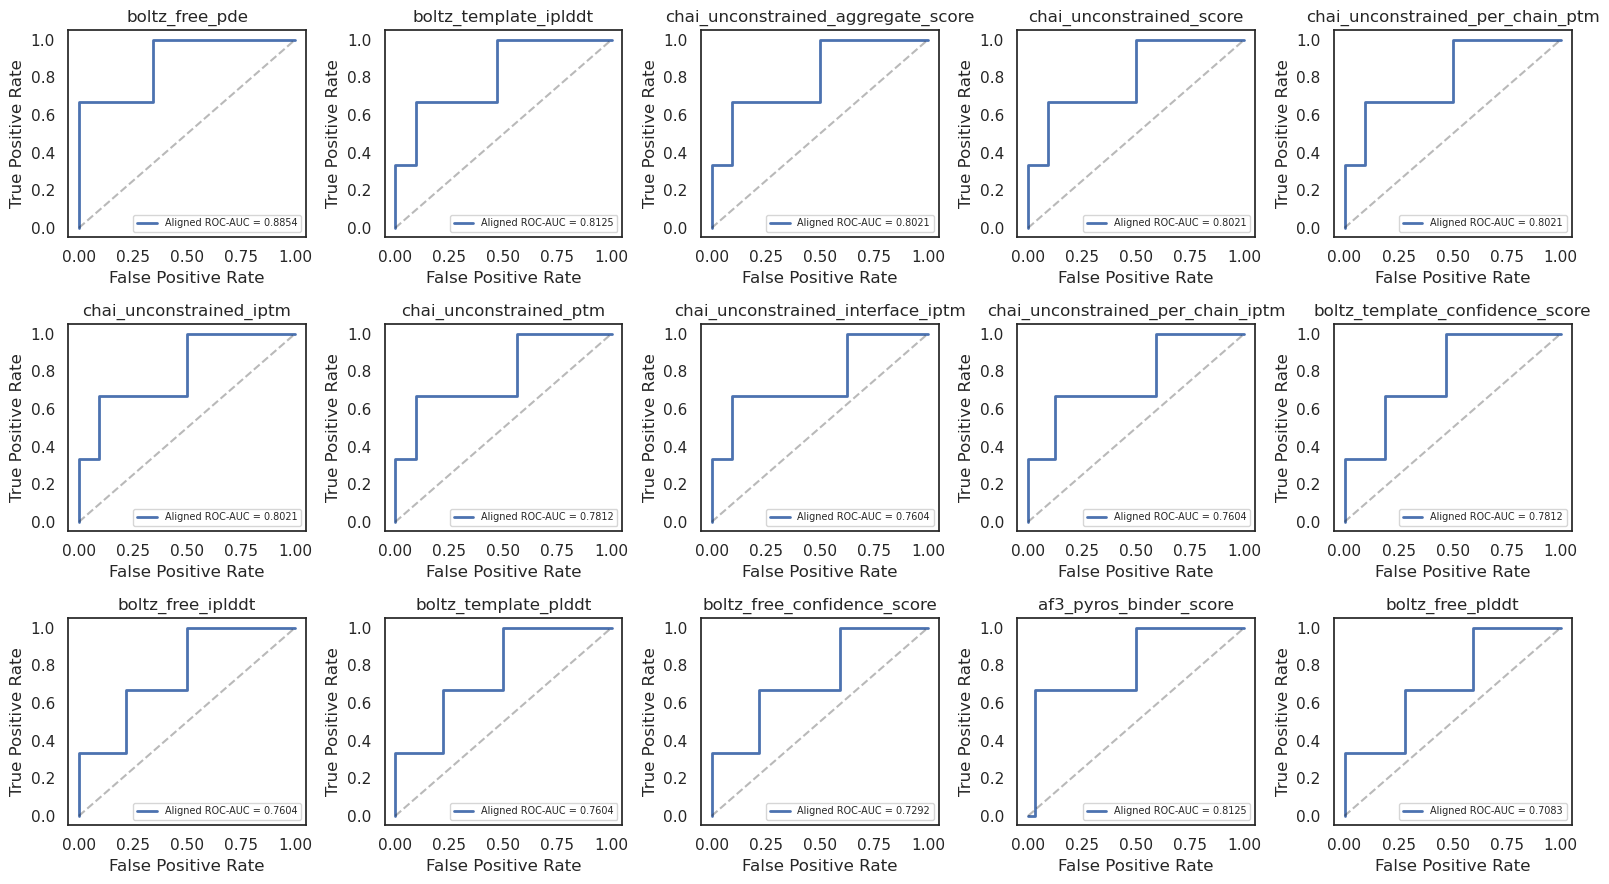

In [33]:
# plot roc-auc
from sklearn.metrics import roc_curve

fig, axes = plt.subplots(3, 5, figsize=(16, 9))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

top_15 = results.head(15)

for col_idx, (idx, row) in enumerate(top_15.iterrows()):
    ax = axes[col_idx]
    
    metric = row['metric']
    aligned_roc = row['aligned_roc']  # Use pre-calculated value
    direction = row['direction']
    
    # Get direction from results to align scores properly
    y_true = scores_df_extended['binder'].values
    clean_idx = scores_df_extended[metric].notna()
    y_score_raw = scores_df_extended.loc[clean_idx, metric].values * direction
    y_true_clean = y_true[clean_idx]
    print(y_true_clean.shape[0])
    
    fpr, tpr, _ = roc_curve(y_true_clean, y_score_raw)
    print(len(fpr), len(tpr))
    print(f"{metric}: {len(y_true_clean)} samples, {len(fpr)} curve points")
    print(f"Positives: {y_true_clean.sum()}, Negatives: {(y_true_clean == 0).sum()}")

    
    ax.plot(fpr, tpr, linewidth=2, label=f'Aligned ROC-AUC = {aligned_roc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{metric}')
    ax.legend(loc='lower right', fontsize=7)
    ax.grid(False)
    #ax.set_xlim([0, 1])
    #ax.set_ylim([0, 1])

#plt.suptitle('Top 10 ROC-AUC Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

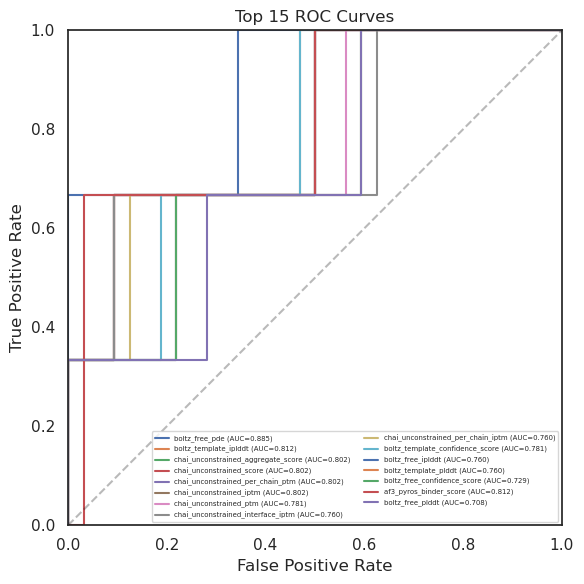

In [34]:
from sklearn.metrics import roc_curve

fig, ax = plt.subplots(figsize=(6, 6))

top_15 = results.head(15)

for _, row in top_15.iterrows():
    metric = row['metric']
    aligned_roc = row['aligned_roc']
    direction = row['direction']
    
    y_true = scores_df_extended['binder'].values
    clean_idx = scores_df_extended[metric].notna()
    
    y_score = scores_df_extended.loc[clean_idx, metric].values * direction
    y_true_clean = y_true[clean_idx]
    
    fpr, tpr, _ = roc_curve(y_true_clean, y_score)
    
    ax.plot(
        fpr, tpr,
        linewidth=1.5,
        label=f'{metric} (AUC={aligned_roc:.3f})'
    )

# diagonal reference
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)

ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Top 15 ROC Curves')

ax.legend(fontsize=5, loc='lower right', ncol=2)

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(False)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()

35
36 36
boltz_free_pde: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
boltz_template_iplddt: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
chai_unconstrained_aggregate_score: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
chai_unconstrained_score: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
chai_unconstrained_per_chain_ptm: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
chai_unconstrained_iptm: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
chai_unconstrained_ptm: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
chai_unconstrained_interface_iptm: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
chai_unconstrained_per_chain_iptm: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
boltz_template_confidence_score: 35 samples, 36 curve points
Positives: 3.0, Negatives: 32
35
36 36
boltz_free_iplddt: 35 samples, 36 

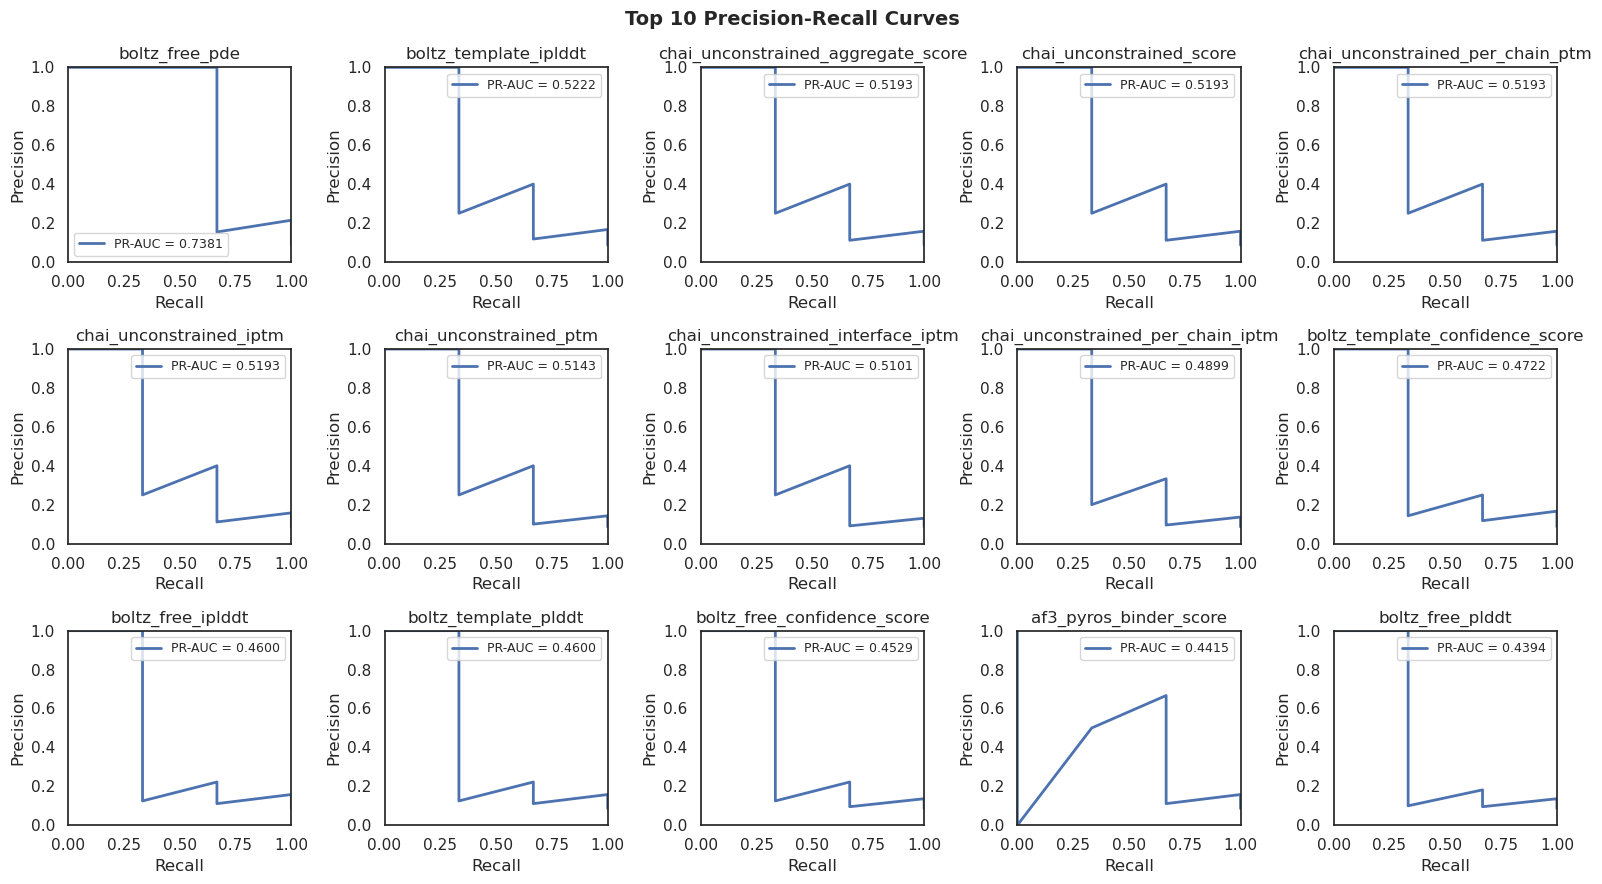

In [35]:
## Plot Precision-Recall Curves
from sklearn.metrics import precision_recall_curve

fig, axes = plt.subplots(3, 5, figsize=(16, 9))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

top_15 = results.head(15)

for col_idx, (idx, row) in enumerate(top_15.iterrows()): 
    ax = axes[col_idx]
    
    metric = row['metric']
    pr_auc_value = row['pr_auc']  # Use pre-calculated value
    direction = row['direction']
    
    # Get direction from results to align scores properly
    y_true = scores_df_extended['binder'].values
    clean_idx = scores_df_extended[metric].notna()
    y_score_aligned = scores_df_extended.loc[clean_idx, metric].values * direction
    y_true_clean = y_true[clean_idx]
    print(y_true_clean.shape[0])
    
    precision, recall, _ = precision_recall_curve(y_true_clean, y_score_aligned)
    print(len(precision), len(recall))
    print(f"{metric}: {len(y_true_clean)} samples, {len(precision)} curve points")
    print(f"Positives: {y_true_clean.sum()}, Negatives: {(y_true_clean == 0).sum()}")
    
    ax.plot(recall, precision, linewidth=2, label=f'PR-AUC = {pr_auc_value:.4f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{metric}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(False)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Top 10 Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


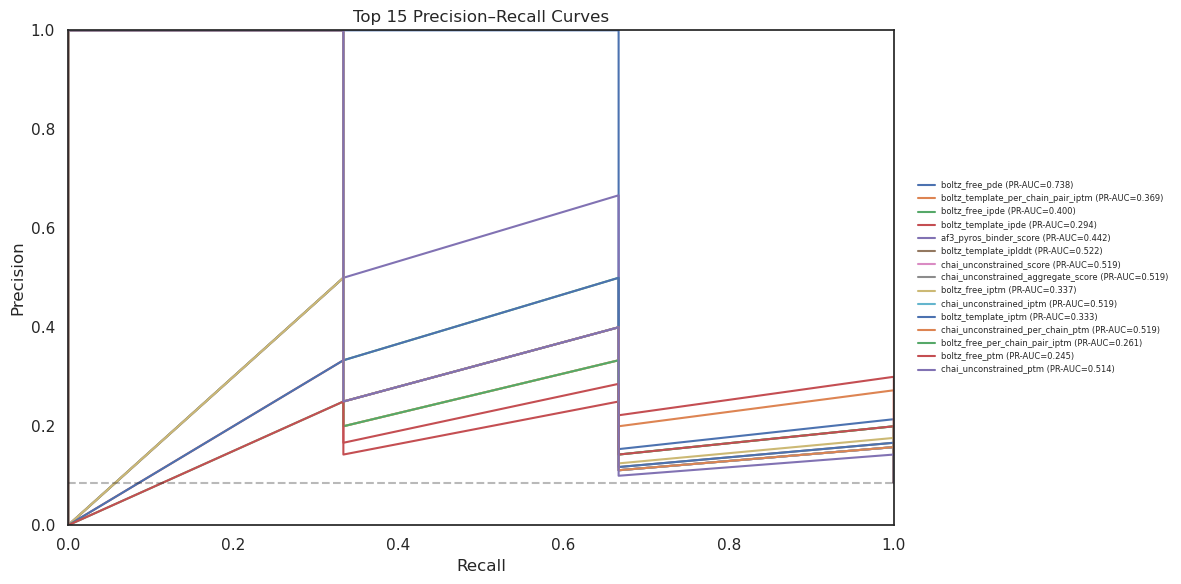

In [36]:
from sklearn.metrics import precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 6))

top_15 = results.sort_values('aligned_roc', ascending=False).head(15)

for i, (_, row) in enumerate(top_15.iterrows()):
    metric = row['metric']
    pr_auc_value = row['pr_auc']
    direction = row['direction']
    
    y_true = scores_df_extended['binder'].values
    clean_idx = scores_df_extended[metric].notna()
    
    y_score = scores_df_extended.loc[clean_idx, metric].values * direction
    y_true_clean = y_true[clean_idx]
    
    # skip invalid cases
    if len(np.unique(y_true_clean)) < 2:
        continue
    
    precision, recall, _ = precision_recall_curve(y_true_clean, y_score)

    
    ax.plot(
        recall,
        precision,
        label=f'{metric} (PR-AUC={pr_auc_value:.3f})'
    )

# baseline (positive class prevalence)
baseline = y_true.mean()
ax.hlines(baseline, 0, 1, colors='k', linestyles='--', alpha=0.3)

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Top 15 Precision–Recall Curves')

ax.set_xlim([0, 1])
ax.set_ylim([0, 1])
ax.grid(False)

# cleaner legend (outside)
ax.legend(
    fontsize=6,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'pr_curves_combined.png', dpi=150, bbox_inches='tight')
plt.show()


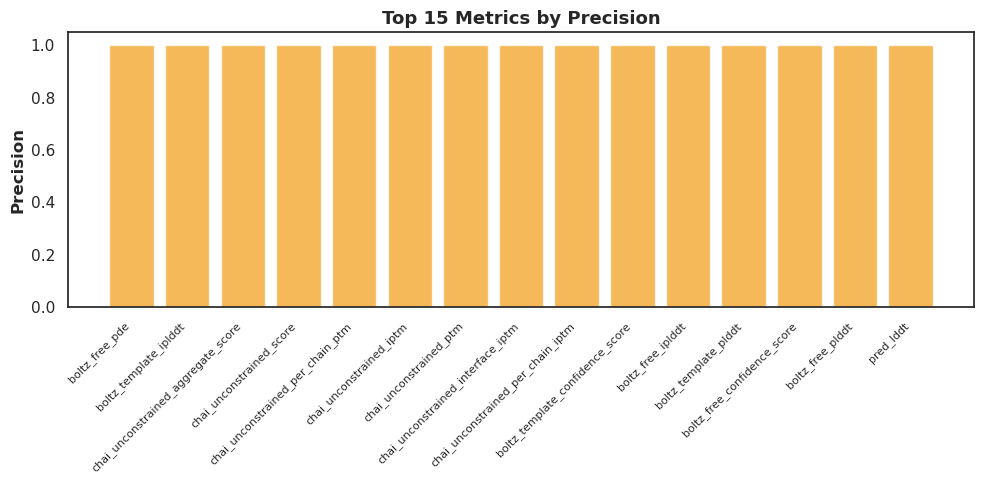

In [37]:
# rearrange rankings by precision
sorted_precision = results.sort_values('precision', ascending=False)   

# plot top15 precision
fig, ax = plt.subplots(figsize=(10, 5)) 
top_15_precision = sorted_precision.head(15)
ax.bar(top_15_precision['metric'], top_15_precision['precision'], color='#f39c12', alpha=0.7)
ax.set_ylabel('Precision', fontsize=12, fontweight='bold')
ax.set_title('Top 15 Metrics by Precision', fontsize=13, fontweight='bold')
ax.set_xticks(range(len(top_15_precision)))
ax.set_xticklabels(top_15_precision['metric'], rotation=45, ha='right', fontsize=8)
ax.grid(False)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'top15_precision.png', dpi=150, bbox_inches='tight')
plt.show()

    ROC-AUC  PR-AUC  F1-Score  Precision  Recall
37   0.8854  0.7381    0.8000     1.0000  0.6667
44   0.8125  0.5222    0.5000     1.0000  0.3333
25   0.8021  0.5193    0.5000     1.0000  0.3333
23   0.8021  0.5193    0.5000     1.0000  0.3333
48   0.8021  0.5193    0.5000     1.0000  0.3333
27   0.8021  0.5193    0.5000     1.0000  0.3333
26   0.7812  0.5143    0.5000     1.0000  0.3333
28   0.7604  0.5101    0.5000     1.0000  0.3333
50   0.7604  0.4899    0.4444     1.0000  0.3333
40   0.7812  0.4722    0.2857     1.0000  0.3333
36   0.7604  0.4600    0.2727     1.0000  0.3333
43   0.7604  0.4600    0.2727     1.0000  0.3333
32   0.7292  0.4529    0.3333     1.0000  0.3333
9    0.8125  0.4415    0.6667     0.6667  0.6667
35   0.7083  0.4394    0.2400     1.0000  0.3333
19   0.6875  0.4244    0.2308     1.0000  0.3333
38   0.8438  0.4000    0.3333     0.5000  0.6667
6    0.7500  0.3750    0.5714     0.5000  0.6667
47   0.8646  0.3687    0.4286     0.3333  0.6667
34   0.8021  0.3366 

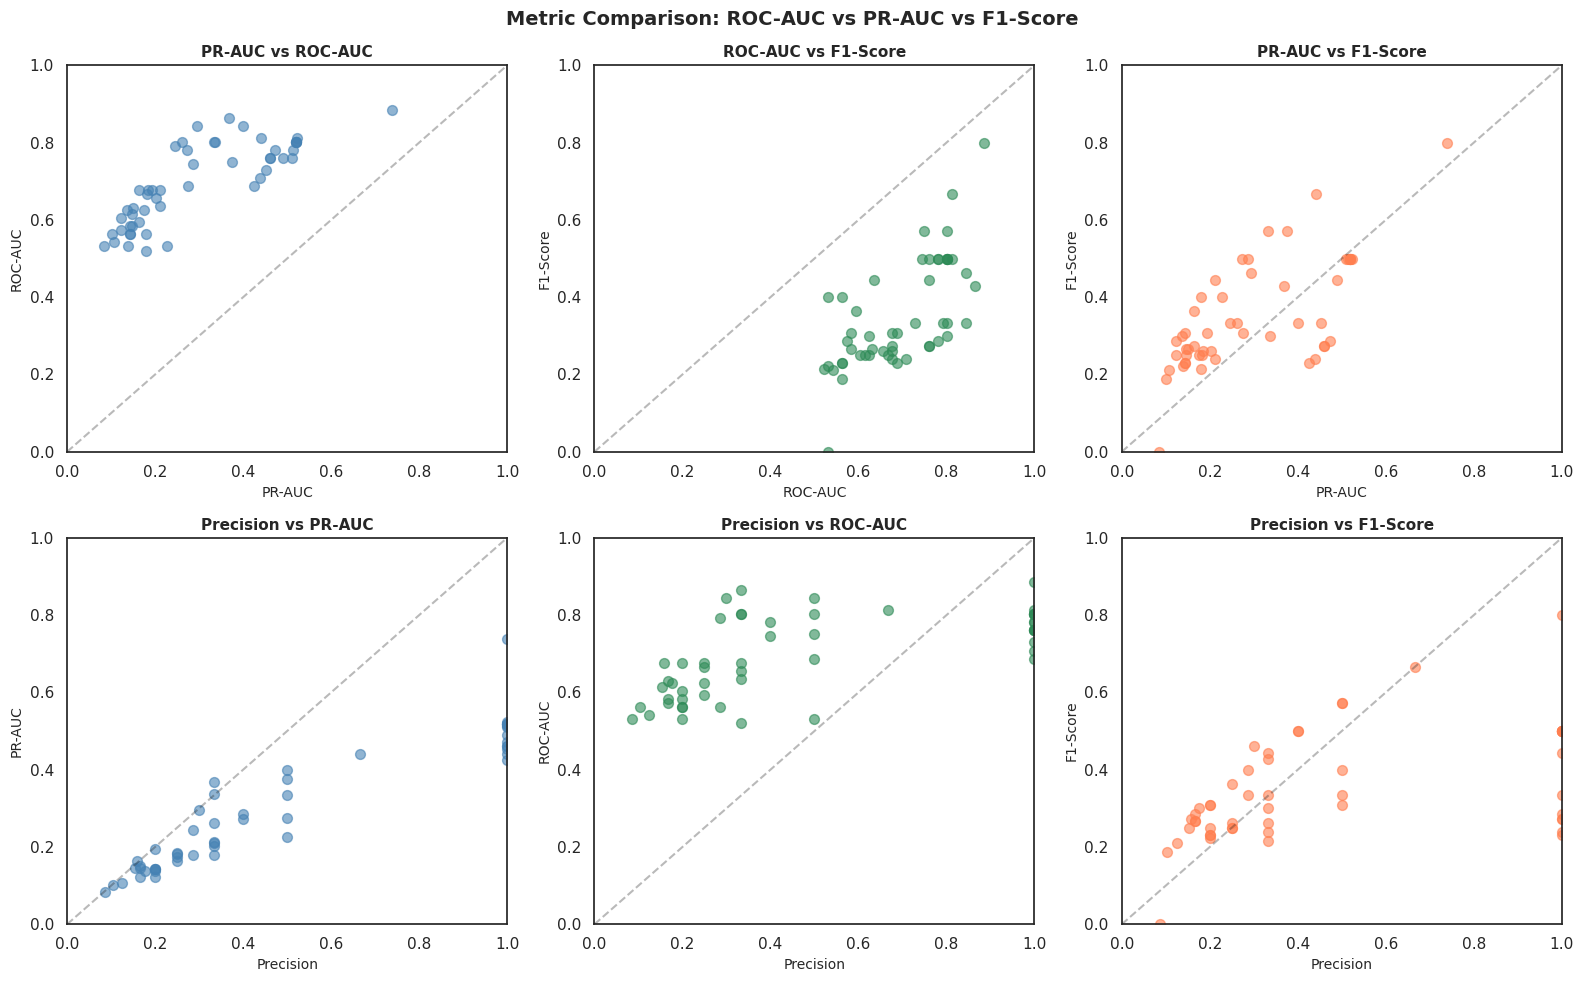

In [38]:
## Compare All Metrics: ROC-AUC, PR-AUC, and F1
sorted_precision = results.sort_values('precision', ascending=False)
sorted_f1 = results.sort_values('f1', ascending=False)
sorted_auc = results.sort_values('aligned_roc', ascending=False)
sorted_pr_auc = results.sort_values('pr_auc', ascending=False)
sorted_recall = results.sort_values('recall', ascending=False)

# Create comprehensive comparison dataframes
comparision = pd.DataFrame({
    'ROC-AUC': sorted_auc['aligned_roc'],
    'PR-AUC': sorted_pr_auc['pr_auc'],
    'F1-Score': sorted_f1['f1'],
    'Precision': sorted_precision['precision'],
    'Recall': sorted_recall['recall']
}).fillna(0).sort_values('PR-AUC', ascending=False)

print(comparision.to_string())


# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# ROC-AUC vs PR-AUC
ax = axes[0, 0]
ax.scatter(comparision['PR-AUC'], comparision['ROC-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=10)
ax.set_title('PR-AUC vs ROC-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# ROC-AUC vs F1
ax = axes[0, 1]
ax.scatter(comparision['ROC-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('ROC-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# PR-AUC vs F1
ax = axes[0, 2]
ax.scatter(comparision['PR-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('PR-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vs PR-AUC
ax = axes[1, 0]
ax.scatter(comparision['Precision'], comparision['PR-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('Precision vs PR-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vsROC-AUC 
ax = axes[1, 1]
ax.scatter(comparision['Precision'], comparision['ROC-AUC'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('ROC-AUC', fontsize=10)
ax.set_title('Precision vs ROC-AUC', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Precision vs F1
ax = axes[1, 2]
ax.scatter(comparision['Precision'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precision', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('Precision vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(False)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])



plt.suptitle('Metric Comparison: ROC-AUC vs PR-AUC vs F1-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'metrics_comparison_combined.png', dpi=150, bbox_inches='tight')
plt.show()

#### Quadrant plots

                                metric  raw_roc  aligned_roc  pr_auc      f1  \
37                      boltz_free_pde   0.1146       0.8854  0.7381  0.8000   
44               boltz_template_iplddt   0.8125       0.8125  0.5222  0.5000   
25  chai_unconstrained_aggregate_score   0.8021       0.8021  0.5193  0.5000   
23            chai_unconstrained_score   0.8021       0.8021  0.5193  0.5000   
48    chai_unconstrained_per_chain_ptm   0.8021       0.8021  0.5193  0.5000   
27             chai_unconstrained_iptm   0.8021       0.8021  0.5193  0.5000   
26              chai_unconstrained_ptm   0.7812       0.7812  0.5143  0.5000   
28   chai_unconstrained_interface_iptm   0.7604       0.7604  0.5101  0.5000   
50   chai_unconstrained_per_chain_iptm   0.7604       0.7604  0.4899  0.4444   
40     boltz_template_confidence_score   0.7812       0.7812  0.4722  0.2857   
36                   boltz_free_iplddt   0.7604       0.7604  0.4600  0.2727   
43                boltz_template_plddt  

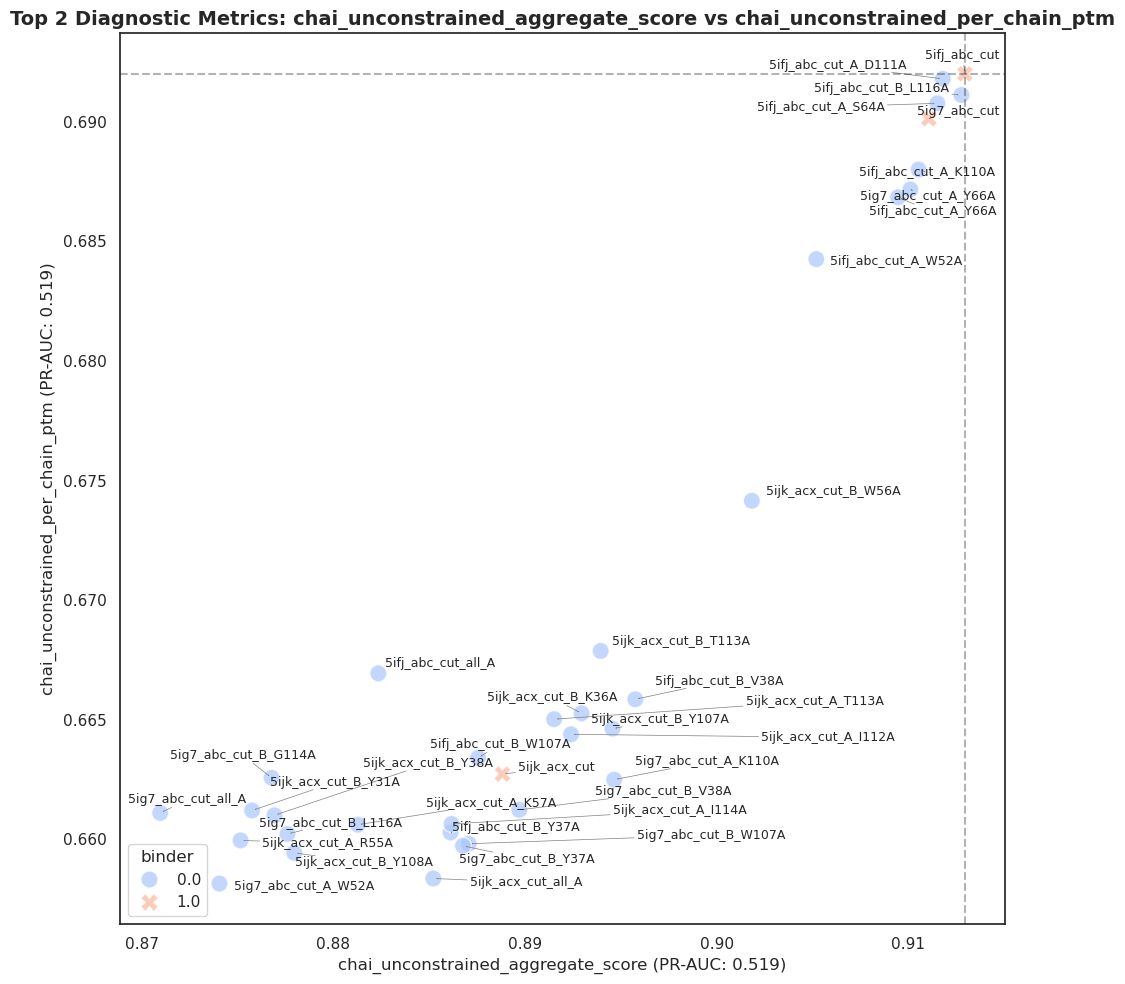

In [39]:
# Ranking and Final Visualization 
from adjustText import adjust_text

def plot_top_quadrant(df, results, label_all=True):
    # 1. Get Top 2 by PR-AUC
    top_15 = results.sort_values(by='pr_auc', ascending=False).head(15)
    if len(top_15) < 2: return
    print(top_15)
    
    m1_info, m2_info = top_15.iloc[2], top_15.iloc[4]
    
    m1, t1, d1 = m1_info['metric'], m1_info['opt_threshold'], m1_info['direction']
    m2, t2, d2 = m2_info['metric'], m2_info['opt_threshold'], m2_info['direction']

    # 2. Setup Plot
    plt.figure(figsize=(10, 10))
    plot_df = df.dropna(subset=[m1, m2]).copy()
    
    sns.scatterplot(
        data=plot_df, x=m1, y=m2, hue='binder', style='binder', 
        s=150, alpha=0.7, palette='coolwarm'
    )
    
    plt.axvline(t1, color='black', linestyle='--', alpha=0.3)
    plt.axhline(t2, color='black', linestyle='--', alpha=0.3)
    
    # 3. Dynamic Labels
    texts = []
    for i, row in plot_df.iterrows():
        # Check if prediction is an error
        is_correct1 = ((row[m1] * d1) >= (t1 * d1)) == row['binder']
        is_correct2 = ((row[m2] * d2) >= (t2 * d2)) == row['binder']
        
        if label_all or not (is_correct1 and is_correct2):
            label = str(row['sample'])
            texts.append(plt.text(row[m1], row[m2], label, fontsize=9))

    if texts:
        adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5))

    plt.title(f"Top 2 Diagnostic Metrics: {m1} vs {m2}", fontsize=14, fontweight='bold')
    plt.xlabel(f"{m1} (PR-AUC: {m1_info['pr_auc']:.3f})")
    plt.ylabel(f"{m2} (PR-AUC: {m2_info['pr_auc']:.3f})")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "top_metrics_quadrant.png", dpi=300)
    plt.show()


plot_top_quadrant(scores_df_extended, results, label_all=True)

### archiv


#### ROC AUC

A receiver operating characteristic curve, or ROC curve, is a graphical plot that illustrates the performance of a binary classifier model (although it can be generalized to multiple classes) at varying threshold values.
The ROC curve is the plot of the true positive rate (TPR) against the false positive rate (FPR) at each threshold setting.
   - Less sensitive to class imbalance
   - Can be misleadingly high even with poor minority class performance
   - Still useful for overall ranking but don't rely solely on it

In [40]:
# Calculate ROC-AUC 
# TO DO: implement directionality
auc_scores = {}
for col in numeric_cols:
    # Skip if column has NaN values or doesn't have enough variation
    if scores_df_extended[col].notna().sum() < 1 or scores_df_extended[col].nunique() < 1:
        continue
    try:
        auc = roc_auc_score(scores_df_extended["binder"], scores_df_extended[col])
        auc_scores[col] = auc
    except:
        pass

# Sort by AUC score (descending)
sorted_auc = dict(sorted(auc_scores.items(), key=lambda x: x[1], reverse=True))


# Display as DataFrames for better visualization
print("="*60)
print("ROC AUC Scores (sorted by performance)")
print("="*60)

auc_df = pd.DataFrame(list(sorted_auc.items()), columns=['Metric', 'ROC AUC'])
auc_df = auc_df.set_index('Metric')
print(auc_df.to_string())
print(f"\nBest metric: {list(sorted_auc.keys())[0]} (AUC: {list(sorted_auc.values())[0]:.4f})")

ROC AUC Scores (sorted by performance)
                                     ROC AUC
Metric                                      
boltz_template_per_chain_pair_iptm  0.864583
boltz_template_iplddt               0.812500
chai_unconstrained_score            0.802083
chai_unconstrained_aggregate_score  0.802083
chai_unconstrained_iptm             0.802083
boltz_free_iptm                     0.802083
boltz_free_per_chain_pair_iptm      0.802083
boltz_template_iptm                 0.802083
chai_unconstrained_per_chain_ptm    0.802083
boltz_free_ptm                      0.791667
chai_unconstrained_ptm              0.781250
boltz_template_confidence_score     0.781250
boltz_template_ptm                  0.781250
chai_unconstrained_per_chain_iptm   0.760417
chai_unconstrained_interface_iptm   0.760417
boltz_free_iplddt                   0.760417
boltz_template_plddt                0.760417
af3_ipsae                           0.750000
af3_iptm                            0.744792
boltz_free_confi

In [41]:
auc_df

,ROC AUC
Metric,
boltz_template_per_chain_pair_iptm,0.864583
boltz_template_iplddt,0.812500
chai_unconstrained_score,0.802083
chai_unconstrained_aggregate_score,0.802083
chai_unconstrained_iptm,0.802083
boltz_free_iptm,0.802083
boltz_free_per_chain_pair_iptm,0.802083
boltz_template_iptm,0.802083
chai_unconstrained_per_chain_ptm,0.802083


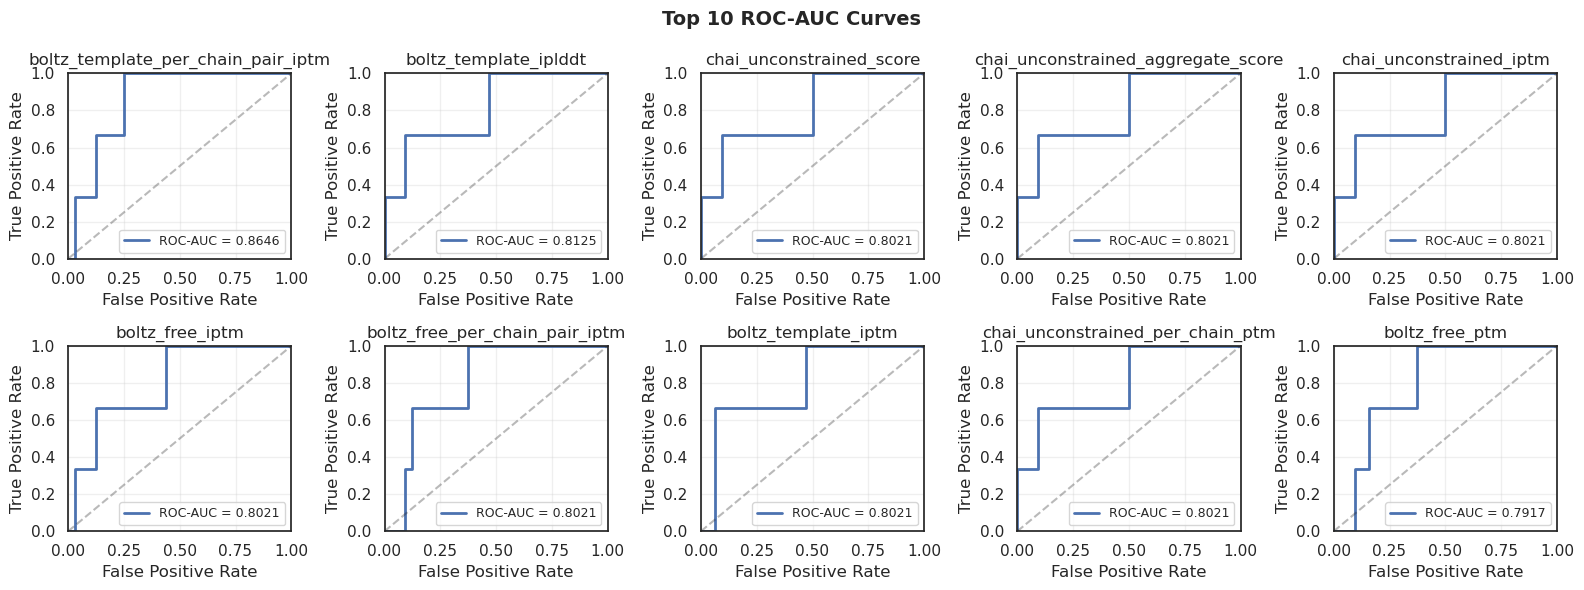

In [42]:
# plot roc-auc
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

top_10 = auc_df.head(10)

for col_idx, metric in enumerate(top_10.index):  # Iterate over index (metric names)
    ax = axes[col_idx]
    
    fpr, tpr, _ = roc_curve(scores_df_extended["binder"], scores_df_extended[metric])
    roc_auc = auc(fpr, tpr)
    
    ax.plot(fpr, tpr, linewidth=2, label=f'ROC-AUC = {roc_auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'{metric}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Top 10 ROC-AUC Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

#### precision recall
   - Focuses on minority class (binders)
   - More informative than ROC-AUC for imbalanced data
   - Recall = TP / (TP + FN): what fraction of binders we find
   - Precision = TP / (TP + FP): what fraction of predictions are correct

In [43]:
from sklearn.metrics import precision_recall_curve, auc as auc_pr

# Calculate Precision-Recall AUC for A,C and B,C
print("="*60)
print("Precision-Recall AUC Scores")
print("="*60)

pr_auc = {}
for col in numeric_cols:
    if scores_df_extended[col].notna().sum() < 2 or scores_df_extended[col].nunique() < 2:
        continue
    try:
        precision, recall, _ = precision_recall_curve(scores_df_extended["binder"], scores_df_extended[col])
        pr_auc_score = auc_pr(recall, precision)
        pr_auc[col] = pr_auc_score
    except:
        pass

sorted_pr_auc = dict(sorted(pr_auc.items(), key=lambda x: x[1], reverse=True))


# Display as DataFrames for better visualization
print("="*60)
print("ROC AUC Scores (sorted by performance)")
print("="*60)

pr_auc_df = pd.DataFrame(list(sorted_pr_auc.items()), columns=['Metric', 'PR-AUC'])
pr_auc_df = pr_auc_df.set_index('Metric')
print(pr_auc_df.to_string())
print(f"\nBest metric: {list(sorted_pr_auc.keys())[0]} (PR-AUC: {list(sorted_pr_auc.values())[0]:.4f})")

Precision-Recall AUC Scores
ROC AUC Scores (sorted by performance)
                                      PR-AUC
Metric                                      
boltz_template_iplddt               0.489052
chai_unconstrained_score            0.486501
chai_unconstrained_aggregate_score  0.486501
chai_unconstrained_iptm             0.486501
chai_unconstrained_per_chain_ptm    0.486501
chai_unconstrained_ptm              0.482143
chai_unconstrained_interface_iptm   0.478557
chai_unconstrained_per_chain_iptm   0.460823
boltz_template_confidence_score     0.446195
boltz_free_iplddt                   0.436038
boltz_template_plddt                0.436038
boltz_free_confidence_score         0.429804
boltz_free_plddt                    0.418903
pred_lddt                           0.412552
af3_iptm                            0.379771
af3_ipae                            0.378941
af3_ipsae                           0.257548
boltz_template_per_chain_pair_iptm  0.251010
boltz_template_iptm              

In [44]:
pr_auc_df.head()

,PR-AUC
Metric,
boltz_template_iplddt,0.489052
chai_unconstrained_score,0.486501
chai_unconstrained_aggregate_score,0.486501
chai_unconstrained_iptm,0.486501
chai_unconstrained_per_chain_ptm,0.486501


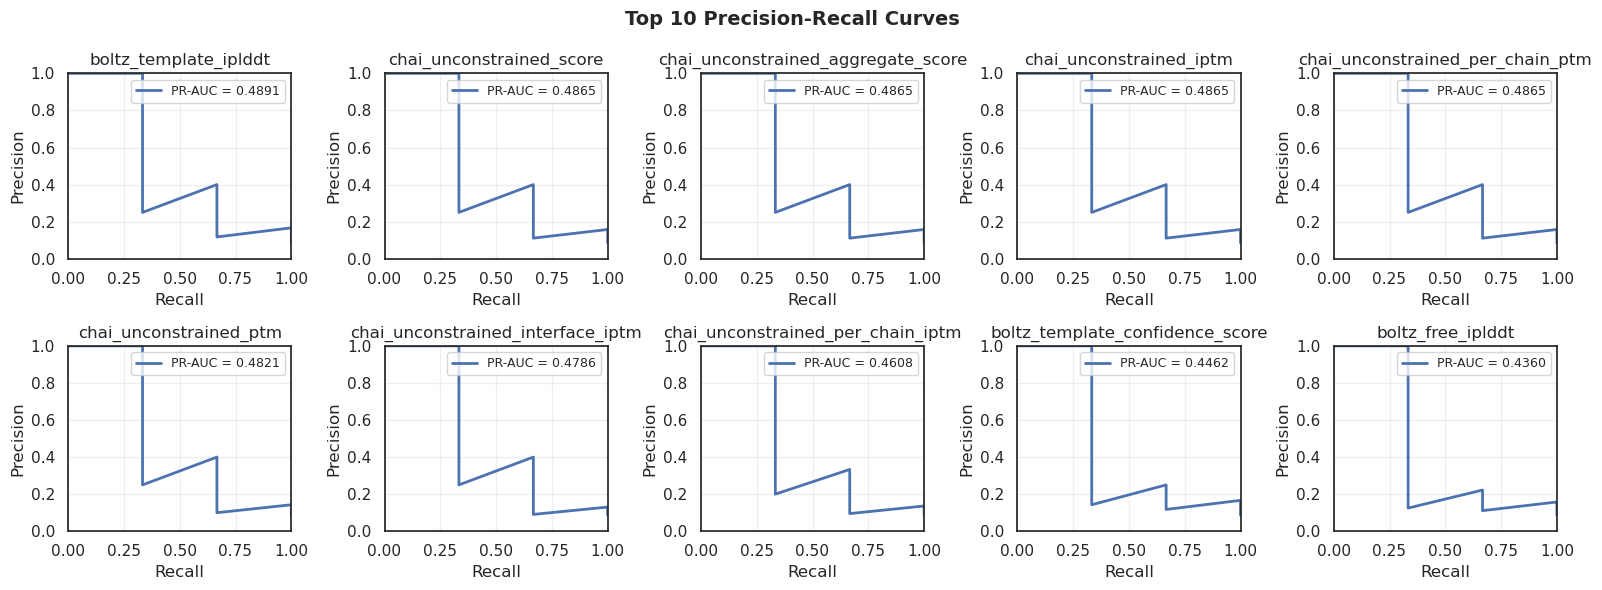

In [45]:
## Plot Precision-Recall Curves

fig, axes = plt.subplots(2, 5, figsize=(16, 6))
axes = axes.flatten()  # Flatten to 1D array for easier indexing

top_10 = pr_auc_df.head(10)

for col_idx, metric in enumerate(top_10.index): 
    ax = axes[col_idx]
    
    pr_auc_value = pr_auc_df.loc[metric, 'PR-AUC']
    precision, recall, _ = precision_recall_curve(scores_df_extended["binder"], scores_df_extended[metric])
    
    ax.plot(recall, precision, linewidth=2, label=f'PR-AUC = {pr_auc_value:.4f}')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{metric}')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1])

plt.suptitle('Top 10 Precision-Recall Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()


#### F1 score
   - Harmonic mean of precision and recall
   - Single number summarizing trade-off between both metrics
   - Best for decision-making at specific threshold

In [46]:
## F1 Score Analysis

from sklearn.metrics import f1_score
import numpy as np

print("\n" + "="*60)
print("F1 Score Analysis")
print("="*60)

# Calculate F1 scores for A,C interface
f1_scores = {}
for col in numeric_cols:
    if scores_df_extended[col].notna().sum() < 2 or scores_df_extended[col].nunique() < 2:
        continue
    try:
        # Find optimal threshold using Youden's J statistic
        from sklearn.metrics import roc_curve
        fpr, tpr, thresholds = roc_curve(scores_df_extended["binder"], scores_df_extended[col])
        j_scores = tpr - fpr
        best_threshold = thresholds[np.argmax(j_scores)]
        
        y_pred = (scores_df_extended[col] >= best_threshold).astype(int)
        f1 = f1_score(scores_df_extended["binder"], y_pred)
        f1_scores[col] = f1
    except:
        pass

sorted_f1 = dict(sorted(f1_scores.items(), key=lambda x: x[1], reverse=True))

print(f"\nTop 10 metrics (F1 Score):")
for i, (metric, f1) in enumerate(list(sorted_f1.items())[:10], 1):
    print(f"  {i:2d}. {metric:40s} F1 = {f1:.4f}")


F1 Score Analysis

Top 10 metrics (F1 Score):
   1. af3_ipsae                                F1 = 0.5714
   2. boltz_template_iptm                      F1 = 0.5714
   3. af3_ipae                                 F1 = 0.5000
   4. af3_iptm                                 F1 = 0.5000
   5. chai_unconstrained_score                 F1 = 0.5000
   6. chai_unconstrained_aggregate_score       F1 = 0.5000
   7. chai_unconstrained_ptm                   F1 = 0.5000
   8. chai_unconstrained_iptm                  F1 = 0.5000
   9. chai_unconstrained_interface_iptm        F1 = 0.5000
  10. boltz_template_ptm                       F1 = 0.5000



Top 10 Metrics - A,C Interface (ROC-AUC, PR-AUC, F1-Score)
                                     ROC-AUC    PR-AUC  F1-Score
boltz_template_per_chain_pair_iptm  0.864583  0.251010  0.428571
boltz_template_iplddt               0.812500  0.489052  0.500000
chai_unconstrained_score            0.802083  0.486501  0.500000
chai_unconstrained_aggregate_score  0.802083  0.486501  0.500000
chai_unconstrained_iptm             0.802083  0.486501  0.500000
boltz_free_iptm                     0.802083  0.222467  0.300000
boltz_free_per_chain_pair_iptm      0.802083  0.187698  0.333333
boltz_template_iptm                 0.802083  0.241830  0.571429
chai_unconstrained_per_chain_ptm    0.802083  0.486501  0.500000
boltz_free_ptm                      0.791667  0.174206  0.333333


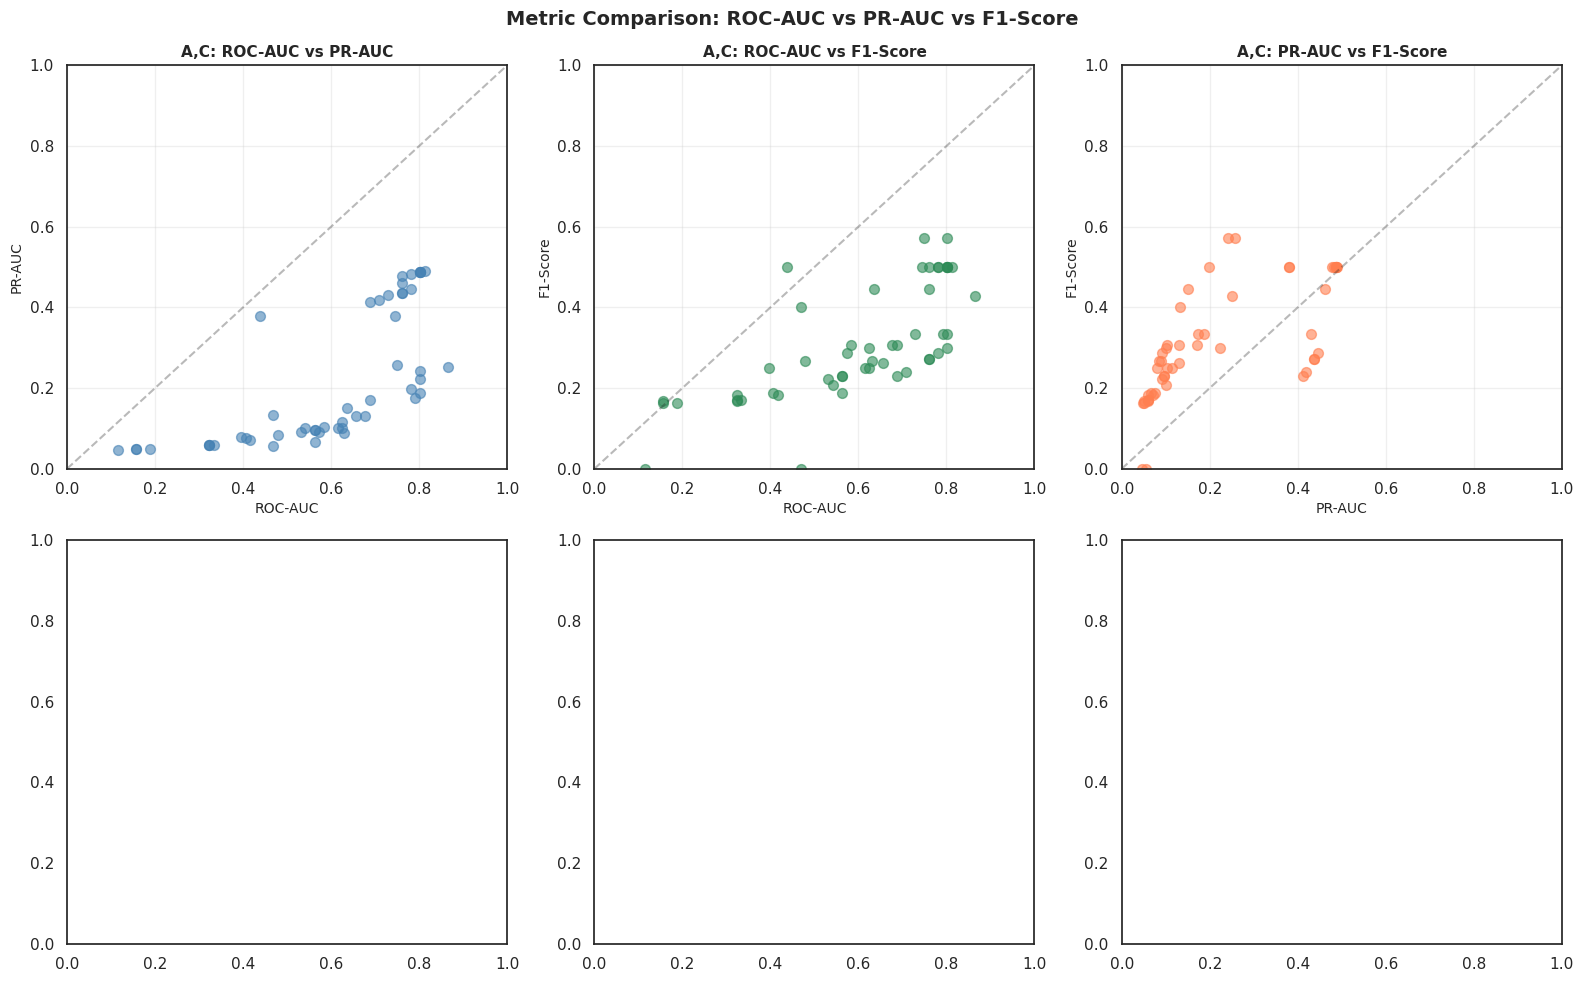

In [47]:
## Compare All Metrics: ROC-AUC, PR-AUC, and F1

# Create comprehensive comparison dataframes
comparision = pd.DataFrame({
    'ROC-AUC': sorted_auc,
    'PR-AUC': sorted_pr_auc,
    'F1-Score': sorted_f1
}).fillna(0).sort_values('ROC-AUC', ascending=False)


print("\n" + "="*80)
print("Top 10 Metrics - A,C Interface (ROC-AUC, PR-AUC, F1-Score)")
print("="*80)
print(comparision.head(10).to_string())



# Create comprehensive comparison plots
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# A,C: ROC-AUC vs PR-AUC
ax = axes[0, 0]
ax.scatter(comparision['ROC-AUC'], comparision['PR-AUC'], alpha=0.6, s=50, color='steelblue')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('PR-AUC', fontsize=10)
ax.set_title('A,C: ROC-AUC vs PR-AUC', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# A,C: ROC-AUC vs F1
ax = axes[0, 1]
ax.scatter(comparision['ROC-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='seagreen')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('ROC-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('A,C: ROC-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# A,C: PR-AUC vs F1
ax = axes[0, 2]
ax.scatter(comparision['PR-AUC'], comparision['F1-Score'], alpha=0.6, s=50, color='coral')
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('PR-AUC', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=10)
ax.set_title('A,C: PR-AUC vs F1-Score', fontsize=11, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

plt.suptitle('Metric Comparison: ROC-AUC vs PR-AUC vs F1-Score', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('metrics_comparison_combined.png', dpi=150, bbox_inches='tight')
plt.show()


Ranking Comparison - A,C Interface (Top 15 by each metric)

Top 15 by ROC-AUC:
['boltz_template_per_chain_pair_iptm', 'boltz_template_iplddt', 'chai_unconstrained_score', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_iptm', 'boltz_free_iptm', 'boltz_free_per_chain_pair_iptm', 'boltz_template_iptm', 'chai_unconstrained_per_chain_ptm', 'boltz_free_ptm', 'chai_unconstrained_ptm', 'boltz_template_confidence_score', 'boltz_template_ptm', 'chai_unconstrained_per_chain_iptm', 'chai_unconstrained_interface_iptm']

Top 15 by PR-AUC:
['boltz_template_iplddt', 'chai_unconstrained_score', 'chai_unconstrained_aggregate_score', 'chai_unconstrained_iptm', 'chai_unconstrained_per_chain_ptm', 'chai_unconstrained_ptm', 'chai_unconstrained_interface_iptm', 'chai_unconstrained_per_chain_iptm', 'boltz_template_confidence_score', 'boltz_free_iplddt', 'boltz_template_plddt', 'boltz_free_confidence_score', 'boltz_free_plddt', 'pred_lddt', 'af3_iptm']

Top 15 by F1-Score:
['af3_ipsae', 'boltz_temp

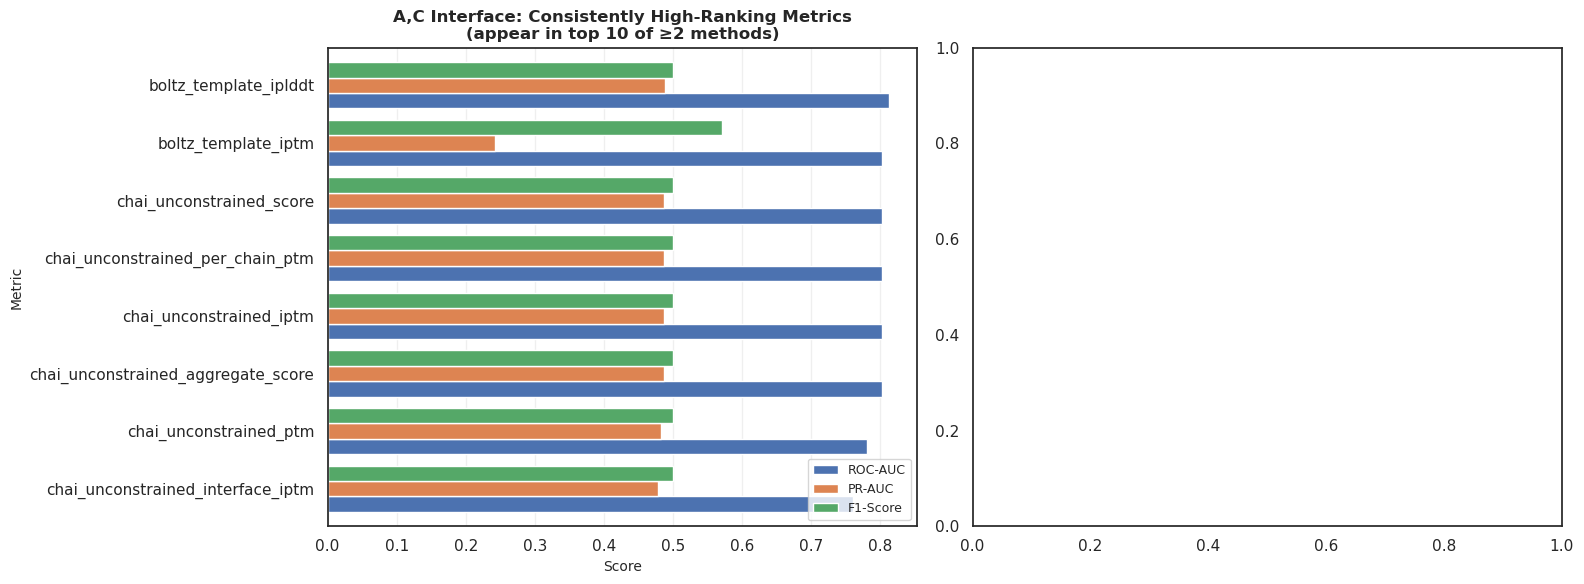

In [48]:
## Ranking Comparison across Metrics

# Get top 15 metrics by each criterion for A,C
top_15_roc = list(sorted_auc.keys())[:15]
top_15_pr = list(sorted_pr_auc.keys())[:15]
top_15_f1 = list(sorted_f1.keys())[:15]

# Create ranking comparison table for A,C
print("\n" + "="*80)
print("Ranking Comparison - A,C Interface (Top 15 by each metric)")
print("="*80)
print(f"\nTop 15 by ROC-AUC:\n{top_15_roc}")
print(f"\nTop 15 by PR-AUC:\n{top_15_pr}")
print(f"\nTop 15 by F1-Score:\n{top_15_f1}")




# Heatmap style visualization of top metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# A,C: Identify metrics that rank consistently high
# Count how many times each metric appears in top 10 across all three methods
metric_consistency = {}
for metric in set(top_15_roc[:10] + top_15_pr[:10] + top_15_f1[:10]):
    count = 0
    if metric in top_15_roc[:10]:
        count += 1
    if metric in top_15_pr[:10]:
        count += 1
    if metric in top_15_f1[:10]:
        count += 1
    metric_consistency[metric] = count

# Get metrics that appear in top 10 of at least 2 methods
consistent_metrics = sorted([m for m, c in metric_consistency.items() if c >= 2], 
                                key=lambda x: metric_consistency[x], reverse=True)[:10]

data = comparision.loc[consistent_metrics, :].sort_values('ROC-AUC', ascending=True)
data['Consistency'] = data.index.map(lambda x: f"{metric_consistency.get(x, 0)}/3 methods")

data.plot(kind='barh', ax=ax1, width=0.8)
ax1.set_title('A,C Interface: Consistently High-Ranking Metrics\n(appear in top 10 of ≥2 methods)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Score', fontsize=10)
ax1.set_ylabel('Metric', fontsize=10)
ax1.legend(loc='lower right', fontsize=9)
ax1.grid(True, alpha=0.3, axis='x')


# Print consistency summary
print("\nConsistency Analysis (Metrics appearing in top 10 of multiple evaluation methods):")
print("\nA,C Interface - Metric Consistency:")
for metric in consistent_metrics:
    consistency = metric_consistency[metric]
    print(f"  {metric:40s} appears in {consistency}/3 methods")
    

plt.tight_layout()
plt.savefig('metrics_ranking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


TOP METRICS
(Sorted by PR-AUC, then F1-Score)

--------------------------------------------------------------------------------
A,C Interface - Top 15 Metrics
--------------------------------------------------------------------------------
                                     ROC-AUC    PR-AUC  F1-Score
boltz_template_iplddt               0.812500  0.489052  0.500000
chai_unconstrained_score            0.802083  0.486501  0.500000
chai_unconstrained_aggregate_score  0.802083  0.486501  0.500000
chai_unconstrained_iptm             0.802083  0.486501  0.500000
chai_unconstrained_per_chain_ptm    0.802083  0.486501  0.500000
chai_unconstrained_ptm              0.781250  0.482143  0.500000
chai_unconstrained_interface_iptm   0.760417  0.478557  0.500000
chai_unconstrained_per_chain_iptm   0.760417  0.460823  0.444444
boltz_template_confidence_score     0.781250  0.446195  0.285714
boltz_free_iplddt                   0.760417  0.436038  0.272727
boltz_template_plddt                0.760417

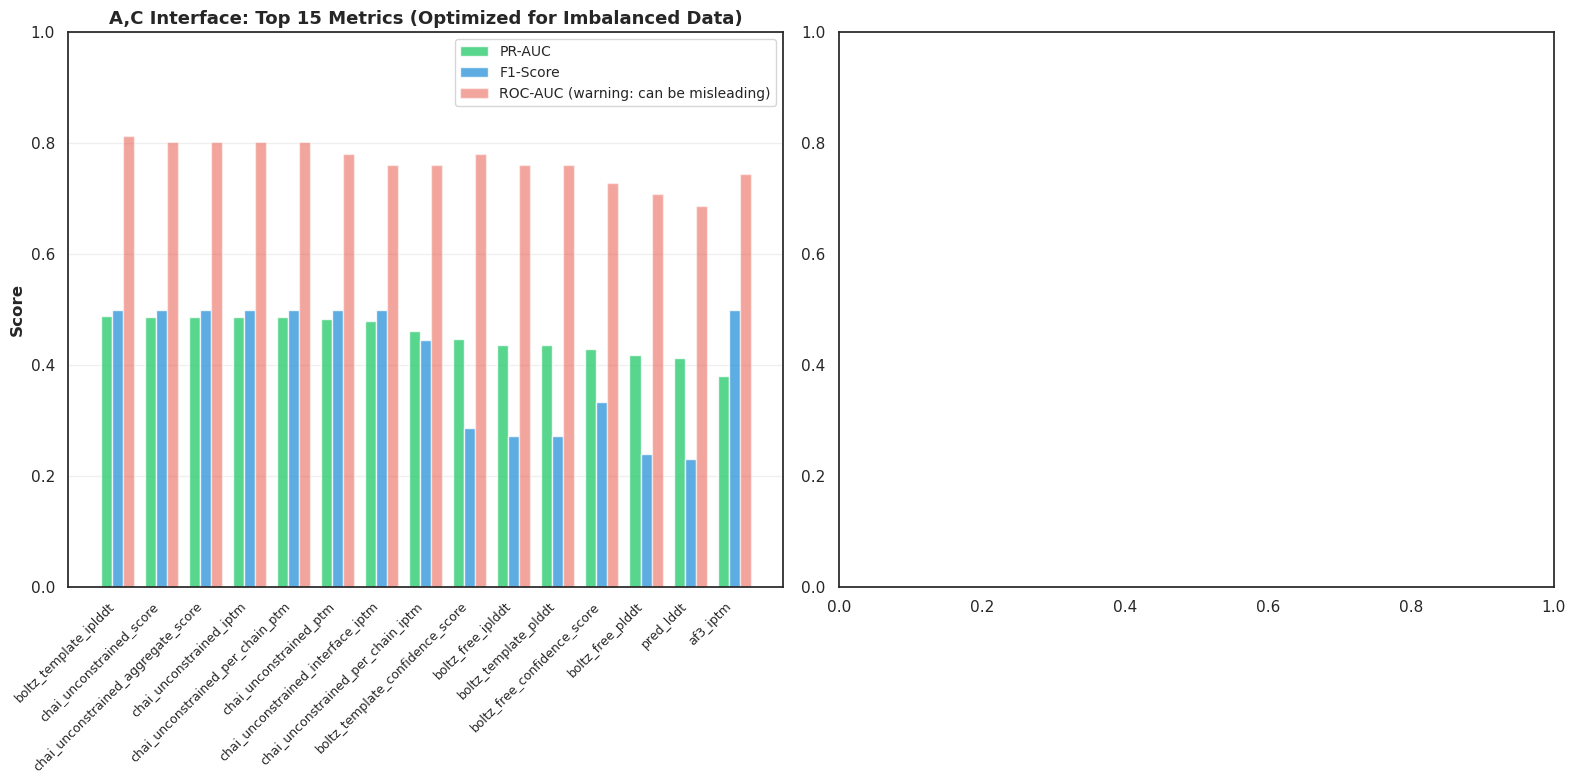


✓ Saved: metrics_optimized_for_imbalanced_data.png

KEY RECOMMENDATIONS:
  • Focus on metrics with HIGH PR-AUC (green bars)
  • Use F1-Score for deciding optimal thresholds (blue bars)
  • ROC-AUC scores (red bars) should be deprioritized for this imbalanced data


In [49]:
## Optimized Ranking for Imbalanced Data (PR-AUC & F1 Priority)

print("\n" + "="*80)
print("TOP METRICS")
print("(Sorted by PR-AUC, then F1-Score)")
print("="*80)

# Create optimized rankings for A,C (sorted by PR-AUC first, then F1)
optimized = comparision.copy().sort_values(['PR-AUC', 'F1-Score'], ascending=False)

print("\n" + "-"*80)
print("A,C Interface - Top 15 Metrics")
print("-"*80)
print(optimized.head(15).to_string())

# Create visualization emphasizing PR-AUC and F1-Score
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8))

# A,C: Top 15 metrics by PR-AUC (not ROC-AUC)
top_15_pr_auc = optimized.head(15)
x_pos_ac = range(len(top_15_pr_auc))

width = 0.25
ax1.bar([i - width for i in x_pos_ac], top_15_pr_auc['PR-AUC'], width, label='PR-AUC', color='#2ecc71', alpha=0.8)
ax1.bar(x_pos_ac, top_15_pr_auc['F1-Score'], width, label='F1-Score', color='#3498db', alpha=0.8)
ax1.bar([i + width for i in x_pos_ac], top_15_pr_auc['ROC-AUC'], width, label='ROC-AUC (warning: can be misleading)', color='#e74c3c', alpha=0.5)

ax1.set_ylabel('Score', fontsize=12, fontweight='bold')
ax1.set_title('A,C Interface: Top 15 Metrics (Optimized for Imbalanced Data)', fontsize=13, fontweight='bold')
ax1.set_xticks(x_pos_ac)
ax1.set_xticklabels(top_15_pr_auc.index, rotation=45, ha='right', fontsize=9)
ax1.legend(loc='upper right', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y')
ax1.set_ylim([0, 1])


plt.tight_layout()
plt.savefig('metrics_optimized_for_imbalanced_data.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: metrics_optimized_for_imbalanced_data.png")
print("\nKEY RECOMMENDATIONS:")
print("  • Focus on metrics with HIGH PR-AUC (green bars)")
print("  • Use F1-Score for deciding optimal thresholds (blue bars)")
print("  • ROC-AUC scores (red bars) should be deprioritized for this imbalanced data")